In [29]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [4]:
train_df = pd.read_csv('data/청구정보_with_segment.csv')

In [5]:
subset = train_df[train_df['기준년월'] == 201811]

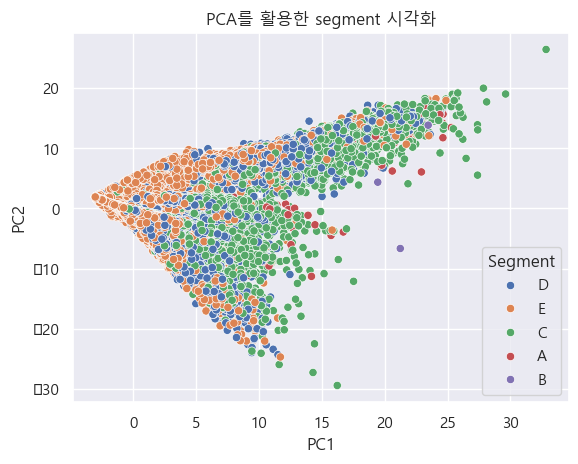

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 수치형 변수 표준화
numeric_data = subset.select_dtypes(include='number')
scaled = StandardScaler().fit_transform(numeric_data)

# PCA
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df['Segment'] = subset['Segment'].values

# 시각화
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Segment')
plt.title('PCA를 활용한 segment 시각화')
plt.show()


In [24]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 수치형 변수 선택 및 정규화
numeric_data = subset.select_dtypes(include='number')
imputed_data = numeric_data.fillna(numeric_data.mean())  # 결측값 처리
scaled_data = StandardScaler().fit_transform(imputed_data)

# 2. PCA 수행
pca = PCA(n_components=2)
pca.fit(scaled_data)

# 3. 구성 성분 확인
loadings = pd.DataFrame(
    pca.components_.T,  # 전치행렬: 변수 x 주성분
    columns=['PC1', 'PC2'],
    index=numeric_data.columns
)

# 4. 절대값 기준으로 가장 영향력 있는 변수 확인
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False)

print("📌 PC1에 가장 영향을 준 변수:")
print(top_pc1.head(10))
print("\n📌 PC2에 가장 영향을 준 변수:")
print(top_pc2.head(10))


📌 PC1에 가장 영향을 준 변수:
혜택수혜금액_R3M         0.277850
혜택수혜금액             0.274863
포인트_마일리지_환산_B0M    0.248882
마일_적립포인트_R3M       0.246983
포인트_마일리지_건별_R3M    0.235585
청구금액_R3M           0.235452
포인트_마일리지_건별_B0M    0.235210
청구금액_R6M           0.234251
마일_이용포인트_R3M       0.232994
마일_이용포인트_R12M      0.232485
Name: PC1, dtype: float64

📌 PC2에 가장 영향을 준 변수:
마일_이용포인트_R12M      0.255887
포인트_마일리지_건별_R3M    0.255403
포인트_마일리지_건별_B0M    0.255185
마일_이용포인트_R3M       0.254210
마일_적립포인트_R12M      0.248792
포인트_적립포인트_R3M      0.246852
마일_적립포인트_R3M       0.243069
포인트_마일리지_환산_B0M    0.242921
포인트_이용포인트_R3M      0.236987
포인트_포인트_건별_R3M     0.222452
Name: PC2, dtype: float64


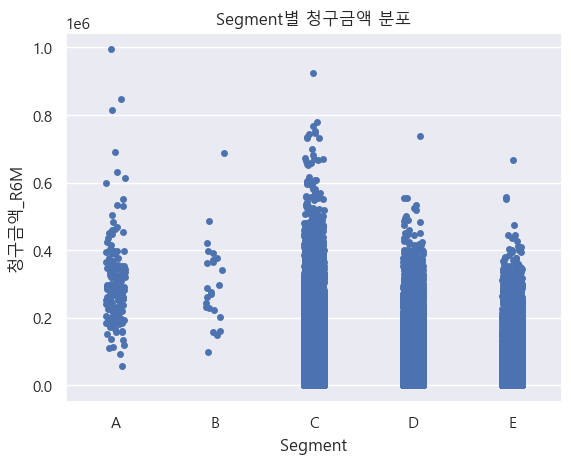

In [5]:
# Segment 순서를 수동 지정
ordered_segments = ['A', 'B', 'C', 'D', 'E']

sns.stripplot(x='Segment', y='청구금액_R6M', data=subset, jitter=True, order=ordered_segments)
plt.title('Segment별 청구금액 분포')
plt.show()


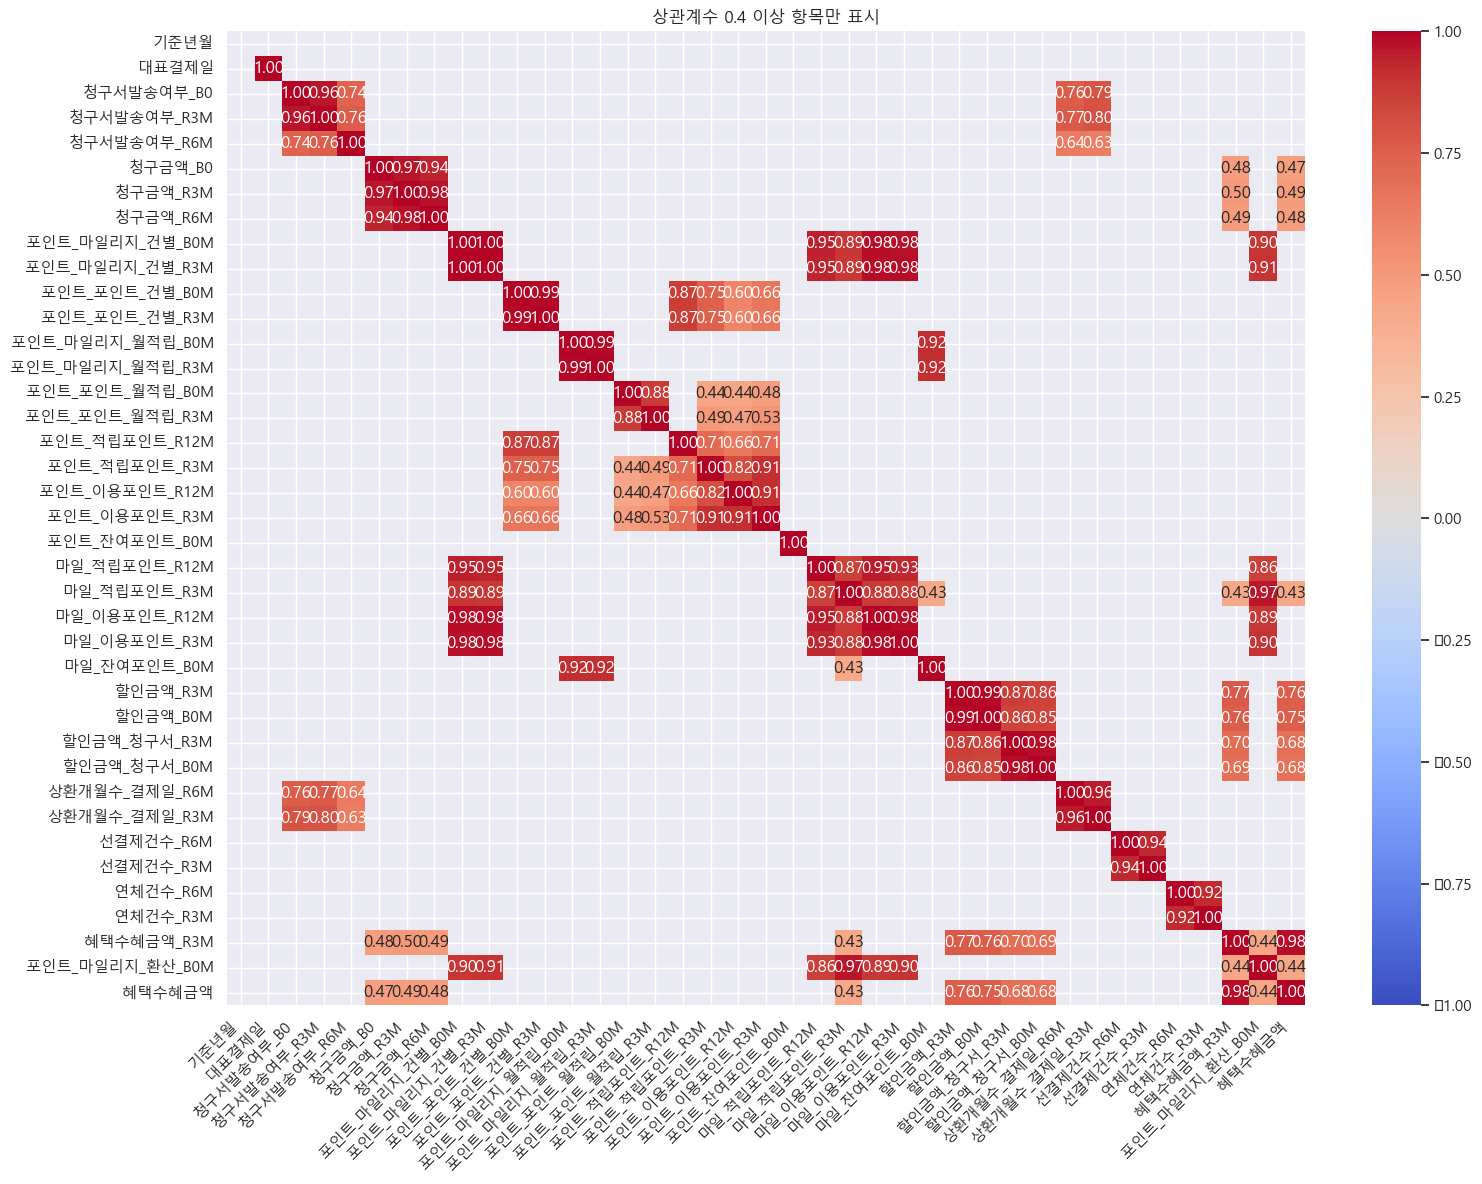

In [6]:
# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 절대값 기준 필터링 (예: 0.5 이상만)
filtered_corr = corr.copy()
filtered_corr[np.abs(filtered_corr) < 0.4] = np.nan

plt.figure(figsize=(16, 12))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, mask=filtered_corr.isnull())
plt.title('상관계수 0.4 이상 항목만 표시')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np

# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 상삼각 (자기 자신 제외)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
filtered = corr.where(mask)

# 절대값 기준 필터링
result = (
    filtered.stack()
    .reset_index()
    .rename(columns={'level_0': '변수1', 'level_1': '변수2', 0: '상관계수'})
)

# 상관계수 0.4 이상만 추출
result = result[result['상관계수'].abs() >= 0.8]
result = result.sort_values(by='상관계수', ascending=False)

# 결과 출력
print(result)


                  변수1               변수2      상관계수
238   포인트_마일리지_건별_B0M   포인트_마일리지_건별_R3M  0.995044
352  포인트_마일리지_월적립_B0M  포인트_마일리지_월적립_R3M  0.991687
297    포인트_포인트_건별_B0M    포인트_포인트_건별_R3M  0.990727
625          할인금액_R3M          할인금액_B0M  0.986419
282   포인트_마일리지_건별_R3M      마일_이용포인트_R3M  0.981411
701        혜택수혜금액_R3M            혜택수혜금액  0.981403
648      할인금액_청구서_R3M      할인금액_청구서_B0M  0.980963
281   포인트_마일리지_건별_R3M     마일_이용포인트_R12M  0.978946
583     마일_이용포인트_R12M      마일_이용포인트_R3M  0.978844
252   포인트_마일리지_건별_B0M     마일_이용포인트_R12M  0.977897
253   포인트_마일리지_건별_B0M      마일_이용포인트_R3M  0.975901
175          청구금액_R3M          청구금액_R6M  0.975492
142           청구금액_B0          청구금액_R3M  0.967955
581      마일_적립포인트_R3M   포인트_마일리지_환산_B0M  0.965754
37         청구서발송여부_B0       청구서발송여부_R3M  0.962601
667     상환개월수_결제일_R6M     상환개월수_결제일_R3M  0.955481
551     마일_적립포인트_R12M     마일_이용포인트_R12M  0.954018
250   포인트_마일리지_건별_B0M     마일_적립포인트_R12M  0.949237
279   포인트_마일리지_건별_R3M     마일_적립포인트_R12M  0.945089


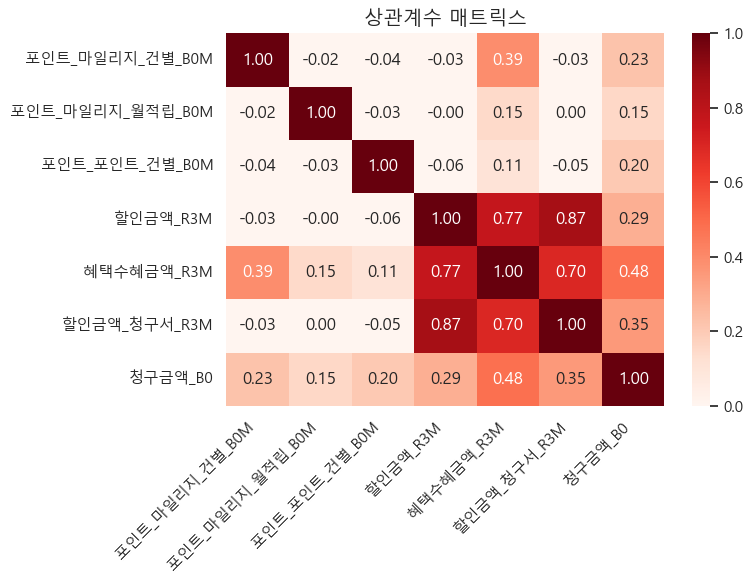

In [8]:
# 원하는 변수 리스트
cols = [
    '포인트_마일리지_건별_B0M',
    '포인트_마일리지_월적립_B0M',
    '포인트_포인트_건별_B0M',
    '할인금액_R3M',
    '혜택수혜금액_R3M',
    '할인금액_청구서_R3M',
    '청구금액_B0'
]

# 숫자형 컬럼만 필터링되어 있어야 함
corr = subset[cols].corr()

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title('상관계수 매트릭스', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


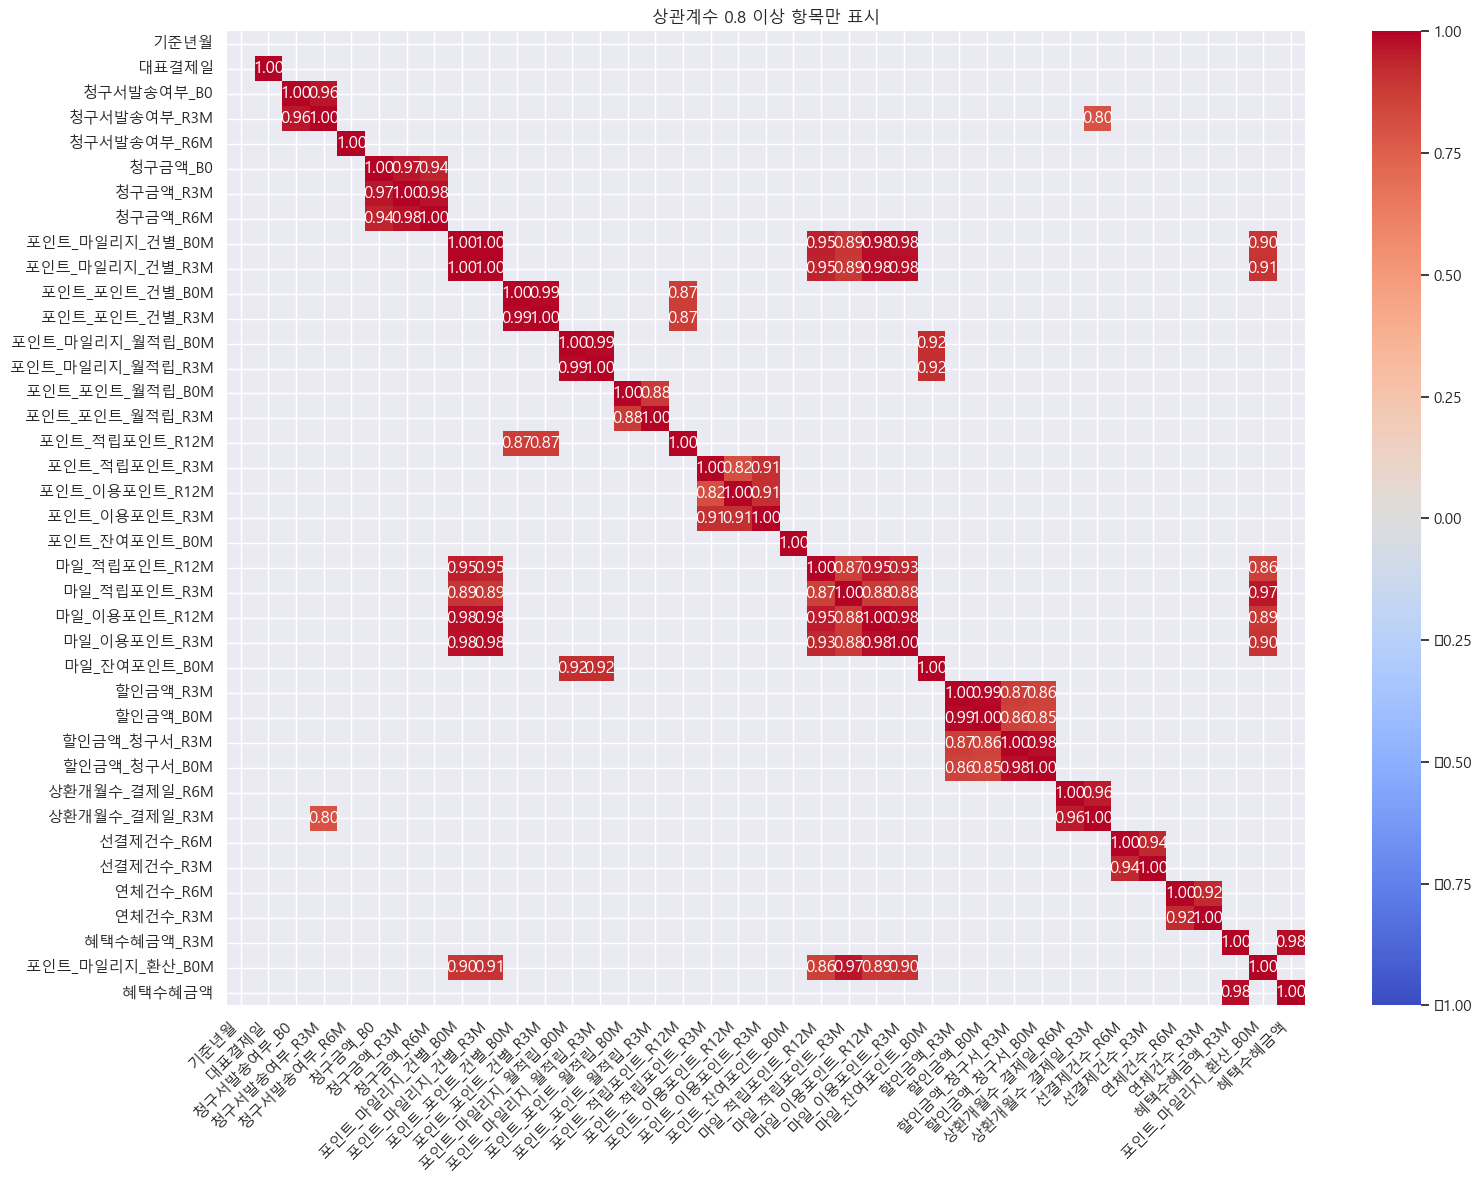

In [9]:
# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 절대값 기준 필터링 (예: 0.5 이상만)
filtered_corr = corr.copy()
filtered_corr[np.abs(filtered_corr) < 0.8] = np.nan

plt.figure(figsize=(16, 12))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, mask=filtered_corr.isnull())
plt.title('상관계수 0.8 이상 항목만 표시')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [10]:
import numpy as np

# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 상삼각 행렬 (자기 자신 제외)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
upper = corr.where(mask)

# 0.8 이상인 항목 필터링
high_corr = upper[abs(upper) >= 0.95]

# 컬럼 이름 추출 (중복 없이)
cols = set(high_corr.dropna(how='all').index) | set(high_corr.dropna(axis=1, how='all').columns)
selected_columns = sorted(cols)

# 출력
print("상관계수 0.95 이상인 컬럼 목록:")
for col in selected_columns:
    print(col)


상관계수 0.95 이상인 컬럼 목록:
마일_이용포인트_R12M
마일_이용포인트_R3M
마일_적립포인트_R12M
마일_적립포인트_R3M
상환개월수_결제일_R3M
상환개월수_결제일_R6M
청구금액_B0
청구금액_R3M
청구금액_R6M
청구서발송여부_B0
청구서발송여부_R3M
포인트_마일리지_건별_B0M
포인트_마일리지_건별_R3M
포인트_마일리지_월적립_B0M
포인트_마일리지_월적립_R3M
포인트_마일리지_환산_B0M
포인트_포인트_건별_B0M
포인트_포인트_건별_R3M
할인금액_B0M
할인금액_R3M
할인금액_청구서_B0M
할인금액_청구서_R3M
혜택수혜금액
혜택수혜금액_R3M


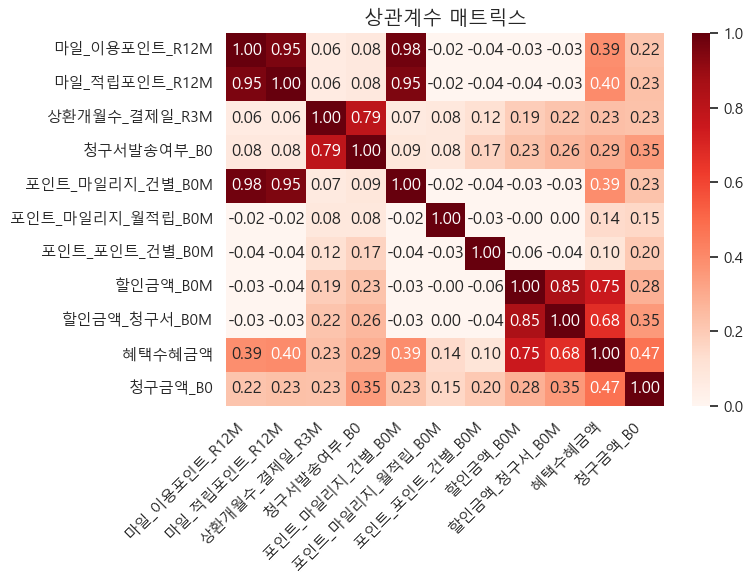

In [11]:
# 원하는 변수 리스트
cols = [
    '마일_이용포인트_R12M',
    '마일_적립포인트_R12M',
    '상환개월수_결제일_R3M',
    '청구서발송여부_B0',
    '포인트_마일리지_건별_B0M',
    '포인트_마일리지_월적립_B0M',
    '포인트_포인트_건별_B0M',
    '할인금액_B0M',
    '할인금액_청구서_B0M',
    '혜택수혜금액',
    '청구금액_B0'
]

# 숫자형 컬럼만 필터링되어 있어야 함
corr = subset[cols].corr()

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title('상관계수 매트릭스', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


<Axes: xlabel='할인건수_R3M', ylabel='count'>

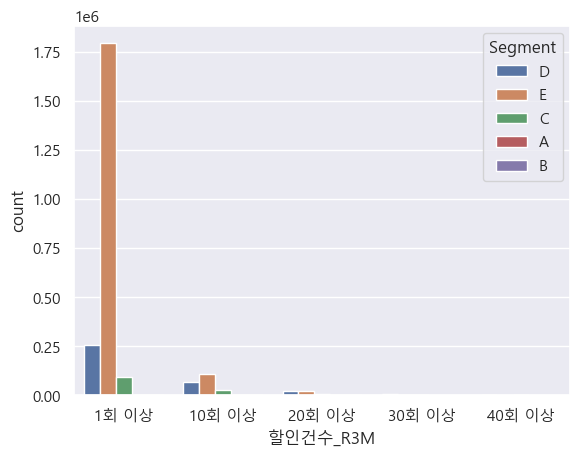

In [10]:
sns.countplot(data=train_df, x='할인건수_R3M', hue='Segment')

In [22]:
# 할인건수_R3M과 Segment의 교차표 출력
count_table = pd.crosstab(train_df['할인건수_R3M'], train_df['Segment'])

# 보기 좋게 정렬 (선택사항)
count_table = count_table.sort_index()

print(count_table)


Segment     A    B      C       D        E
할인건수_R3M                                  
10회 이상     99   25  24225   66435   105867
1회 이상     861  114  92466  256397  1792433
20회 이상     12    5   8856   22196    21940
30회 이상      0    0   2042    4211     1812
40회 이상      0    0      1       3        0


In [32]:
# 행 기준 비율
rate_table = pd.crosstab(train_df['할인건수_R3M'], train_df['Segment'], normalize='index') * 100
print(rate_table.round(1))  # 소수점 1자리로 보기 좋게


Segment     A    B     C     D     E
할인건수_R3M                            
10회 이상    0.1  0.0  12.3  33.8  53.8
1회 이상     0.0  0.0   4.3  12.0  83.7
20회 이상    0.0  0.0  16.7  41.9  41.4
30회 이상    0.0  0.0  25.3  52.2  22.5
40회 이상    0.0  0.0  25.0  75.0   0.0


<Axes: xlabel='할인건수_B0M', ylabel='count'>

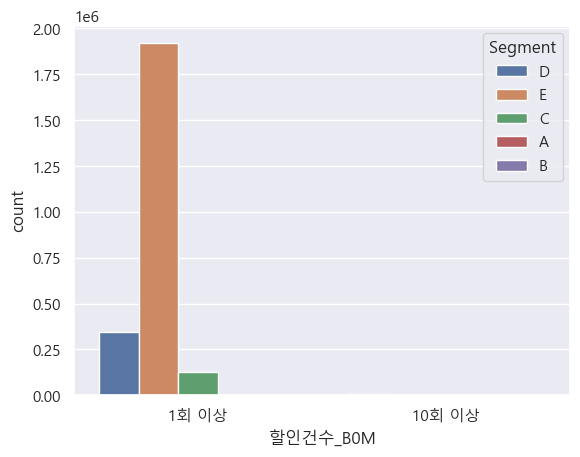

In [12]:
sns.countplot(data=train_df, x='할인건수_B0M', hue='Segment')

In [24]:
# 할인건수_R3M과 Segment의 교차표 출력
count_table = pd.crosstab(train_df['할인건수_B0M'], train_df['Segment'])

# 보기 좋게 정렬 (선택사항)
count_table = count_table.sort_index()

print(count_table)


Segment     A    B       C       D        E
할인건수_B0M                                   
10회 이상      2    0    2732    5603     2835
1회 이상     970  144  124858  343639  1919217


<Axes: xlabel='연체건수_R6M', ylabel='count'>

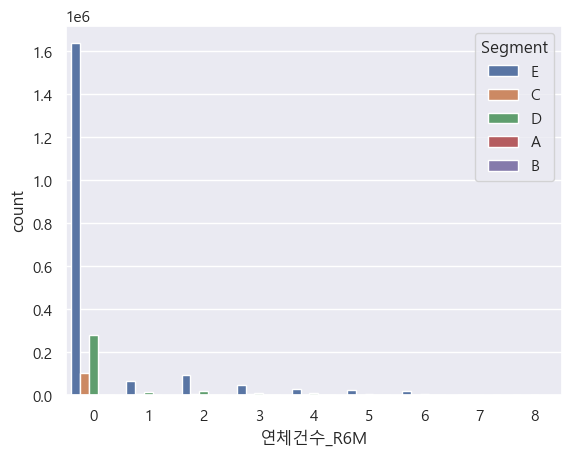

In [18]:
sns.countplot(data=train_df, x='연체건수_R6M', hue='Segment')

In [26]:
# 할인건수_R3M과 Segment의 교차표 출력
count_table = pd.crosstab(train_df['연체건수_R6M'], train_df['Segment'])

# 보기 좋게 정렬 (선택사항)
count_table = count_table.sort_index()

print(count_table)


Segment     A    B       C       D        E
연체건수_R6M                                   
0         814  108  102050  279478  1637563
1          47    0    4753   13561    65619
2          47   17    7701   20732    94725
3          22    8    4688   12216    48692
4          15    4    3204    8439    30908
5          17    1    2520    7004    23706
6          10    4    2292    6527    18094
7           0    2     382    1284     2740
8           0    0       0       1        5


In [15]:
# 행 기준 비율
rate_table = pd.crosstab(train_df['연체건수_R6M'], train_df['Segment'], normalize='index') * 100
print(rate_table.round(1))  # 소수점 1자리로 보기 좋게


Segment     A    B    C     D     E
연체건수_R6M                           
0         0.0  0.0  5.1  13.8  81.1
1         0.1  0.0  5.7  16.1  78.1
2         0.0  0.0  6.2  16.8  76.9
3         0.0  0.0  7.1  18.6  74.2
4         0.0  0.0  7.5  19.8  72.6
5         0.1  0.0  7.6  21.1  71.3
6         0.0  0.0  8.5  24.2  67.2
7         0.0  0.0  8.7  29.1  62.2
8         0.0  0.0  0.0  16.7  83.3


<Axes: xlabel='연체건수_R3M', ylabel='count'>

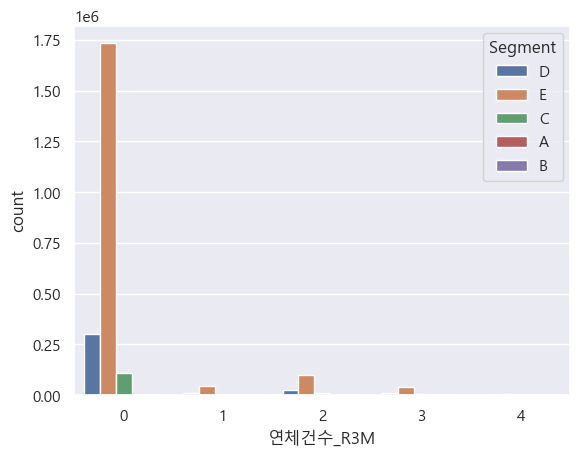

In [33]:
sns.countplot(data=train_df, x='연체건수_R3M', hue='Segment')

In [28]:
# 할인건수_R3M과 Segment의 교차표 출력
count_table = pd.crosstab(train_df['연체건수_R3M'], train_df['Segment'])

# 보기 좋게 정렬 (선택사항)
count_table = count_table.sort_index()

print(count_table)


Segment     A    B       C       D        E
연체건수_R3M                                   
0         864  109  109686  300436  1732785
1          32    6    3311    8969    44407
2          51   22    9283   24766    98893
3          24    5    4795   13428    42015
4           1    2     515    1643     3952


In [17]:
# 행 기준 비율
rate_table = pd.crosstab(train_df['연체건수_R3M'], train_df['Segment'], normalize='index') * 100
print(rate_table.round(1))  # 소수점 1자리로 보기 좋게


Segment     A    B    C     D     E
연체건수_R3M                           
0         0.0  0.0  5.1  14.0  80.8
1         0.1  0.0  5.8  15.8  78.3
2         0.0  0.0  7.0  18.6  74.3
3         0.0  0.0  8.0  22.3  69.7
4         0.0  0.0  8.4  26.9  64.6


<Axes: xlabel='선결제건수_R6M', ylabel='count'>

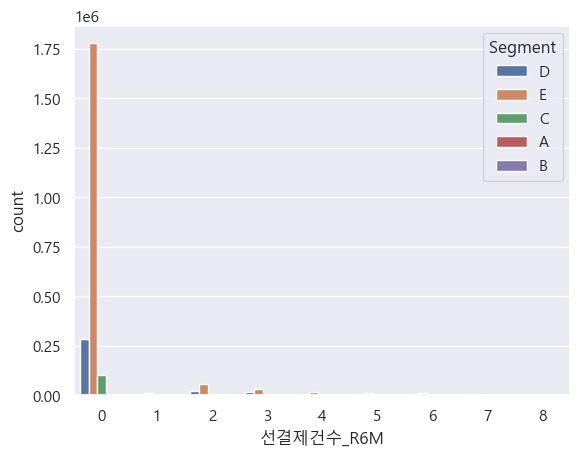

In [15]:
sns.countplot(data=train_df, x='선결제건수_R6M', hue='Segment')

In [17]:
# 할인건수_R3M과 Segment의 교차표 출력
count_table = pd.crosstab(train_df['선결제건수_R6M'], train_df['Segment'])

# 보기 좋게 정렬 (선택사항)
count_table = count_table.sort_index()

print(count_table)


Segment      A   B       C       D        E
선결제건수_R6M                                  
0          763  62  100065  284478  1778402
1           19   2    1044    3278    11768
2           73  19    8550   22086    58192
3           58  13    6790   14154    29791
4           28   3    3446    7061    14211
5           22   7    2380    5955    11666
6            9  19    2945    7551    12469
7            0  17    2098    4311     5221
8            0   2     272     368      332


In [19]:
# 행 기준 비율
rate_table = pd.crosstab(train_df['선결제건수_R6M'], train_df['Segment'], normalize='index') * 100
print(rate_table.round(1))  # 소수점 1자리로 보기 좋게


Segment      A    B     C     D     E
선결제건수_R6M                            
0          0.0  0.0   4.6  13.1  82.2
1          0.1  0.0   6.5  20.3  73.0
2          0.1  0.0   9.6  24.8  65.4
3          0.1  0.0  13.4  27.9  58.6
4          0.1  0.0  13.9  28.5  57.4
5          0.1  0.0  11.9  29.7  58.2
6          0.0  0.1  12.8  32.8  54.2
7          0.0  0.1  18.0  37.0  44.8
8          0.0  0.2  27.9  37.8  34.1


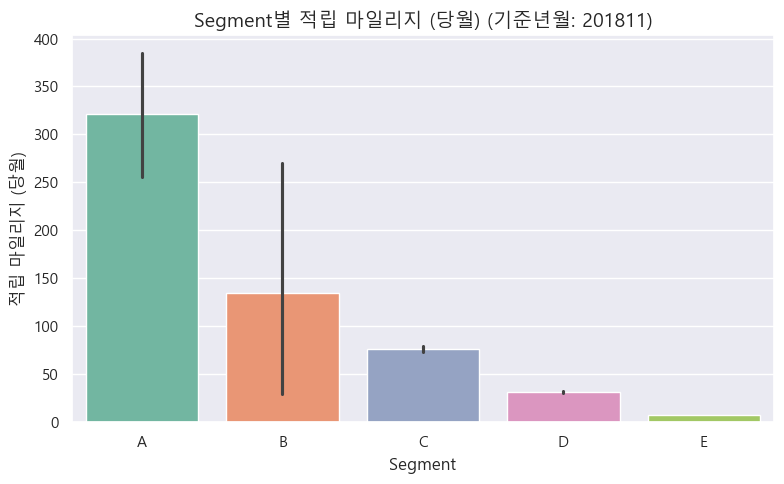

In [11]:
# 정렬 기준: 평균 청구금액 기준 내림차순
segment_order = (
    subset.groupby('Segment')['포인트_마일리지_월적립_B0M']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# 색상 팔레트
palette = sns.color_palette("Set2")

# 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=subset,
    x='Segment',
    y='포인트_마일리지_월적립_B0M',
    estimator='mean',
    order=segment_order,  # ✅ 정렬 반영
    palette=palette,
)

# 제목 및 축 설정
ax.set_title('Segment별 적립 마일리지 (당월) (기준년월: 201811)', fontsize=14)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('적립 마일리지 (당월)', fontsize=12)

plt.tight_layout()
plt.show()


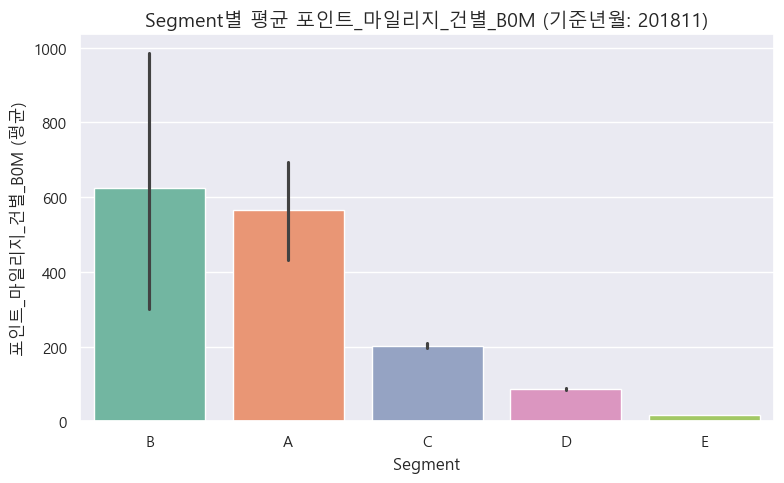

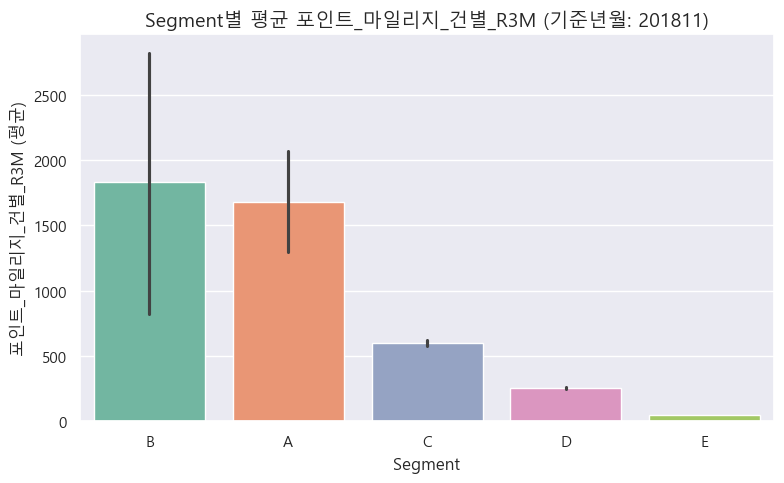

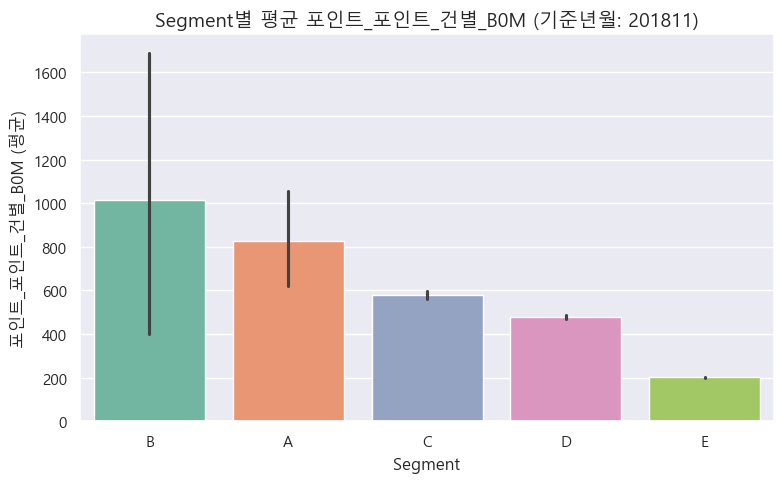

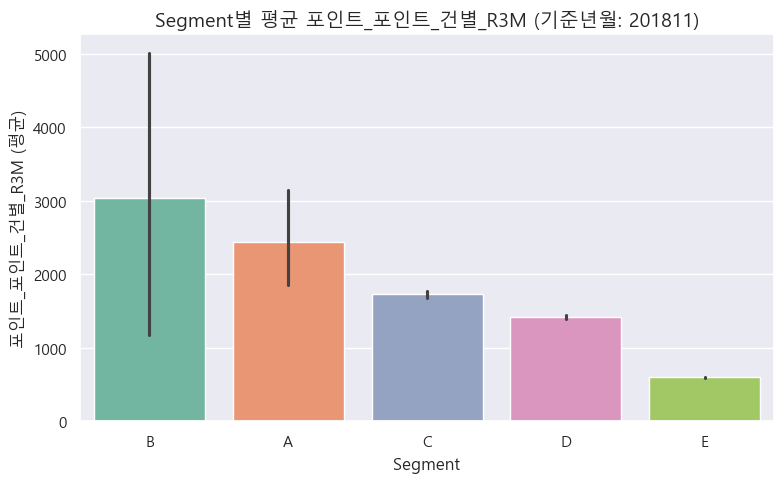

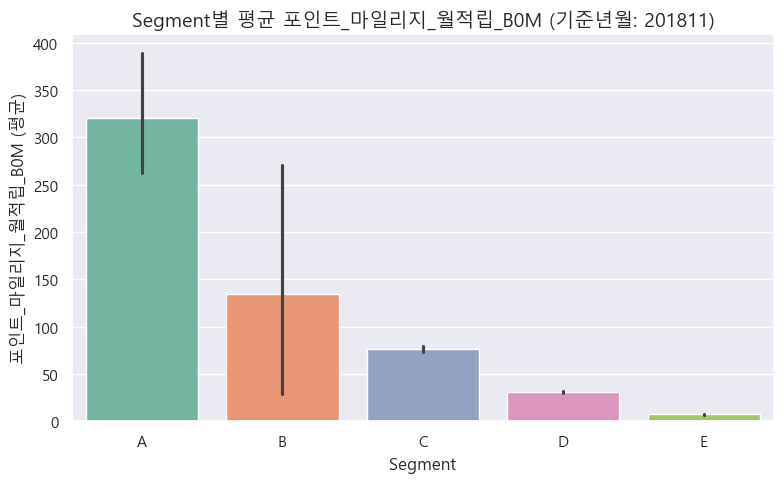

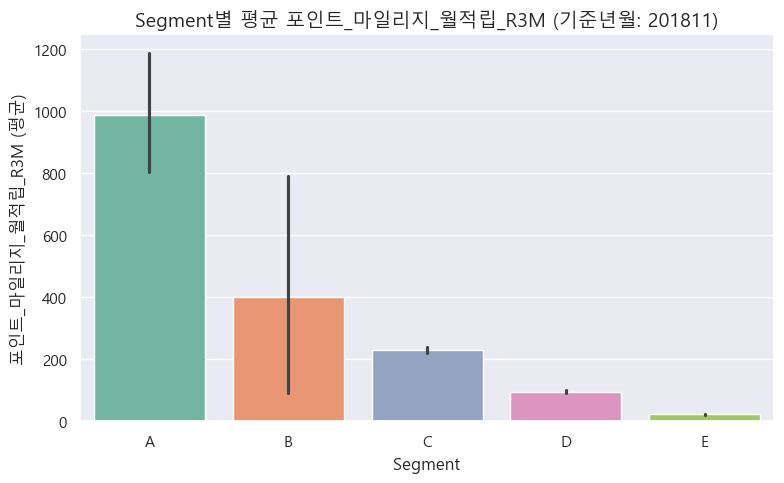

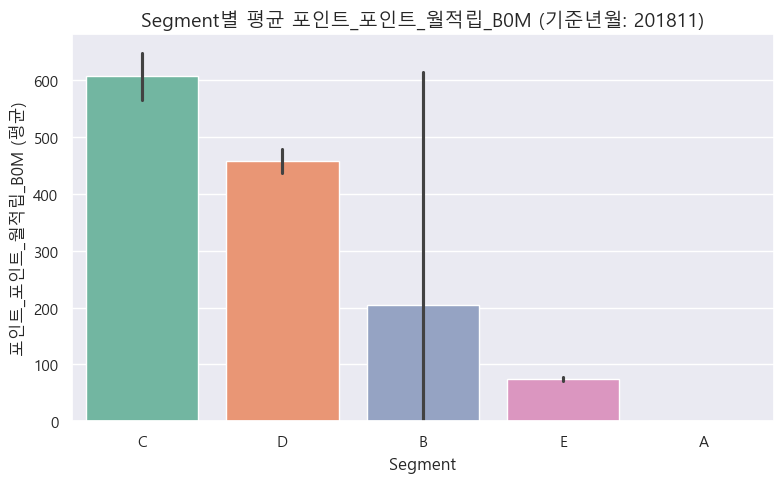

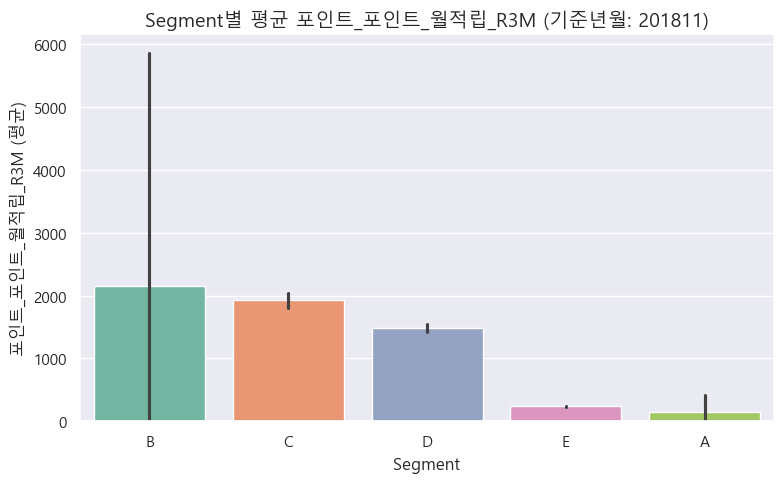

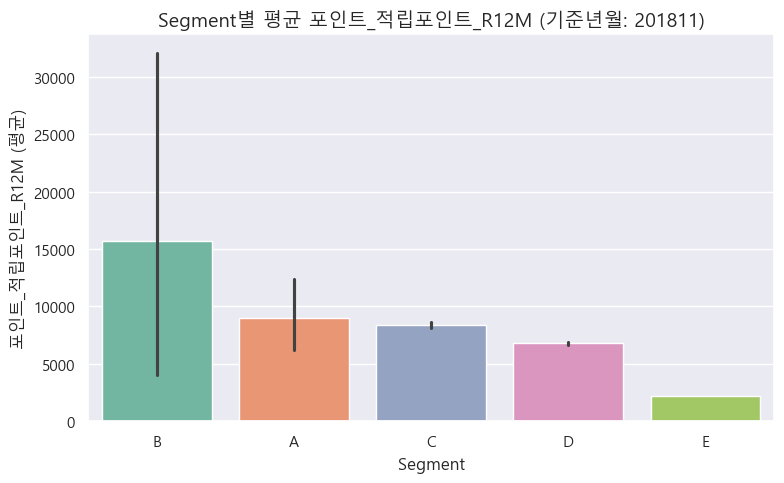

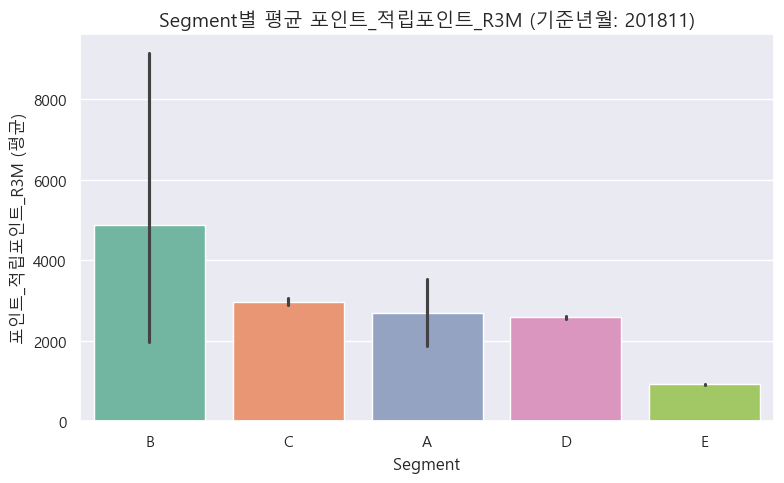

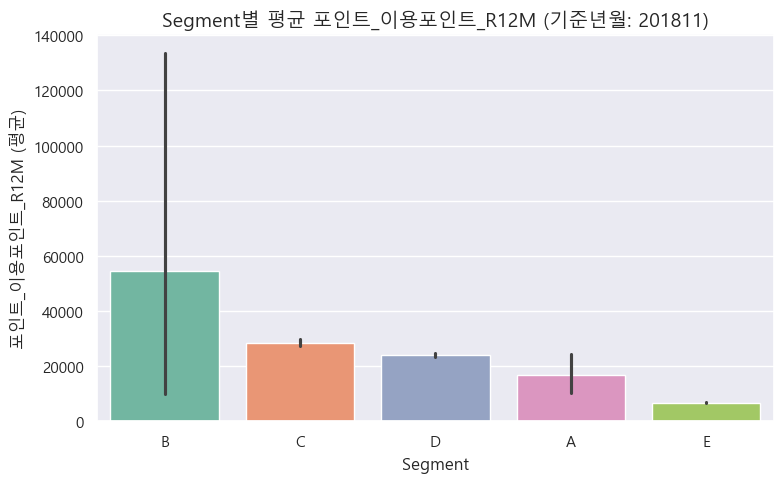

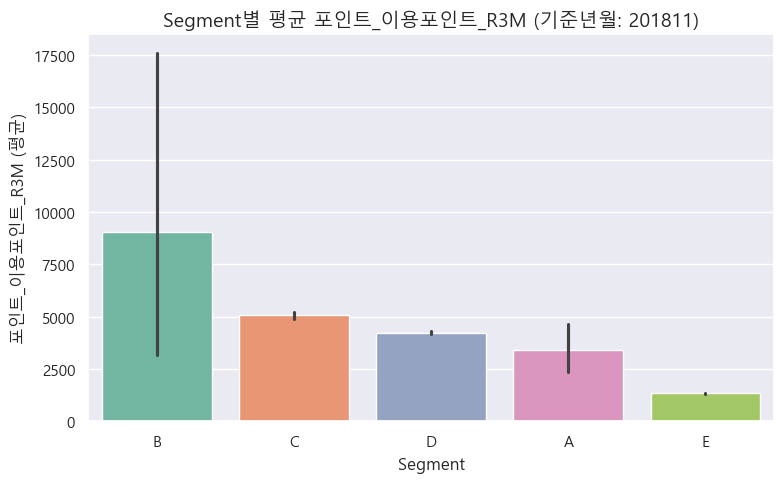

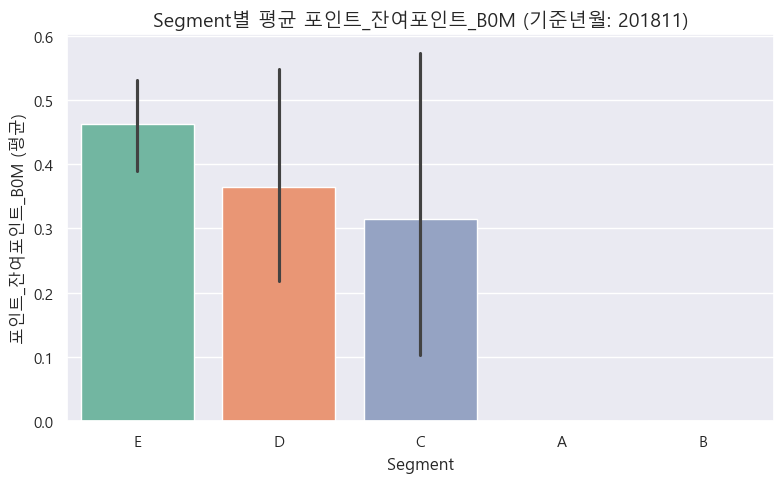

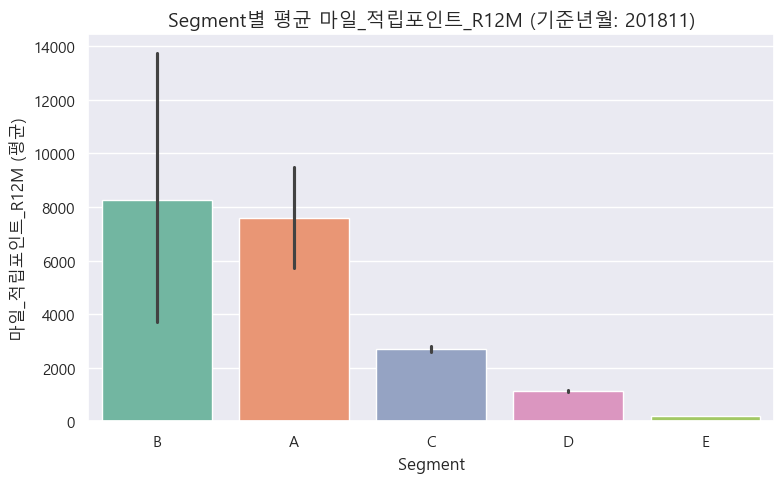

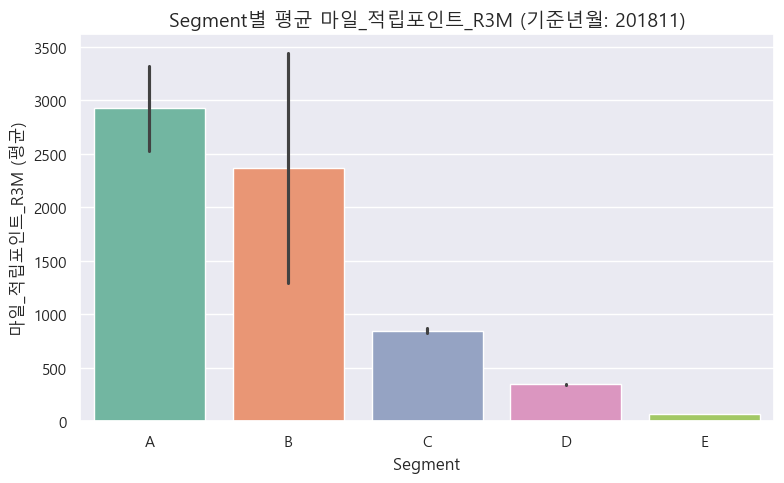

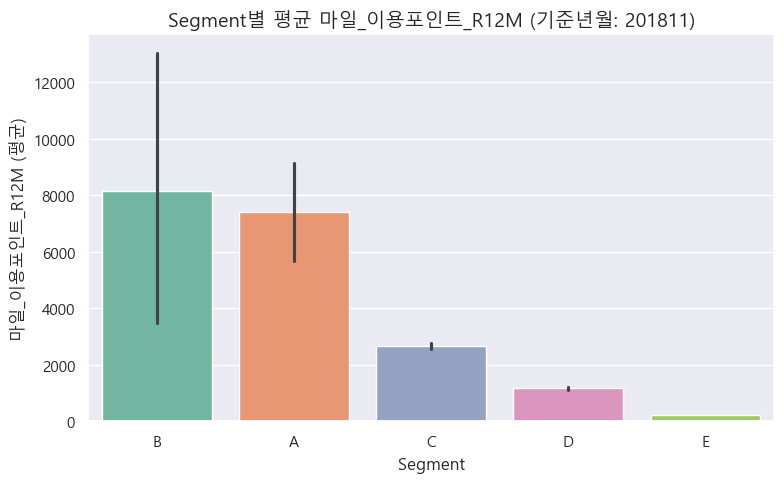

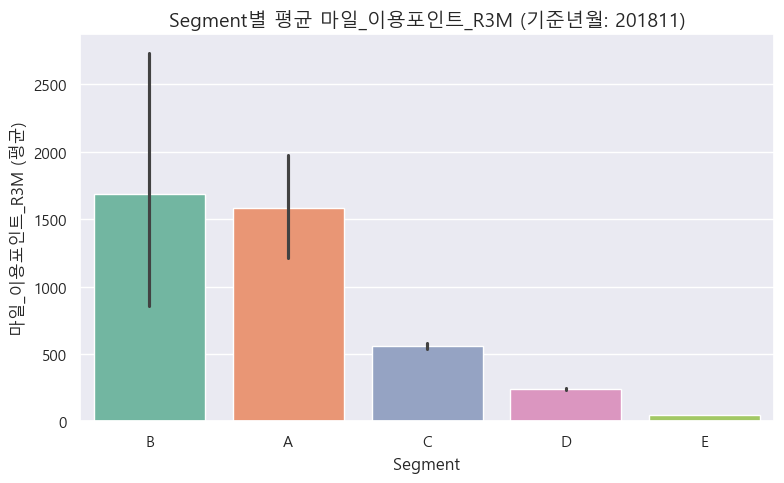

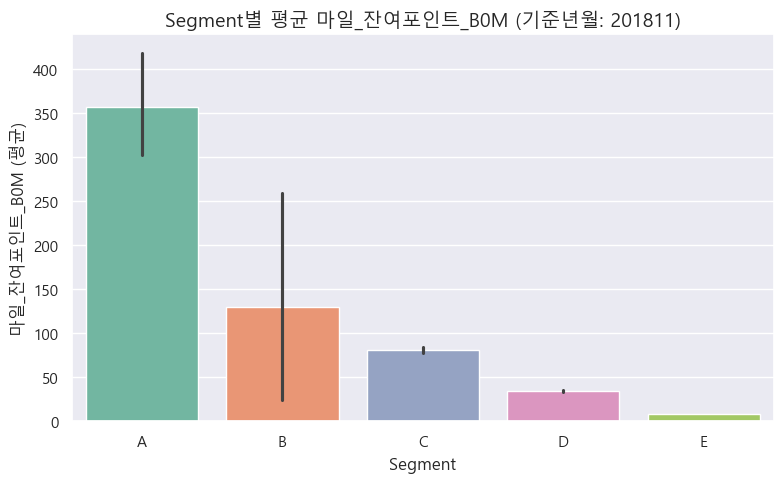

❗ 컬럼 '할인건수_R3M' 시각화 중 오류 발생: agg function failed [how->mean,dtype->object]


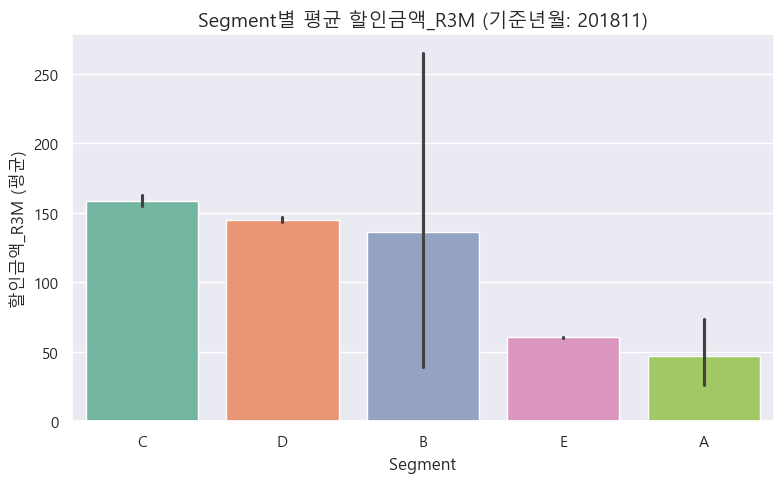

❗ 컬럼 '할인건수_B0M' 시각화 중 오류 발생: agg function failed [how->mean,dtype->object]


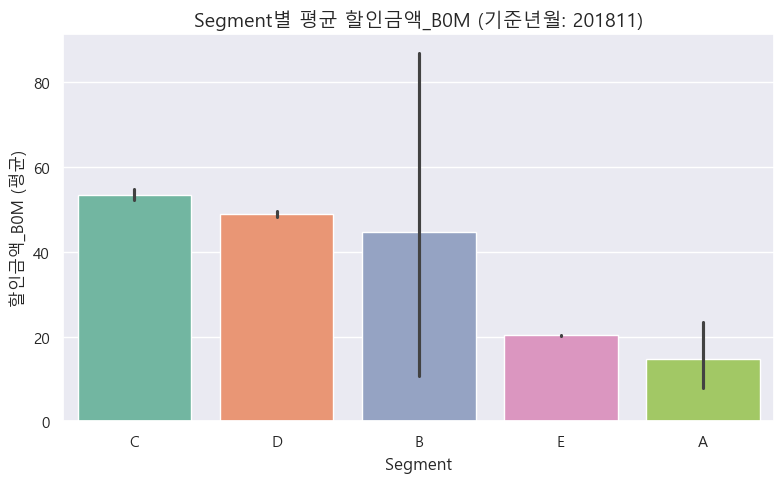

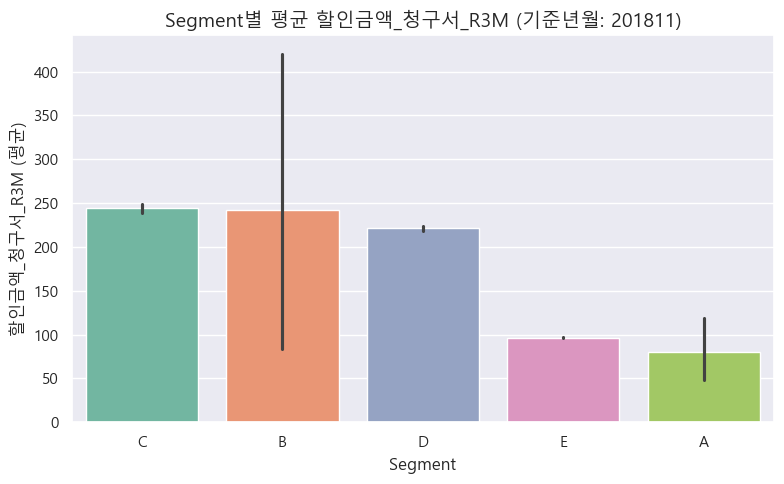

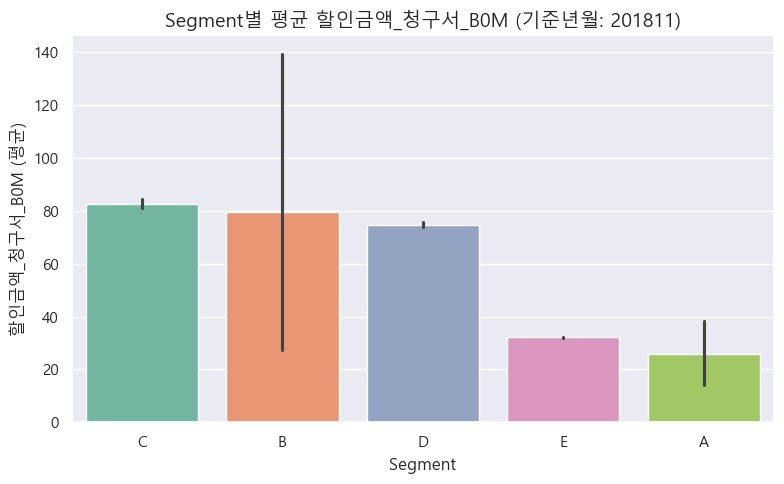

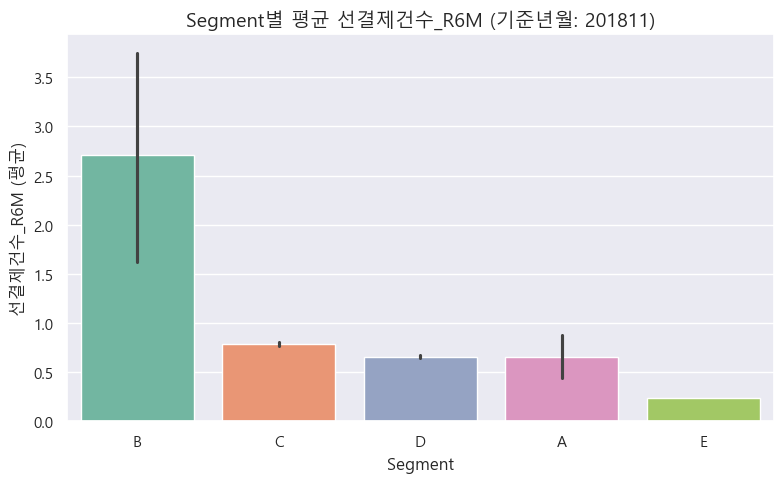

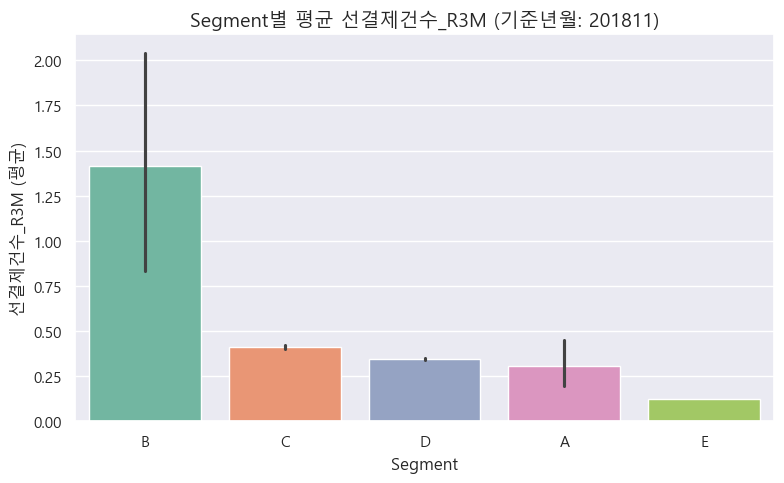

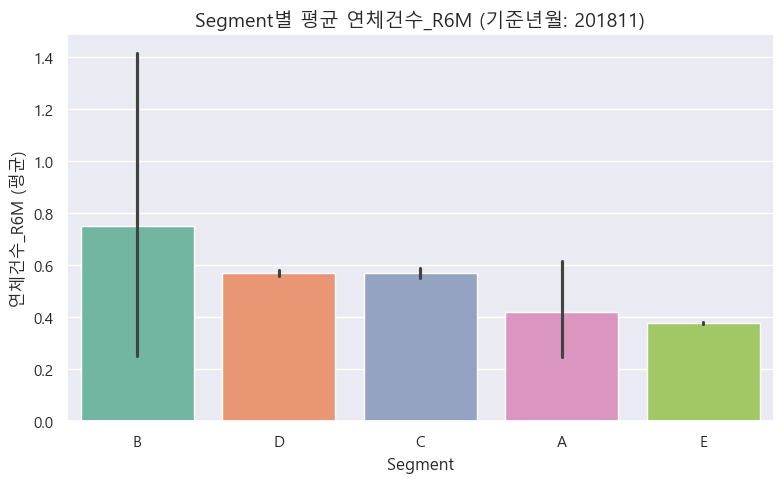

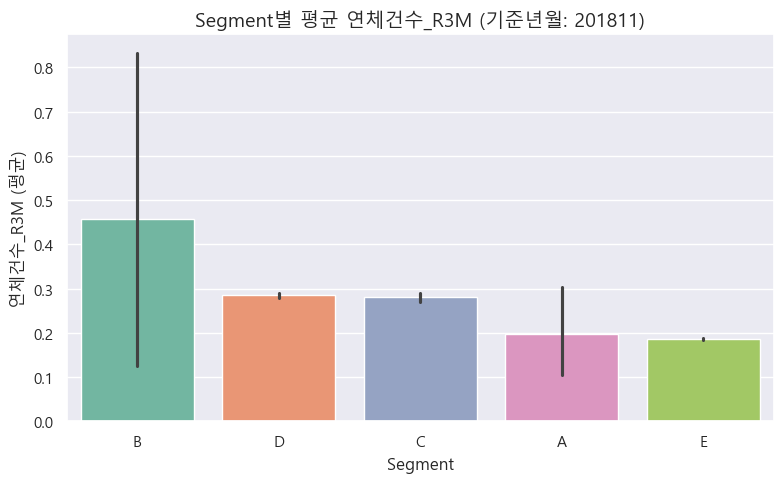

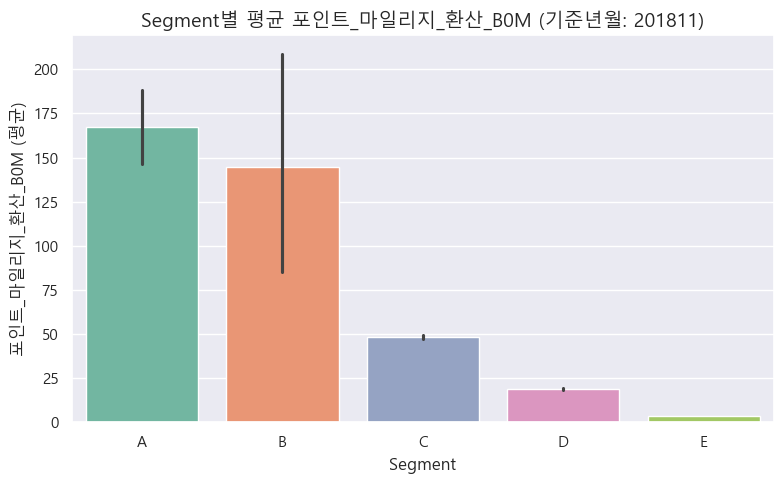

In [29]:
# 시각화 함수 정의
def plot_segment_barplot(subset, value_col, 기준월='201811'):
    try:
        segment_order = (
            subset.groupby('Segment')[value_col]
            .mean()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(8, 5))
        ax = sns.barplot(
            data=subset,
            x='Segment',
            y=value_col,
            estimator='mean',
            order=segment_order,
            palette=sns.color_palette("Set2"),
        )

        ax.set_title(f'Segment별 평균 {value_col} (기준년월: {기준월})', fontsize=14)
        ax.set_xlabel('Segment', fontsize=12)
        ax.set_ylabel(f'{value_col} (평균)', fontsize=12)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❗ 컬럼 '{value_col}' 시각화 중 오류 발생: {e}")

# 시각화할 컬럼 리스트
columns_to_plot = [
    "포인트_마일리지_건별_B0M", "포인트_마일리지_건별_R3M",
    "포인트_포인트_건별_B0M", "포인트_포인트_건별_R3M",
    "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M",
    "포인트_포인트_월적립_B0M", "포인트_포인트_월적립_R3M",
    "포인트_적립포인트_R12M", "포인트_적립포인트_R3M",
    "포인트_이용포인트_R12M", "포인트_이용포인트_R3M",
    "포인트_잔여포인트_B0M",
    "마일_적립포인트_R12M", "마일_적립포인트_R3M",
    "마일_이용포인트_R12M", "마일_이용포인트_R3M",
    "마일_잔여포인트_B0M",
    "할인건수_R3M", "할인금액_R3M", "할인건수_B0M", "할인금액_B0M",
    "할인금액_청구서_R3M", "할인금액_청구서_B0M",
    "선결제건수_R6M", "선결제건수_R3M",
    "연체건수_R6M", "연체건수_R3M",
    "포인트_마일리지_환산_B0M"
]

# 반복 실행
for col in columns_to_plot:
    plot_segment_barplot(subset, col)


In [9]:
# 필요한 컬럼만 추출
cols = ['Segment', '포인트_마일리지_월적립_B0M', '포인트_마일리지_월적립_R3M']
df_melted = subset[cols].melt(id_vars='Segment', var_name='항목_기간', value_name='값')

# 항목과 기간 분리
df_melted[['항목', '기간']] = df_melted['항목_기간'].str.rsplit('_', n=1, expand=True)

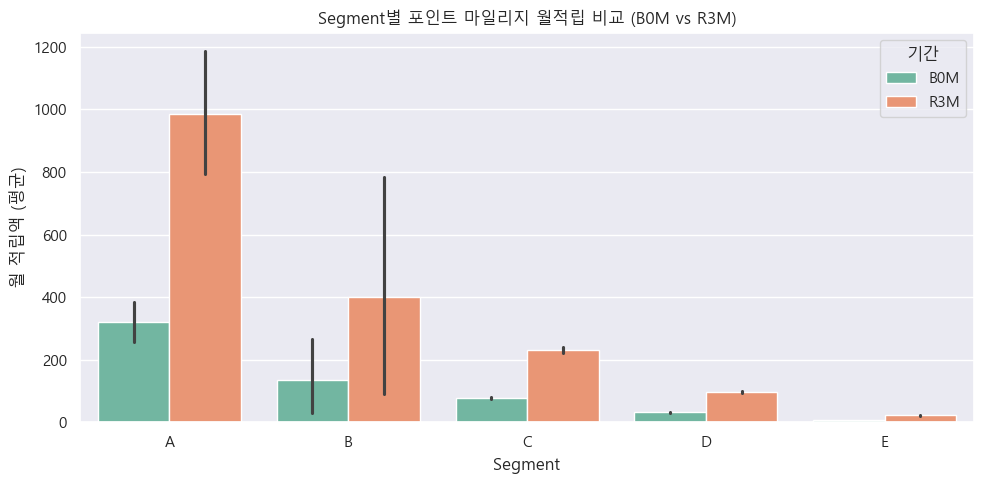

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_melted[df_melted['항목'] == '포인트_마일리지_월적립'],
    x='Segment',
    y='값',
    hue='기간',
    estimator='mean',
    order=sorted(df_melted['Segment'].unique()),  # ✅ 세그먼트 이름 기준 정렬
    palette='Set2'
)
plt.title('Segment별 포인트 마일리지 월적립 비교 (B0M vs R3M)')
plt.xlabel('Segment')
plt.ylabel('월 적립액 (평균)')
plt.tight_layout()
plt.show()


In [49]:
def plot_segment_histogram(subset, value_col, 기준월='201811', bins=10):
    try:
        if not pd.api.types.is_numeric_dtype(subset[value_col]):
            print(f"⚠️ '{value_col}'은 수치형이 아니므로 스킵합니다.")
            return

        plt.figure(figsize=(10, 5))
        sns.histplot(
            data=subset,
            x=value_col,
            hue='Segment',
            multiple='dodge',  # 겹치지 않게 옆으로 나란히
            palette='Set2',
            bins=bins,
            shrink=0.8,
            edgecolor="gray"
        )
        plt.title(f"{value_col} 도수분포 (기준년월: {기준월})", fontsize=14)
        plt.xlabel("값의 구간", fontsize=12)
        plt.ylabel("도수 (빈도수)", fontsize=12)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❗ 히스토그램 시각화 오류 ({value_col}): {e}")


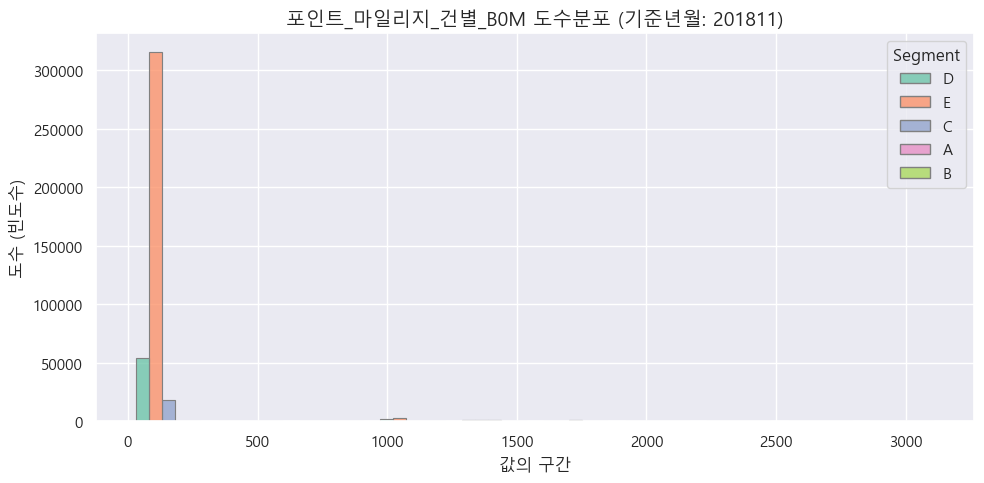

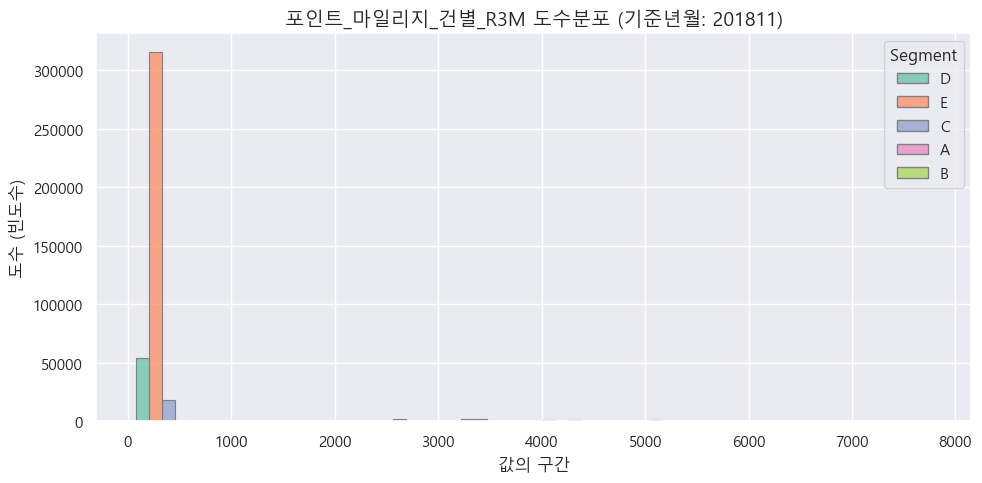

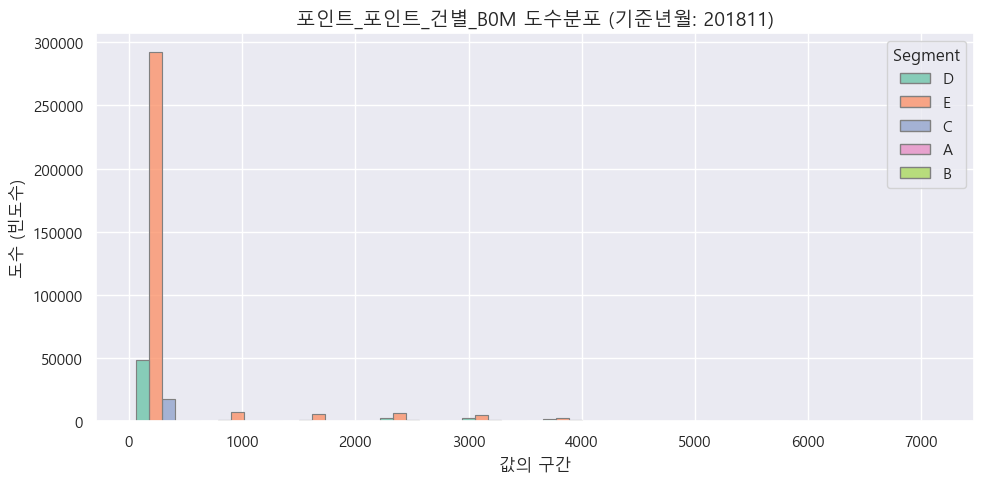

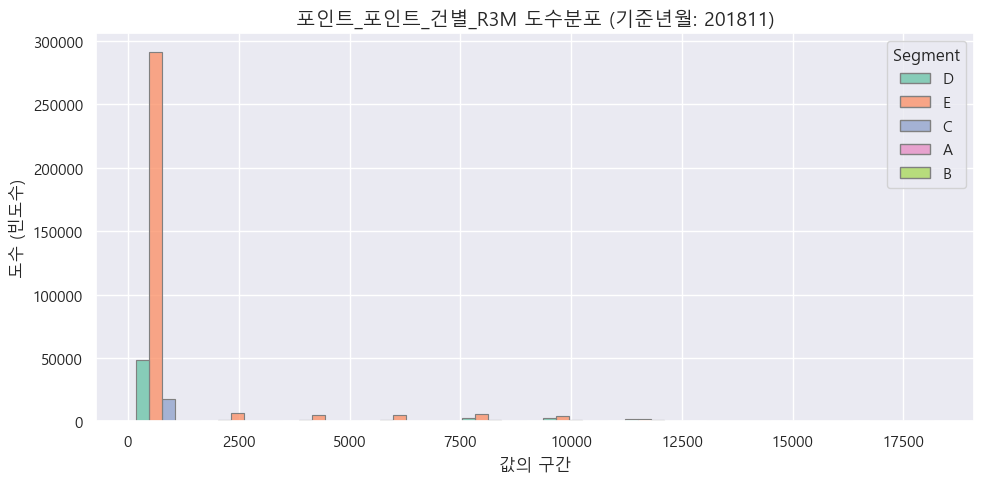

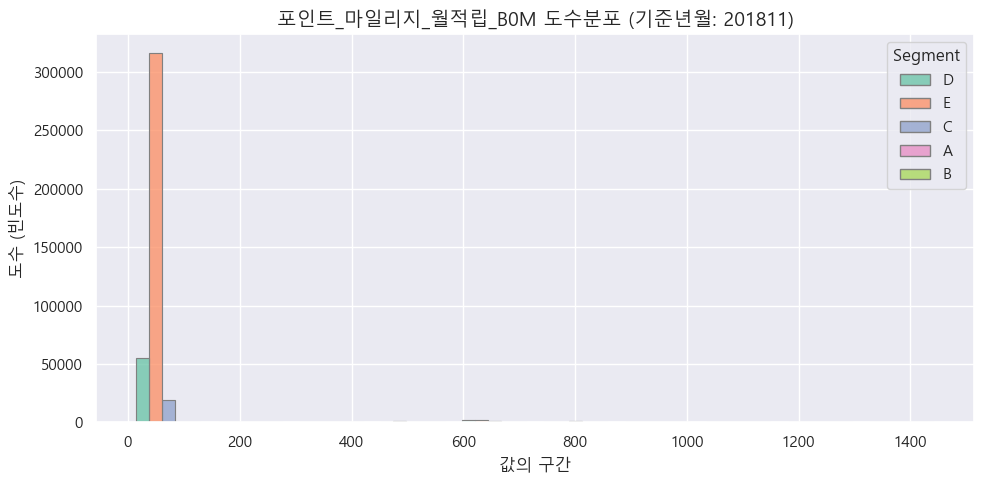

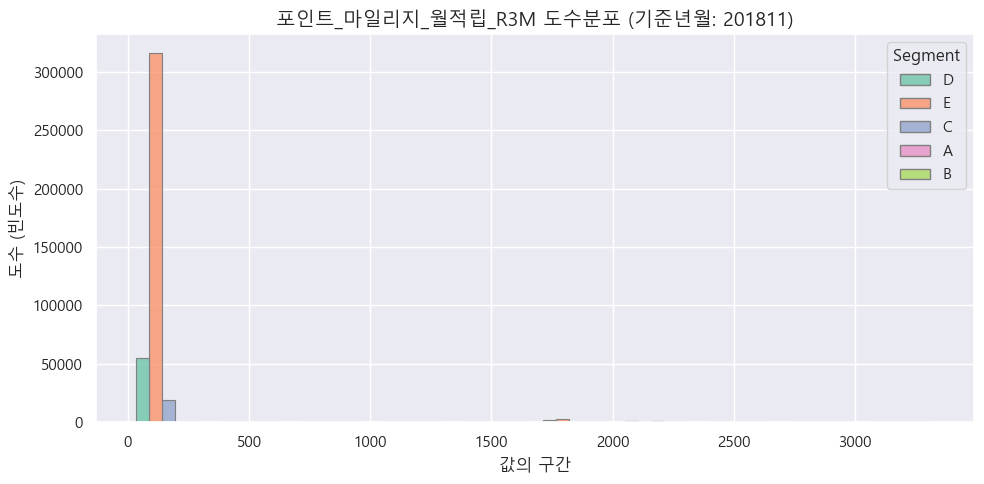

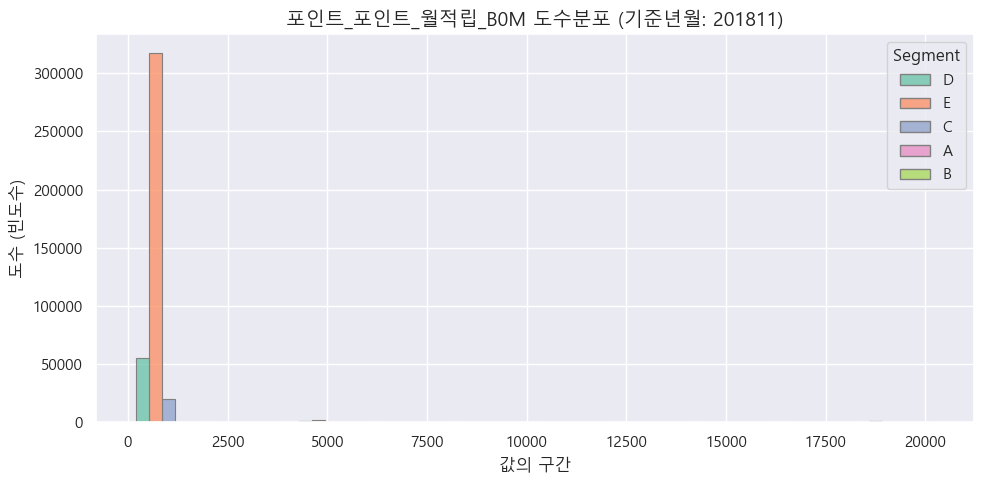

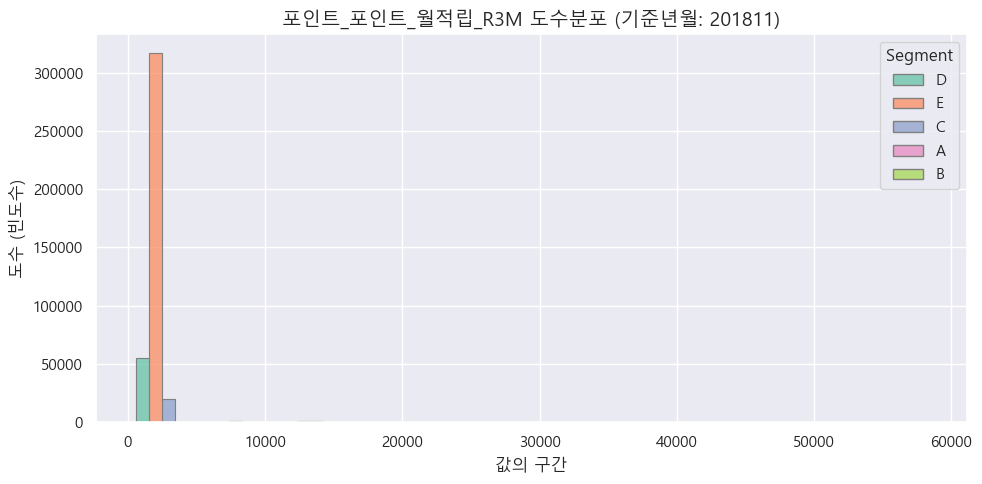

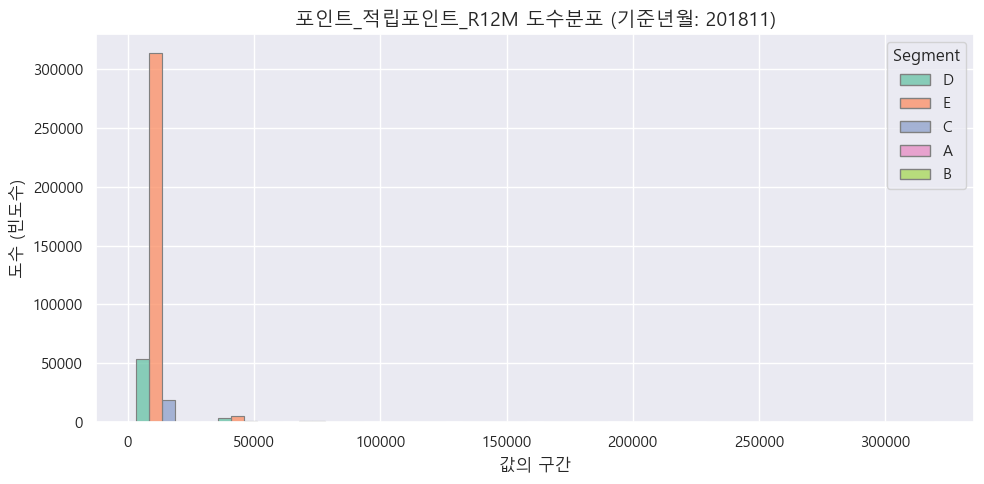

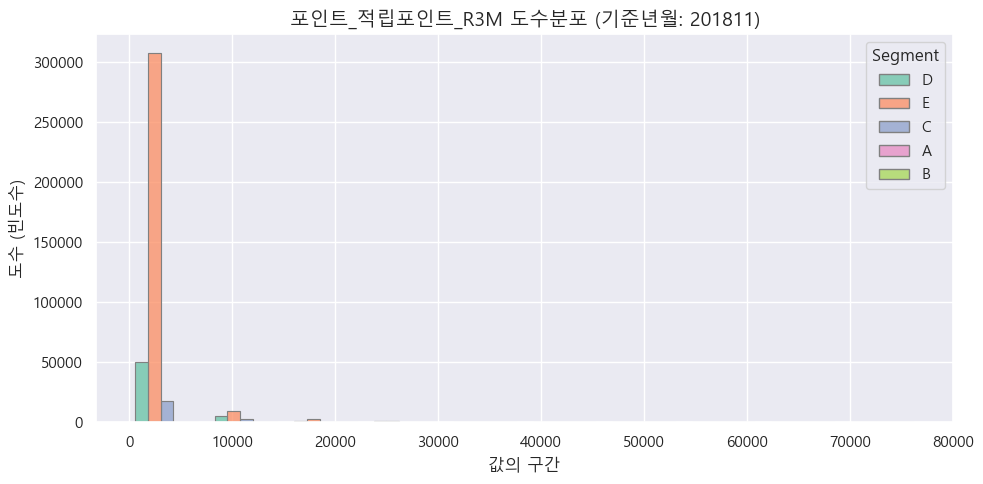

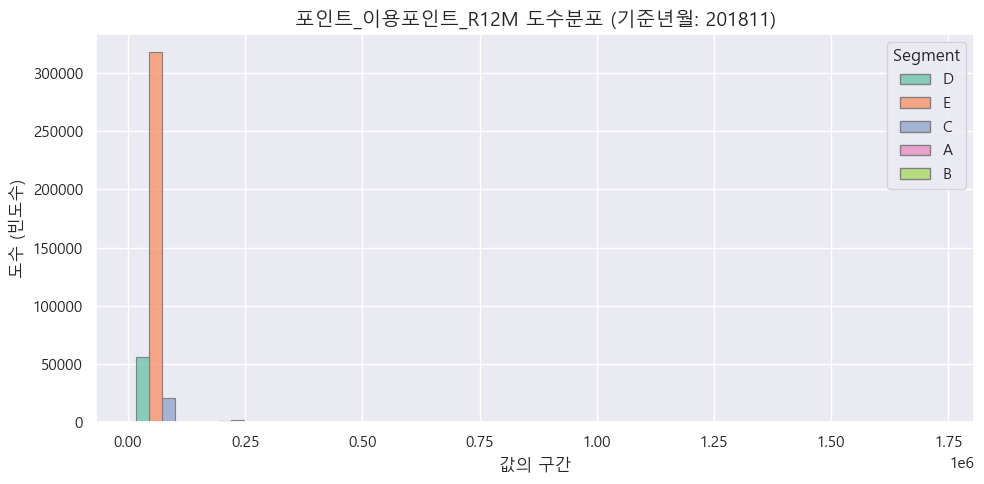

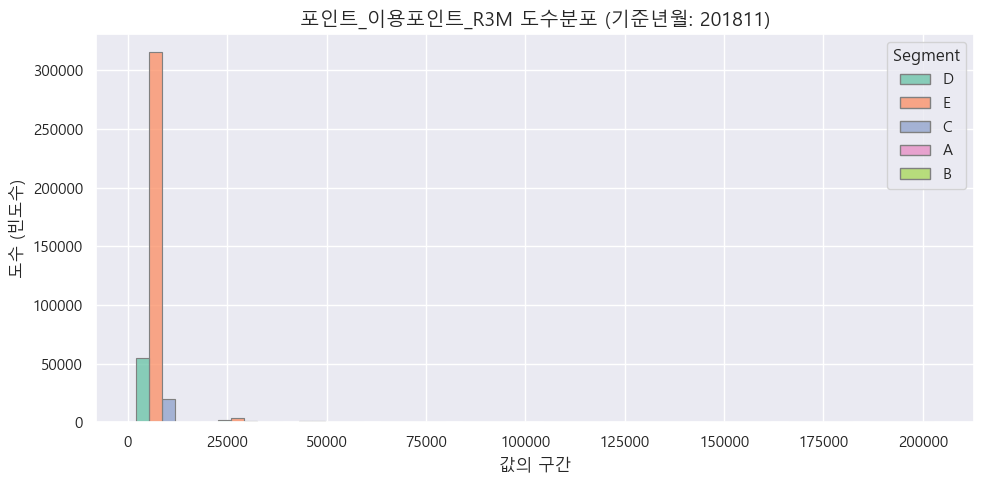

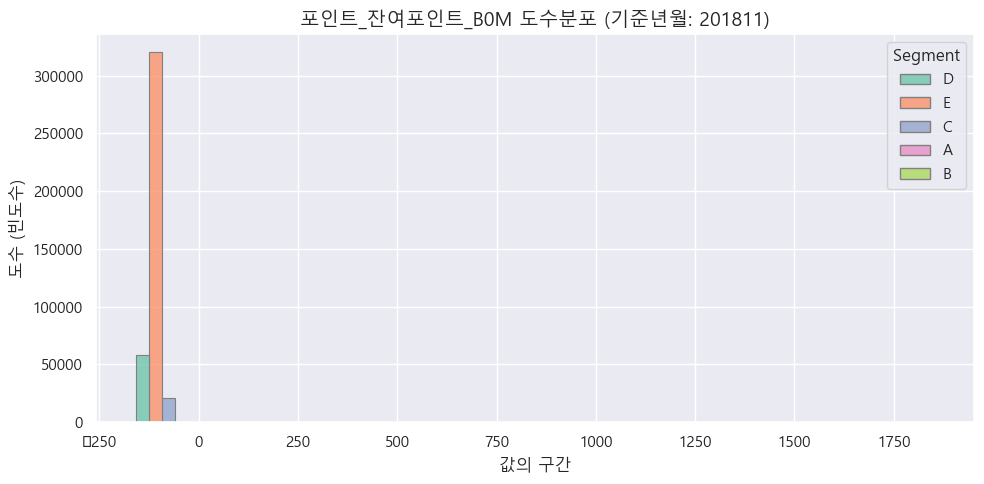

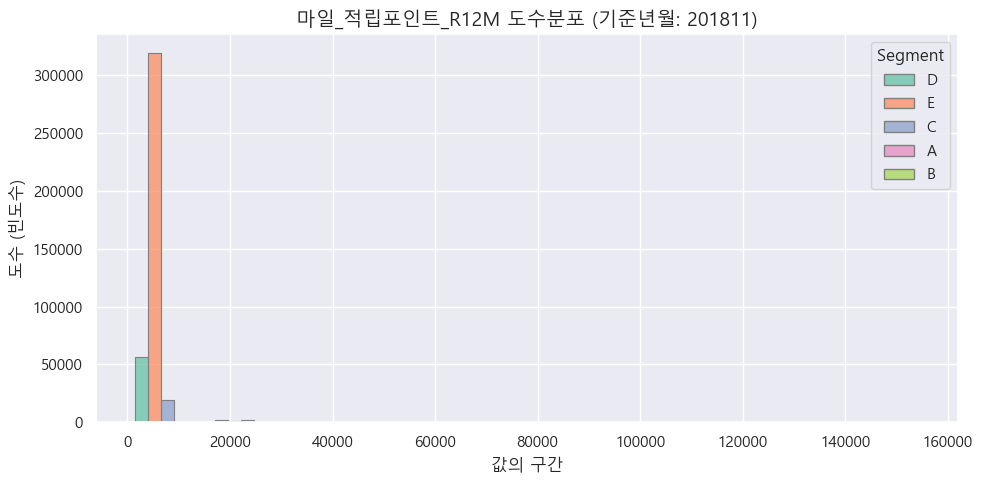

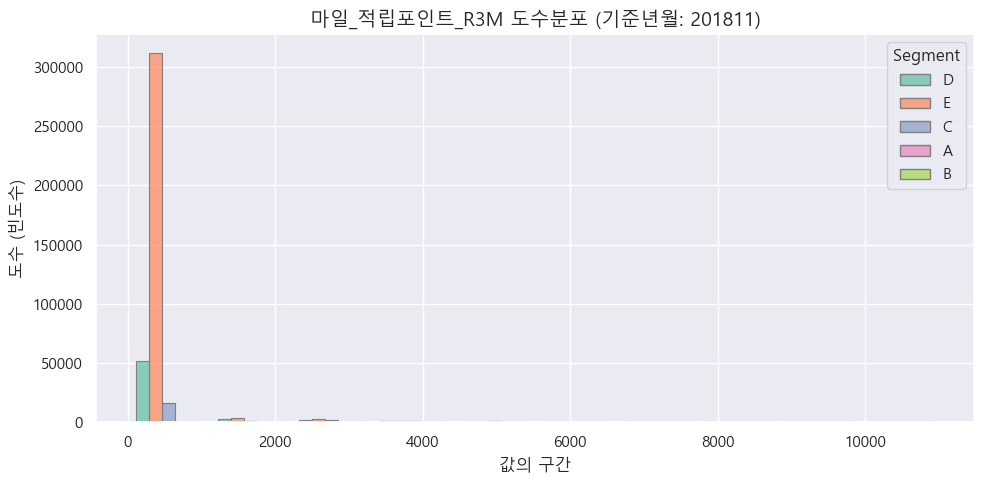

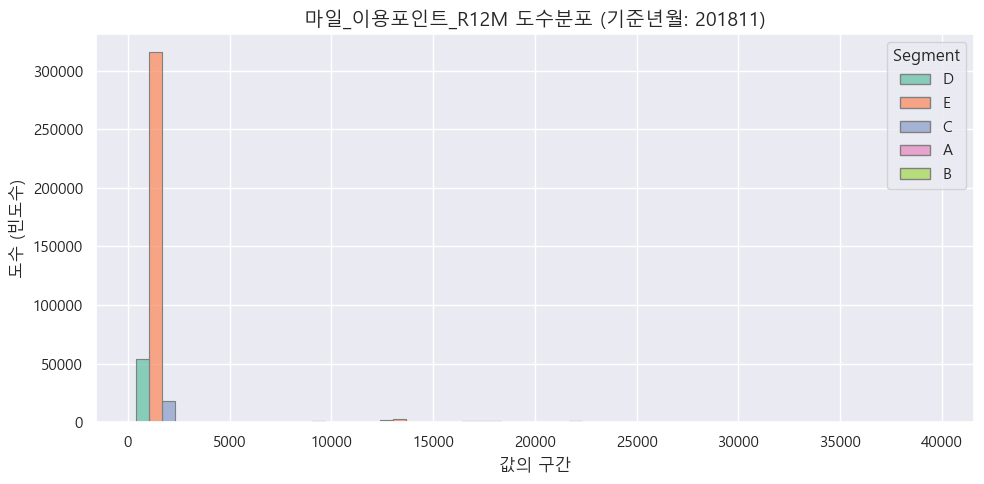

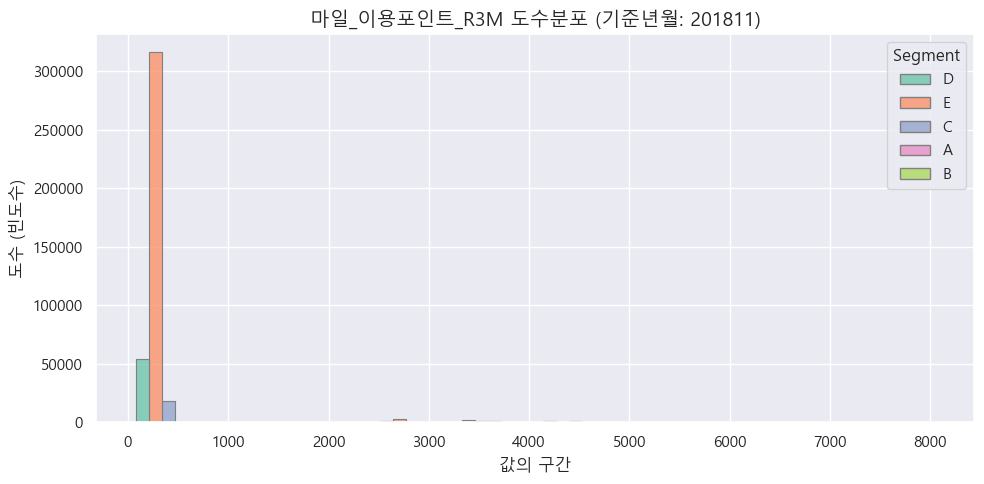

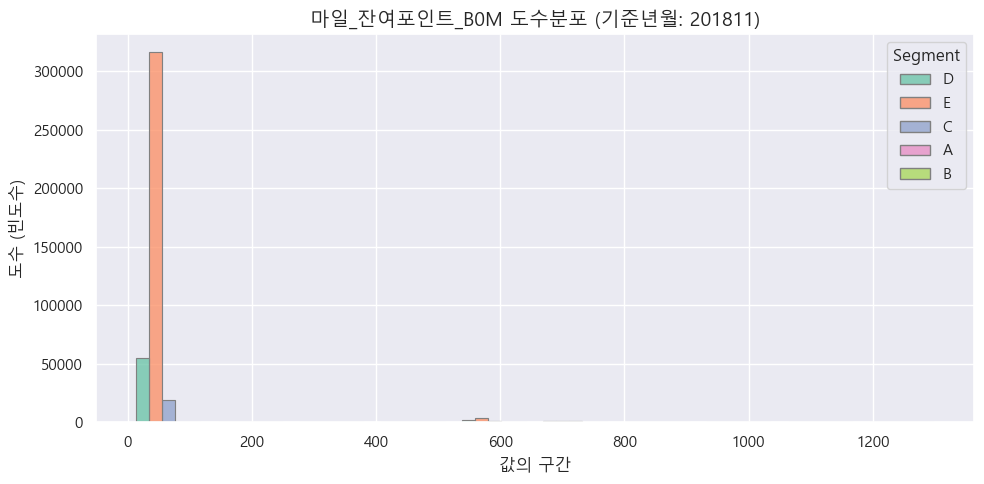

⚠️ '할인건수_R3M'은 수치형이 아니므로 스킵합니다.


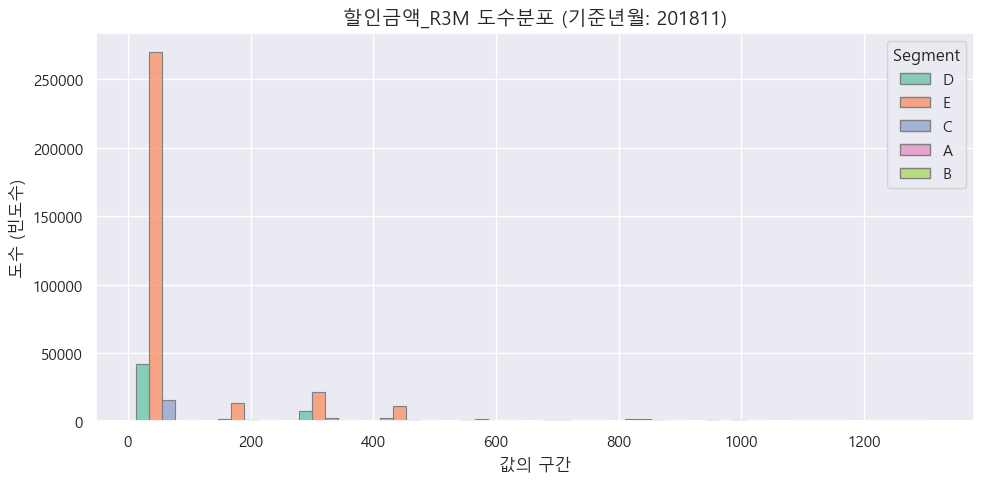

⚠️ '할인건수_B0M'은 수치형이 아니므로 스킵합니다.


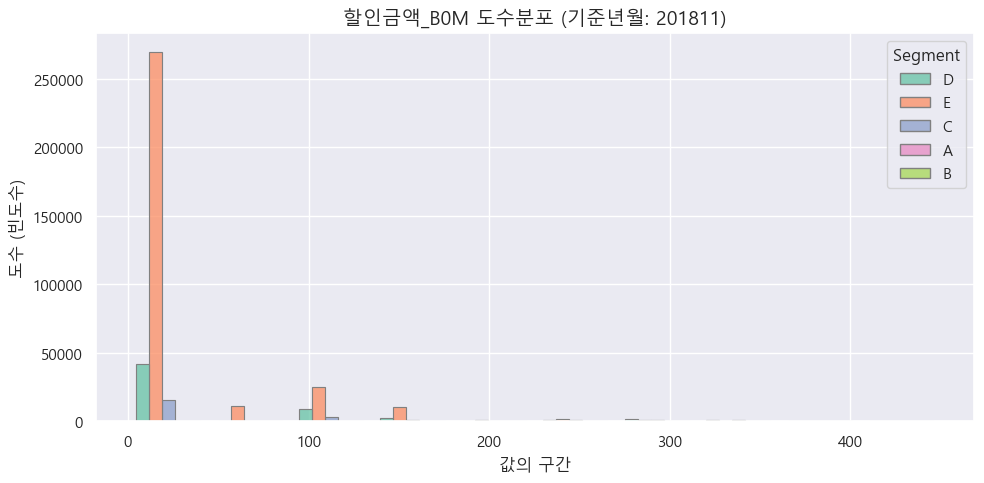

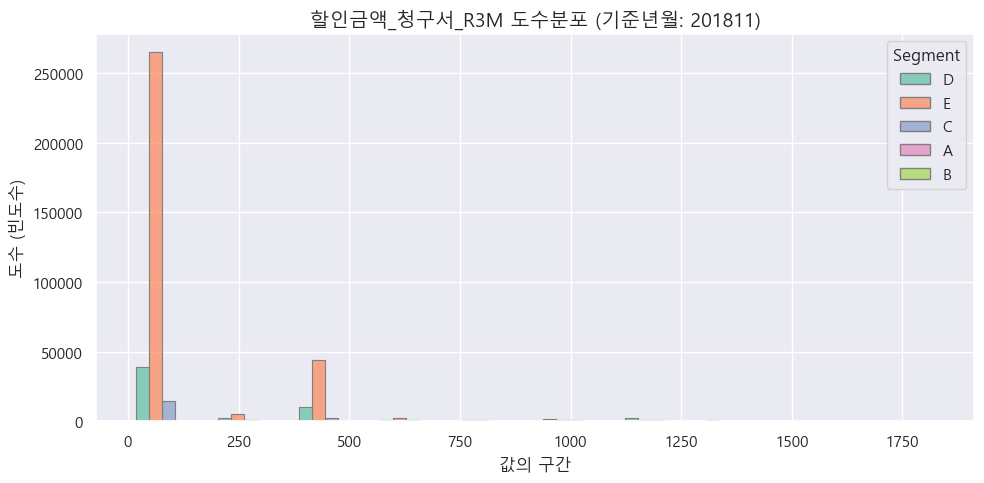

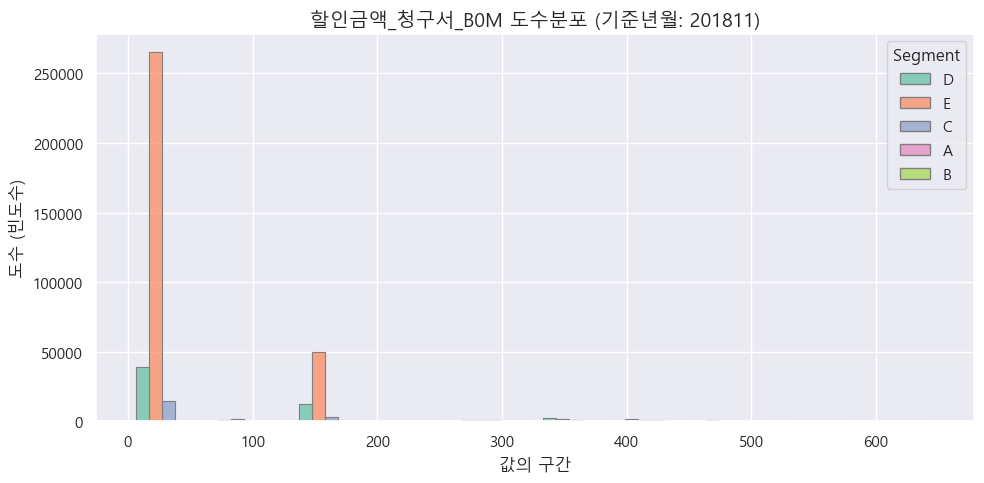

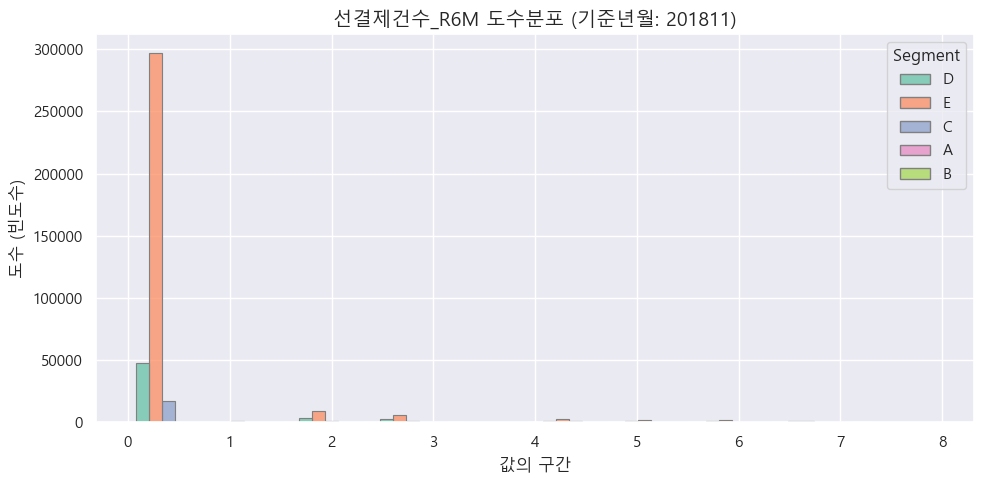

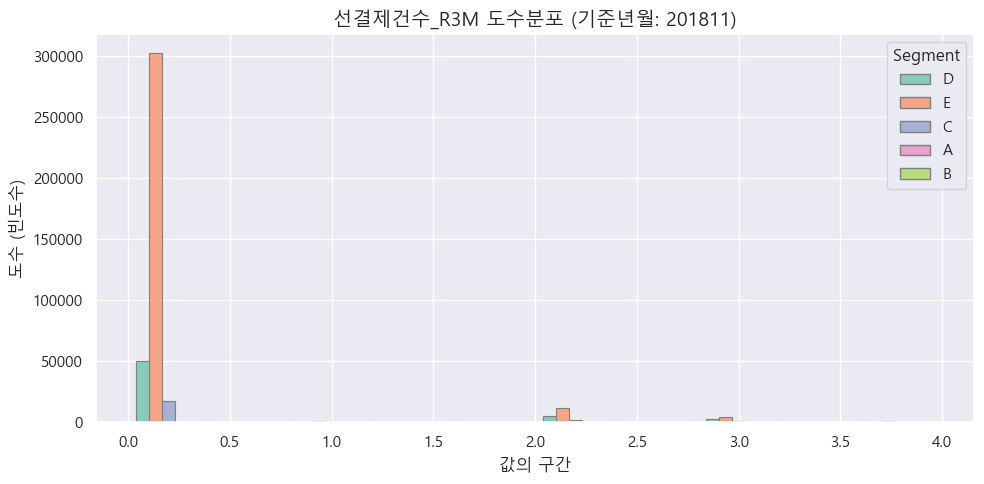

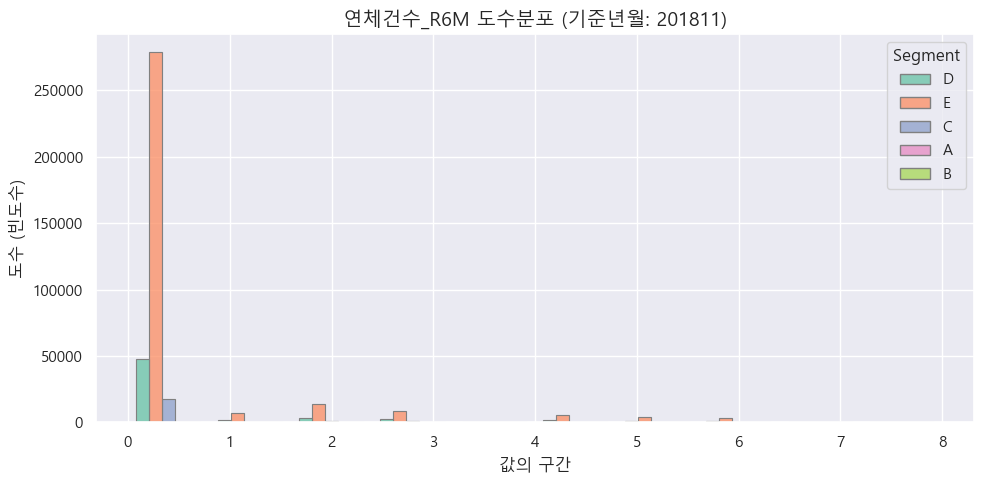

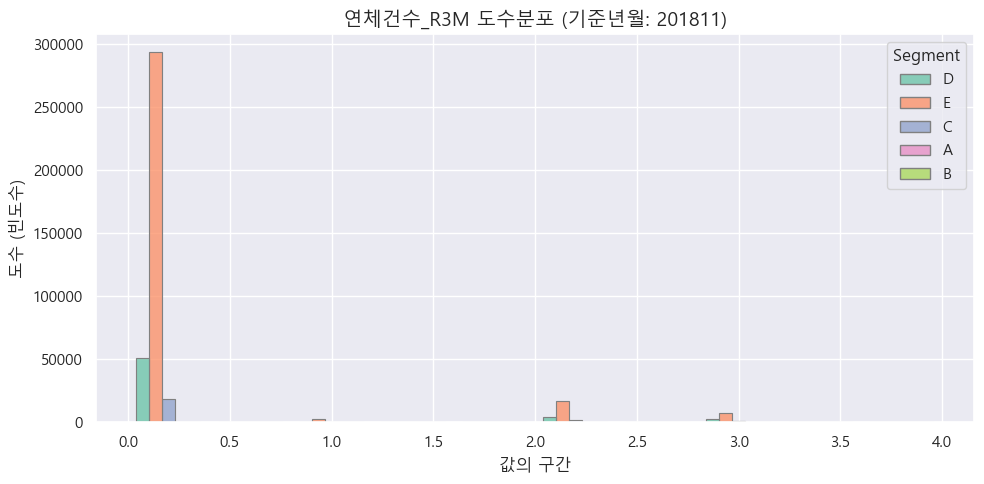

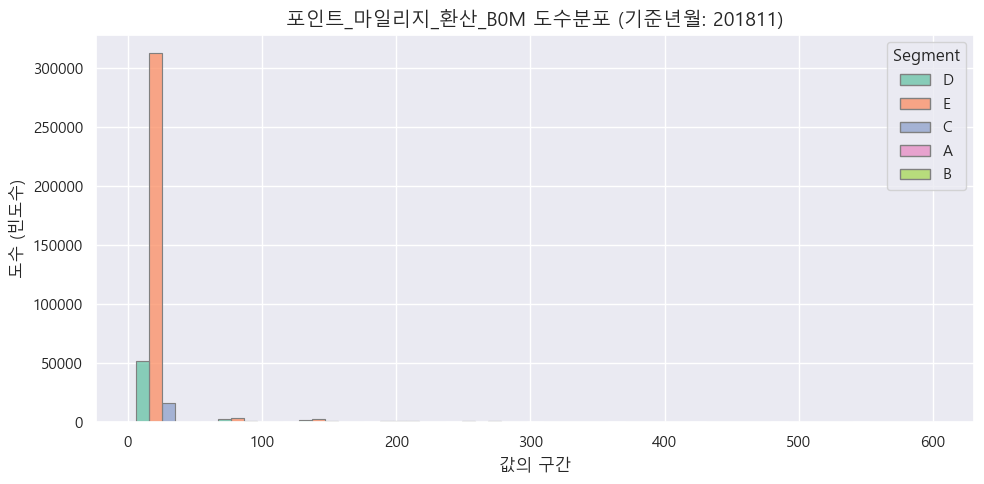

In [60]:
# 시각화할 컬럼 리스트
columns_to_plot = [
    "포인트_마일리지_건별_B0M", "포인트_마일리지_건별_R3M",
    "포인트_포인트_건별_B0M", "포인트_포인트_건별_R3M",
    "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M",
    "포인트_포인트_월적립_B0M", "포인트_포인트_월적립_R3M",
    "포인트_적립포인트_R12M", "포인트_적립포인트_R3M",
    "포인트_이용포인트_R12M", "포인트_이용포인트_R3M",
    "포인트_잔여포인트_B0M",
    "마일_적립포인트_R12M", "마일_적립포인트_R3M",
    "마일_이용포인트_R12M", "마일_이용포인트_R3M",
    "마일_잔여포인트_B0M",
    "할인건수_R3M", "할인금액_R3M", "할인건수_B0M", "할인금액_B0M",
    "할인금액_청구서_R3M", "할인금액_청구서_B0M",
    "선결제건수_R6M", "선결제건수_R3M",
    "연체건수_R6M", "연체건수_R3M",
    "포인트_마일리지_환산_B0M" 
]

for col in columns_to_plot:
    plot_segment_histogram(subset, col)

In [53]:
def plot_segment_kde(subset, value_col):
    try:
        # 수치형이 아닐 경우 스킵
        if not pd.api.types.is_numeric_dtype(subset[value_col]):
            print(f"⚠️ 컬럼 '{value_col}'은 수치형이 아니므로 스킵합니다.")
            return

        plt.figure(figsize=(10, 5))
        sns.kdeplot(
            data=subset,
            x=value_col,
            hue="Segment",
            common_norm=False,  # 세그먼트별 독립 밀도 계산
            fill=True,
            alpha=0.3,
            linewidth=1.5,
        )
        plt.title(f"{value_col} 분포 (KDE) by Segment")
        plt.xlabel(value_col)
        plt.ylabel("밀도")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❗ KDE 시각화 오류 ({value_col}): {e}")


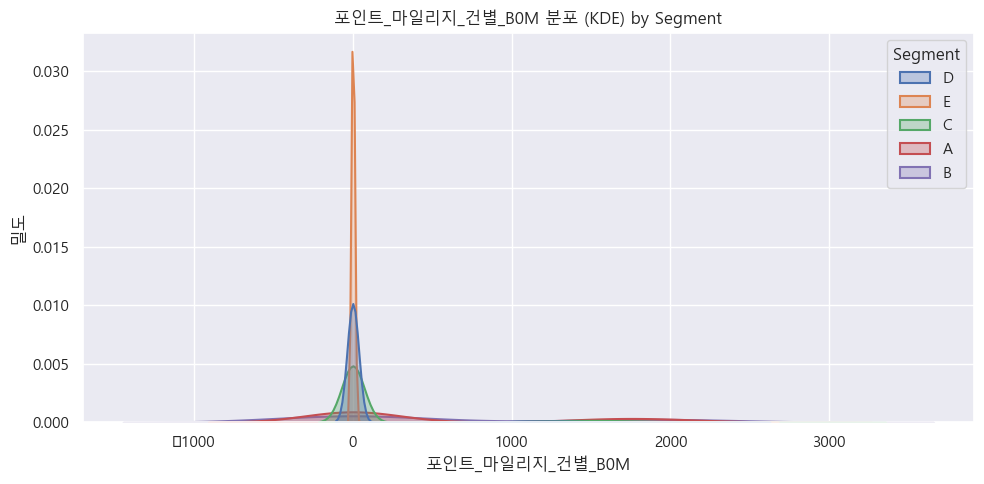

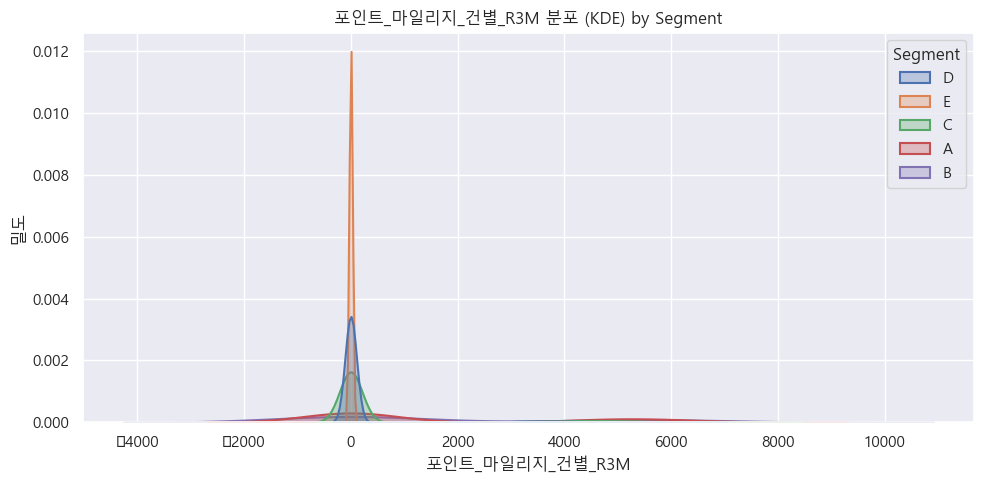

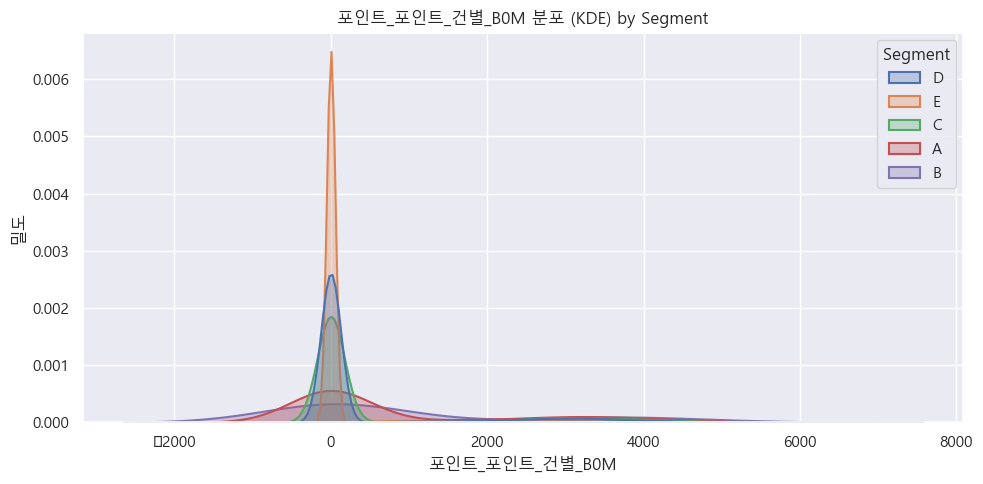

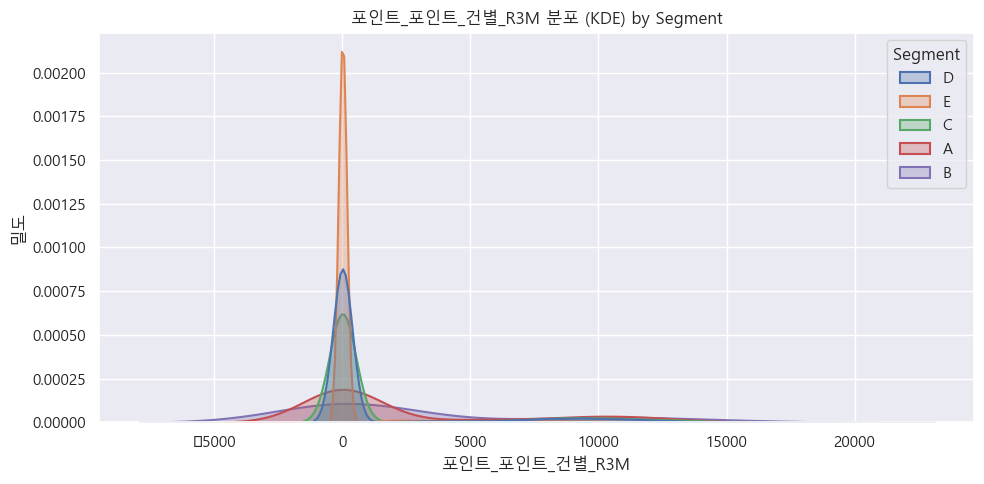

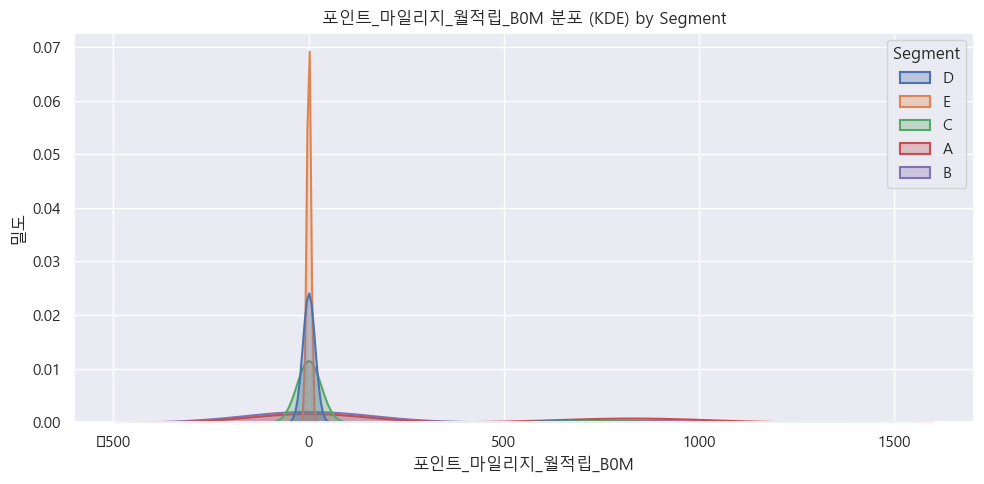

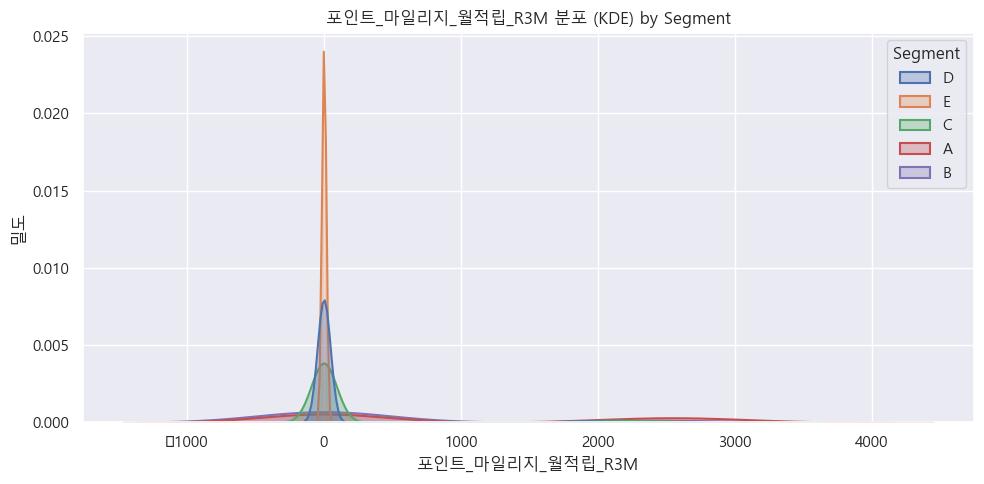

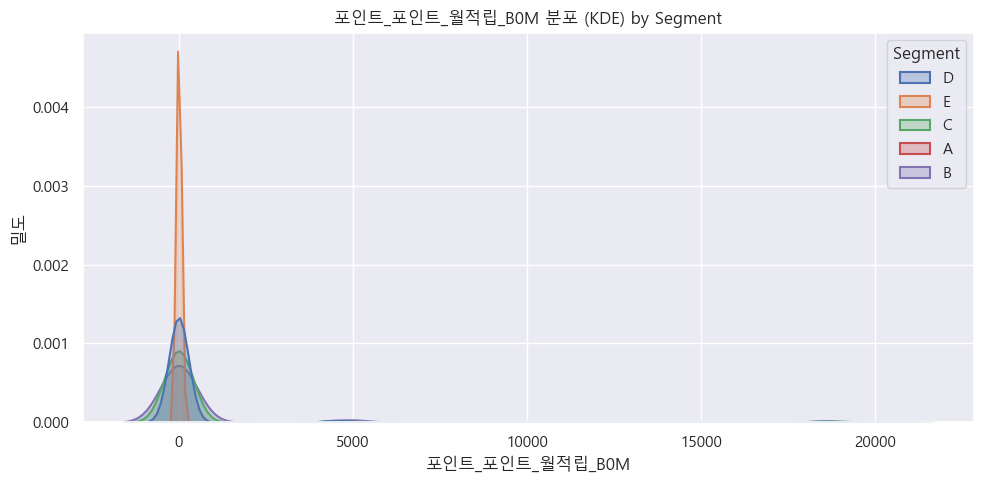

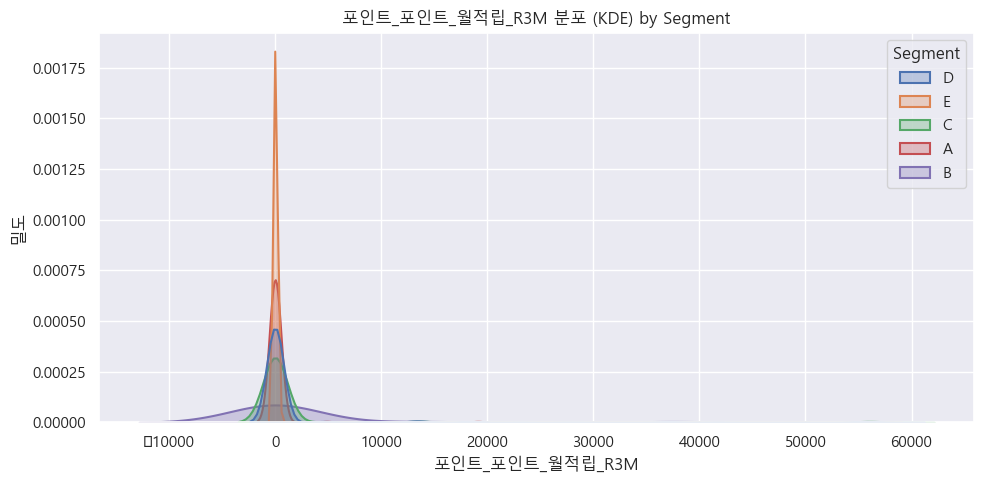

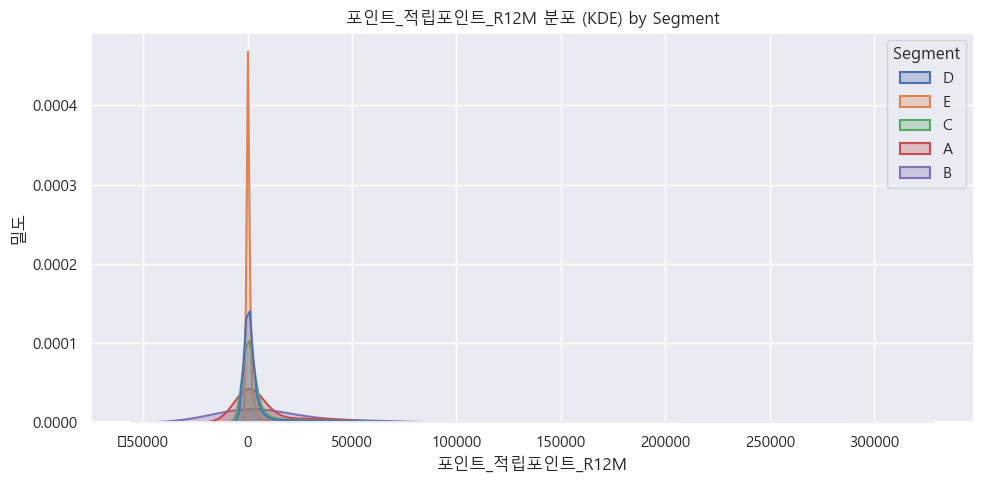

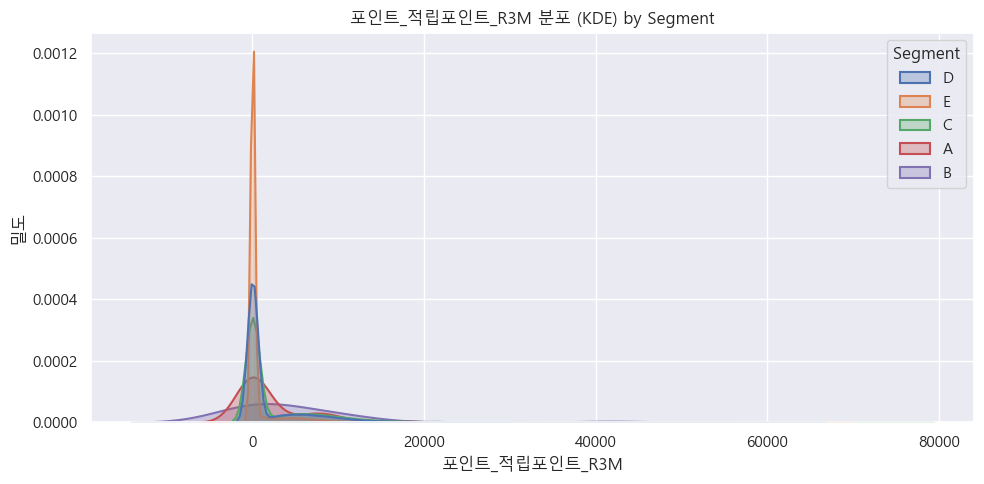

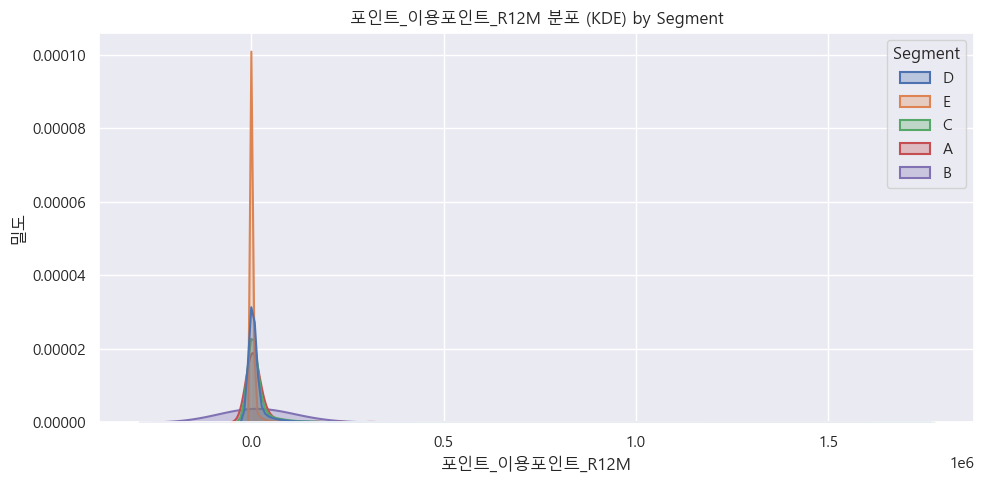

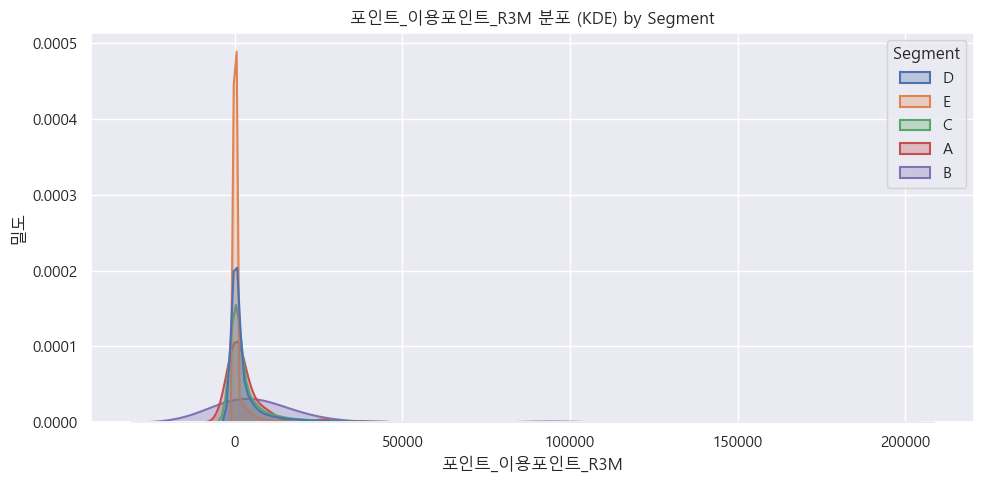

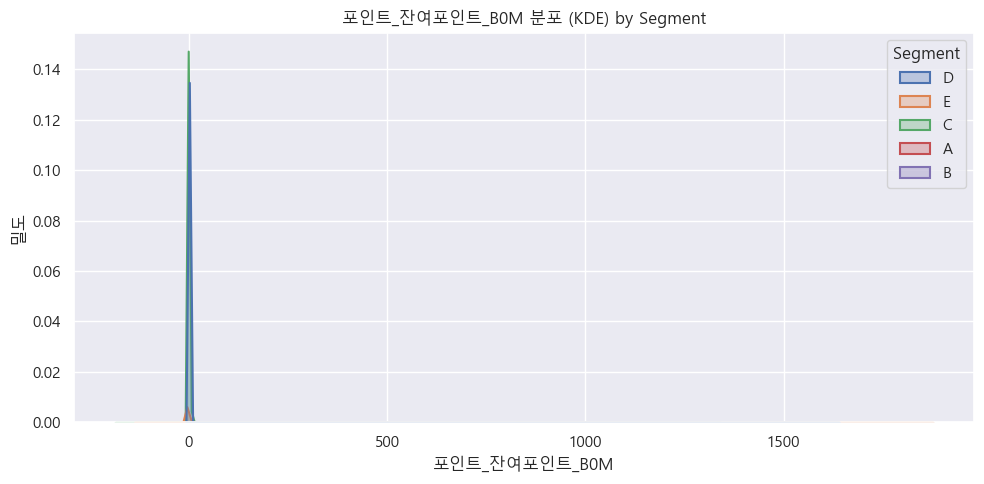

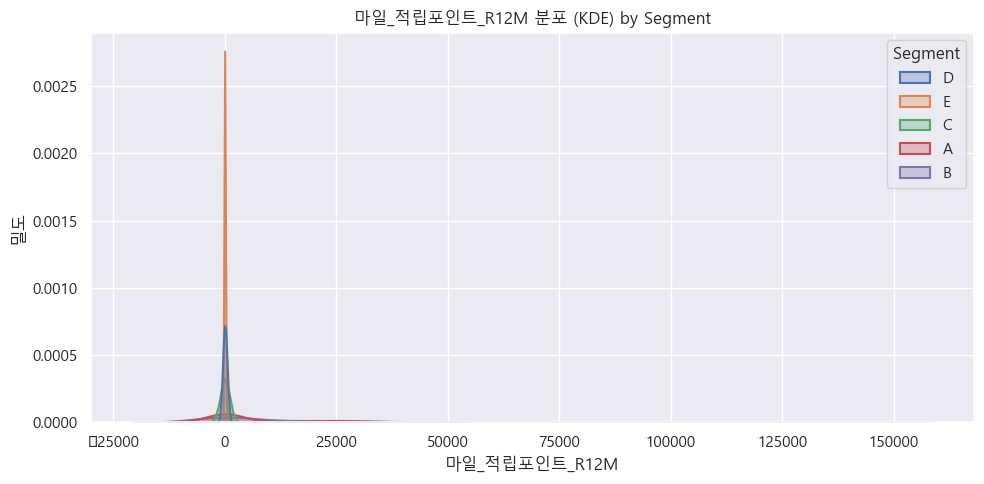

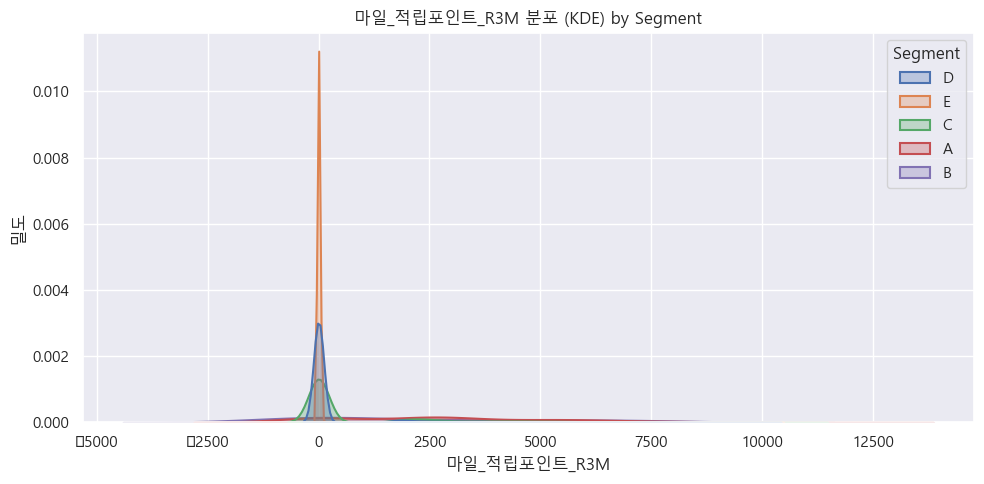

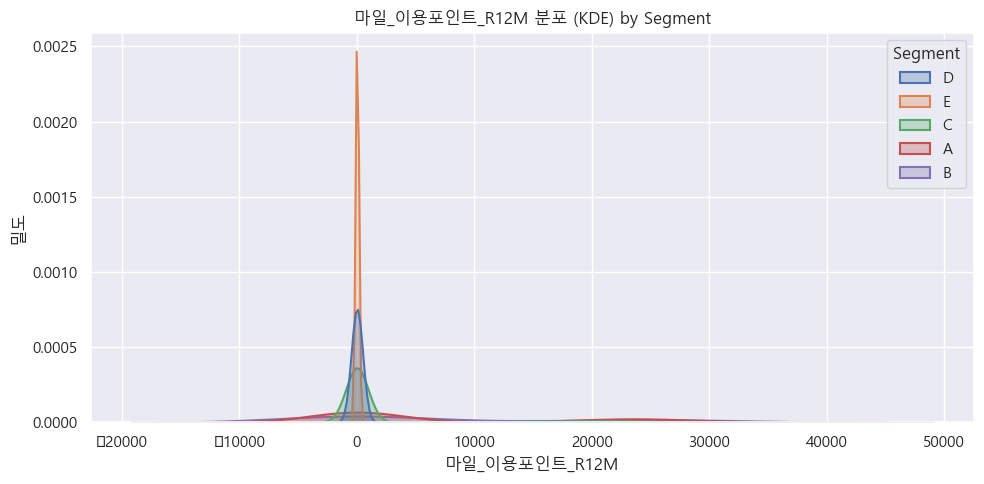

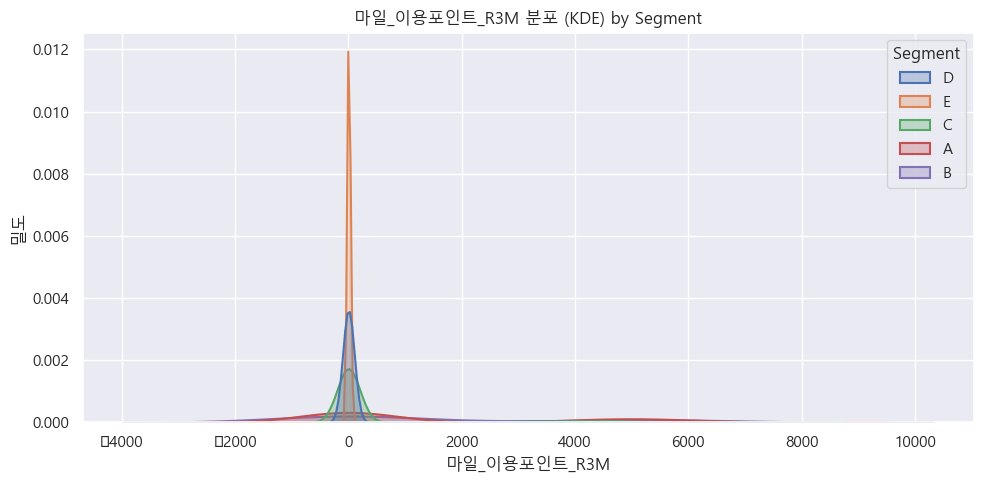

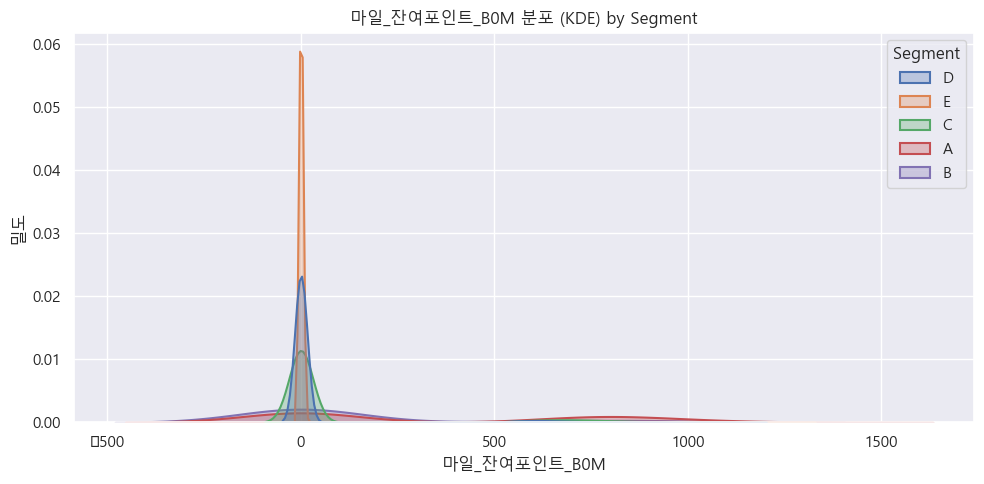

⚠️ 컬럼 '할인건수_R3M'은 수치형이 아니므로 스킵합니다.


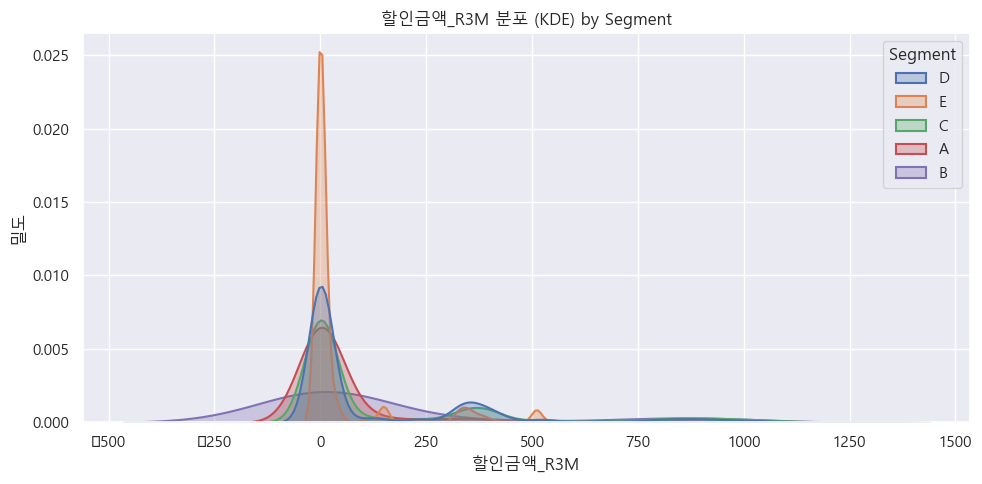

⚠️ 컬럼 '할인건수_B0M'은 수치형이 아니므로 스킵합니다.


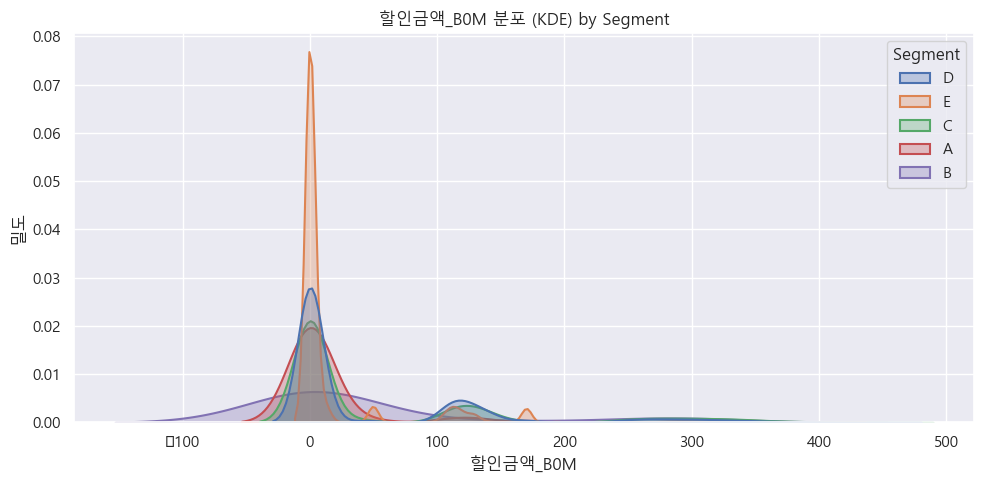

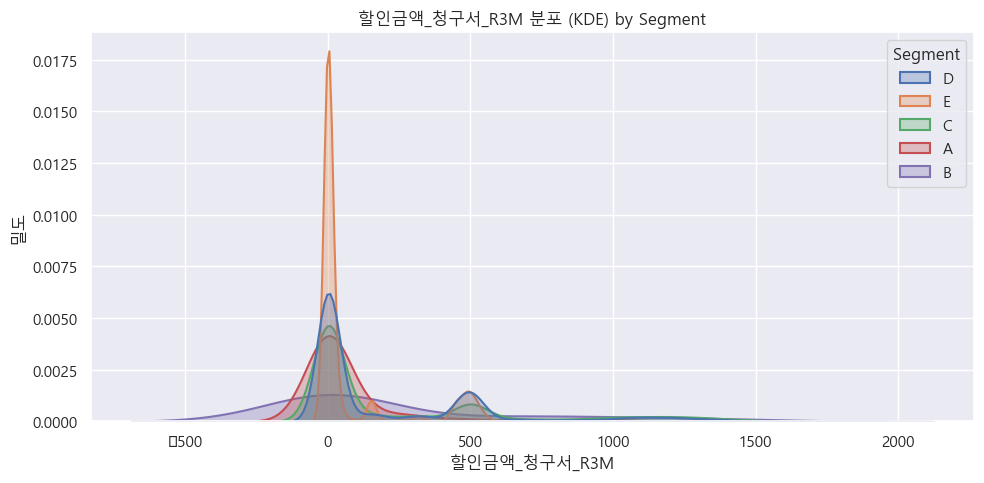

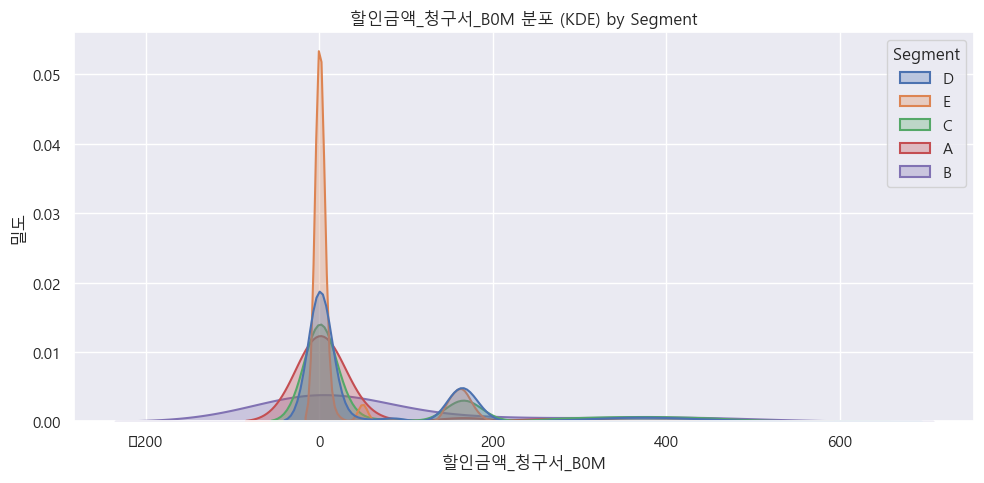

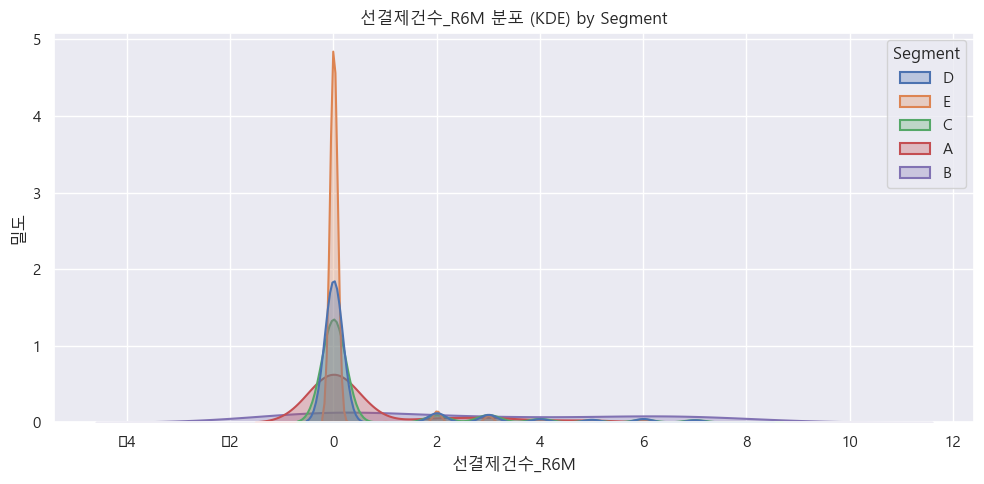

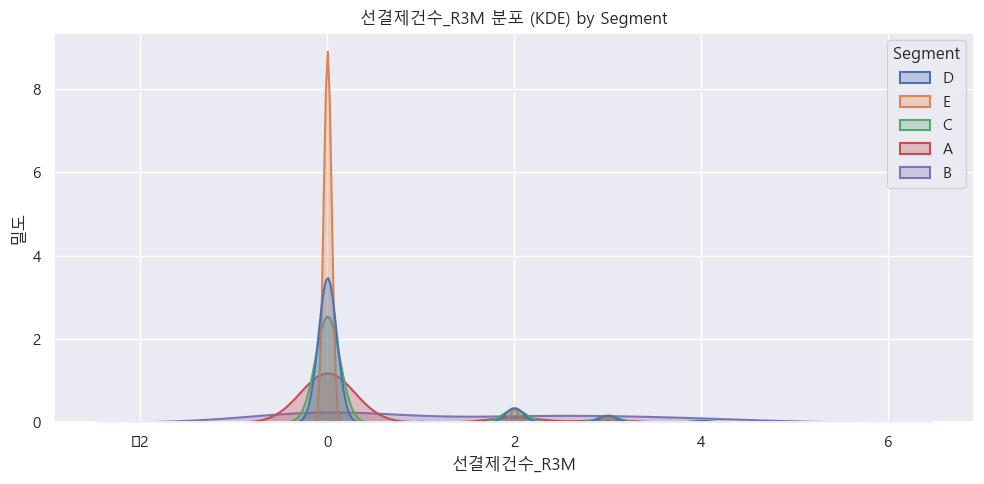

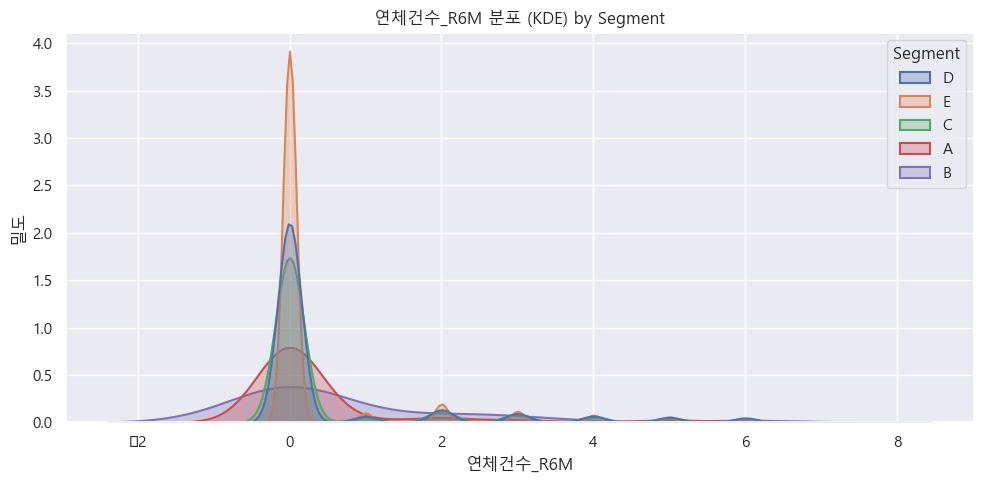

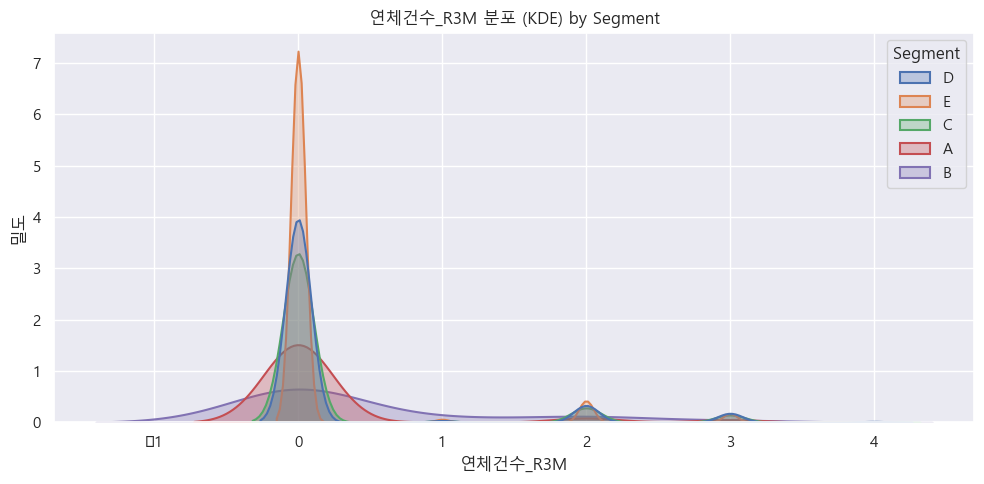

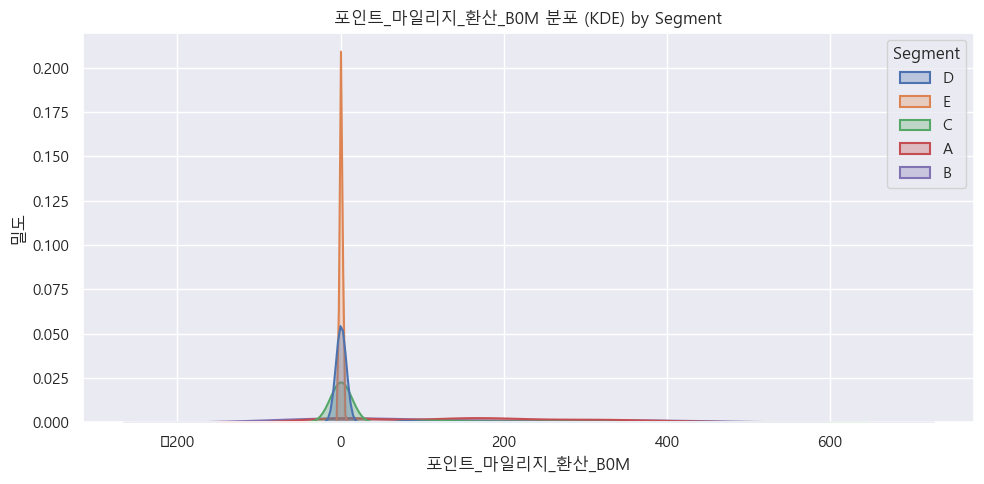

In [59]:
# 시각화할 컬럼 리스트
columns_to_plot = [
    "포인트_마일리지_건별_B0M", "포인트_마일리지_건별_R3M",
    "포인트_포인트_건별_B0M", "포인트_포인트_건별_R3M",
    "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M",
    "포인트_포인트_월적립_B0M", "포인트_포인트_월적립_R3M",
    "포인트_적립포인트_R12M", "포인트_적립포인트_R3M",
    "포인트_이용포인트_R12M", "포인트_이용포인트_R3M",
    "포인트_잔여포인트_B0M",
    "마일_적립포인트_R12M", "마일_적립포인트_R3M",
    "마일_이용포인트_R12M", "마일_이용포인트_R3M",
    "마일_잔여포인트_B0M",
    "할인건수_R3M", "할인금액_R3M", "할인건수_B0M", "할인금액_B0M",
    "할인금액_청구서_R3M", "할인금액_청구서_B0M",
    "선결제건수_R6M", "선결제건수_R3M",
    "연체건수_R6M", "연체건수_R3M",
    "포인트_마일리지_환산_B0M" 
]

for col in columns_to_plot:
    plot_segment_kde(subset, col)

In [76]:
# 수치형 변수만 추출 (문자형은 제외)
numeric_columns = [col for col in columns_to_plot if pd.api.types.is_numeric_dtype(subset[col])]

# 전체 분산 계산
subset[numeric_columns].var().sort_values(ascending=False)


포인트_이용포인트_R12M      2.739147e+09
포인트_적립포인트_R12M      1.316728e+08
포인트_이용포인트_R3M       5.257507e+07
포인트_포인트_월적립_R3M     1.732628e+07
포인트_적립포인트_R3M       1.493588e+07
마일_적립포인트_R12M       8.822836e+06
마일_이용포인트_R12M       8.583205e+06
포인트_포인트_건별_R3M      6.033791e+06
포인트_포인트_월적립_B0M     2.266736e+06
포인트_포인트_건별_B0M      6.881000e+05
마일_적립포인트_R3M        5.057010e+05
포인트_마일리지_건별_R3M     4.200200e+05
마일_이용포인트_R3M        3.782838e+05
포인트_마일리지_월적립_R3M    8.809023e+04
할인금액_청구서_R3M        6.173142e+04
포인트_마일리지_건별_B0M     4.826434e+04
할인금액_R3M            3.314141e+04
마일_잔여포인트_B0M        1.025866e+04
포인트_마일리지_월적립_B0M    9.688447e+03
할인금액_청구서_B0M        7.246904e+03
할인금액_B0M            3.828731e+03
포인트_마일리지_환산_B0M     1.566260e+03
포인트_잔여포인트_B0M       4.375220e+02
연체건수_R6M            1.391715e+00
선결제건수_R6M           1.279265e+00
연체건수_R3M            4.516341e-01
선결제건수_R3M           4.002510e-01
dtype: float64

In [78]:
# 세그먼트 기준으로 변수별 분산 비교
subset.groupby('Segment')[numeric_columns].var()


,포인트_마일리지_건별_B0M,포인트_마일리지_건별_R3M,포인트_포인트_건별_B0M,포인트_포인트_건별_R3M,포인트_마일리지_월적립_B0M,포인트_마일리지_월적립_R3M,포인트_포인트_월적립_B0M,포인트_포인트_월적립_R3M,포인트_적립포인트_R12M,포인트_적립포인트_R3M,...,마일_잔여포인트_B0M,할인금액_R3M,할인금액_B0M,할인금액_청구서_R3M,할인금액_청구서_B0M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,포인트_마일리지_환산_B0M
Segment,,,,,,,,,,,,,,,,,,,,,
A,702759.023081,6.173111e+06,2.097842e+06,1.840326e+07,169728.657772,1.569539e+06,0.000000e+00,2.398188e+06,3.786006e+08,3.019114e+07,...,174737.984664,21625.982708,2454.163178,49230.583851,6126.374243,1.941876,0.649490,1.437620,0.445211,19194.308910
B,828433.432971,7.192323e+06,2.804401e+06,2.498208e+07,97196.389493,8.477996e+05,1.004504e+06,6.509929e+07,1.228865e+09,7.917518e+07,...,91177.737319,86021.210145,9268.927536,188597.384058,21902.824275,8.389493,2.427536,2.282609,0.780797,28158.862319
C,275681.405337,2.396241e+06,1.629098e+06,1.439717e+07,51381.356985,4.634746e+05,9.356302e+06,7.196617e+07,4.072942e+08,3.515207e+07,...,51536.656942,81258.264628,9380.235451,155756.705767,18470.848356,2.951192,0.911594,1.898952,0.609071,9537.700971
D,108347.608152,9.492807e+05,1.312305e+06,1.151450e+07,19969.259319,1.830385e+05,6.577838e+06,5.129308e+07,3.094685e+08,3.075425e+07,...,21040.210717,66694.043102,7718.569718,125184.633037,14799.167498,2.510810,0.777423,1.946173,0.628575,3326.623056
E,19007.383132,1.641852e+05,4.923457e+05,4.307198e+06,4563.119496,4.140167e+04,9.774686e+05,7.153743e+06,7.574662e+07,1.008118e+07,...,5014.720109,22292.335246,2575.521394,40520.993325,4727.305105,0.901244,0.285664,1.249991,0.407101,542.948179


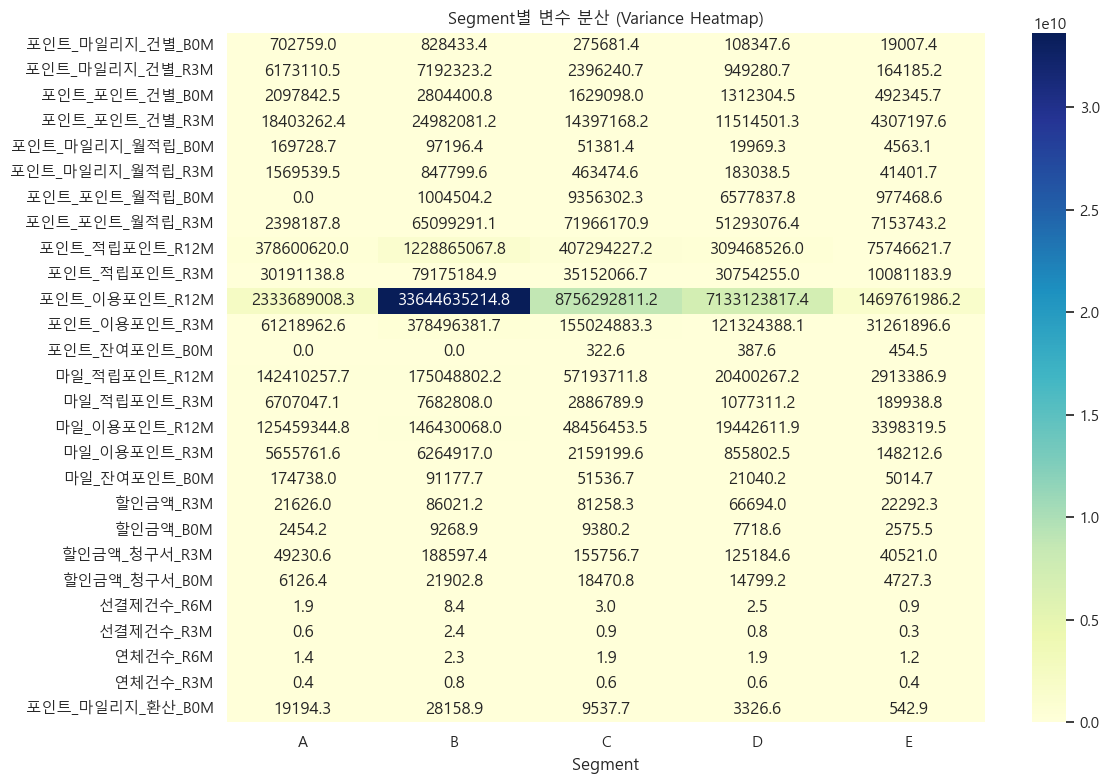

In [80]:
# 세그먼트별 변수 분산 테이블
var_table = subset.groupby('Segment')[numeric_columns].var().T

# 분산 히트맵
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(var_table, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Segment별 변수 분산 (Variance Heatmap)")
plt.tight_layout()
plt.show()


In [86]:
# 세그먼트 간 분산 차이가 큰 변수 (최대-최소 분산 차 기준)
diff_vars = (var_table.max(axis=1) - var_table.min(axis=1)).sort_values(ascending=False).head(10)
print(diff_vars)


포인트_이용포인트_R12M     3.217487e+10
포인트_적립포인트_R12M     1.153118e+09
포인트_이용포인트_R3M      3.472345e+08
마일_적립포인트_R12M      1.721354e+08
마일_이용포인트_R12M      1.430317e+08
포인트_포인트_월적립_R3M    6.956798e+07
포인트_적립포인트_R3M      6.909400e+07
포인트_포인트_건별_R3M     2.067488e+07
포인트_포인트_월적립_B0M    9.356302e+06
마일_적립포인트_R3M       7.492869e+06
dtype: float64


In [11]:
def plot_segment_scatter_strip(subset, value_col):
    try:
        if not pd.api.types.is_numeric_dtype(subset[value_col]):
            print(f"⚠️ 컬럼 '{value_col}'은 수치형이 아니므로 스킵합니다.")
            return

        plt.figure(figsize=(8, 5))
        sns.stripplot(
            data=subset,
            x="Segment",
            y=value_col,
            jitter=True,        # 퍼뜨려서 겹침 방지
            alpha=0.5,
            size=5              # 점 크기
        )
        plt.title(f"Segment별 {value_col} 산점도")
        plt.xlabel("Segment")
        plt.ylabel(value_col)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❗ 시각화 오류 ({value_col}): {e}")


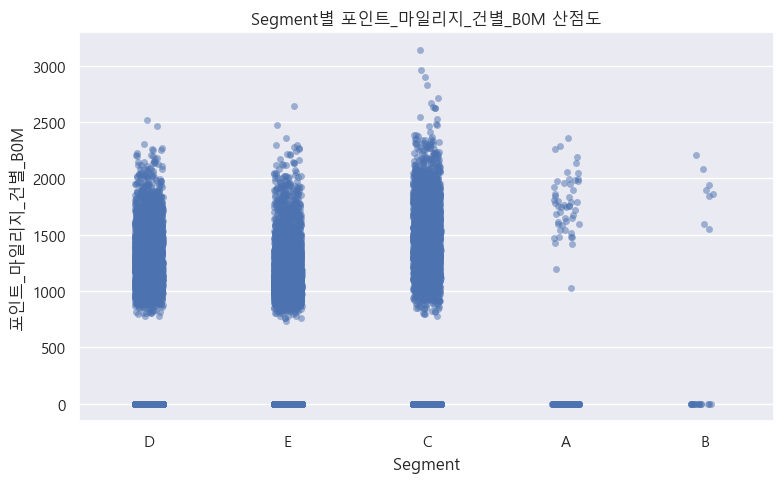

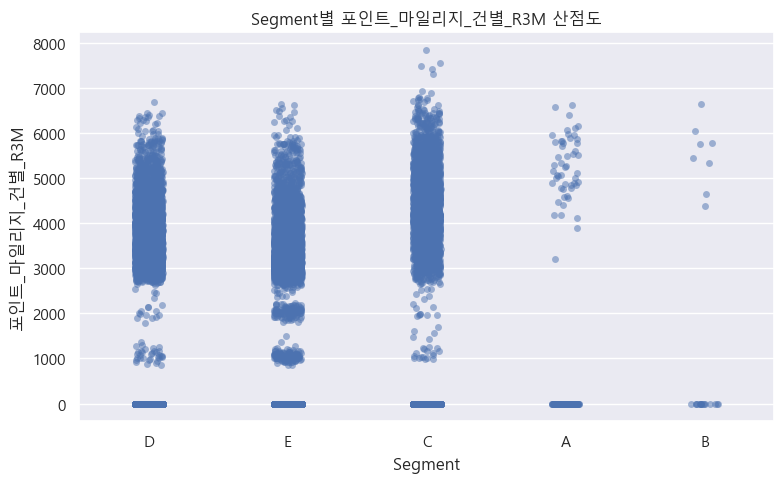

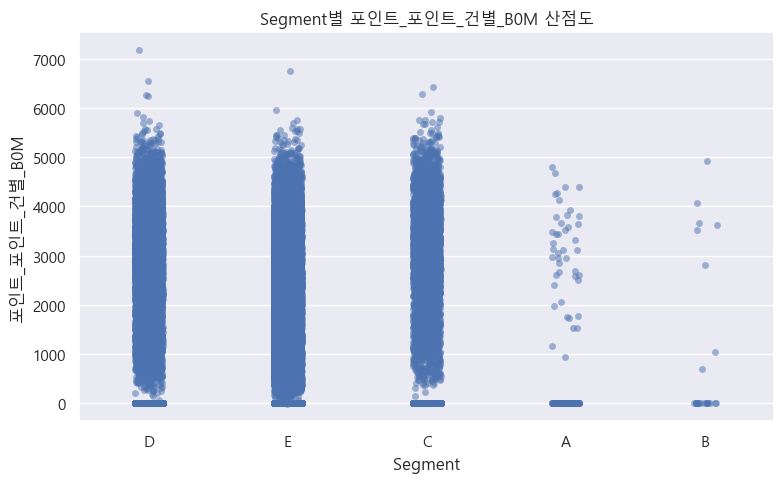

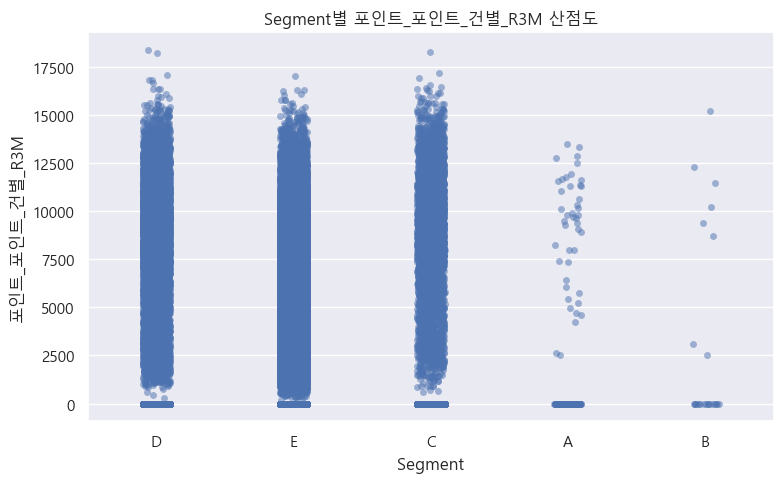

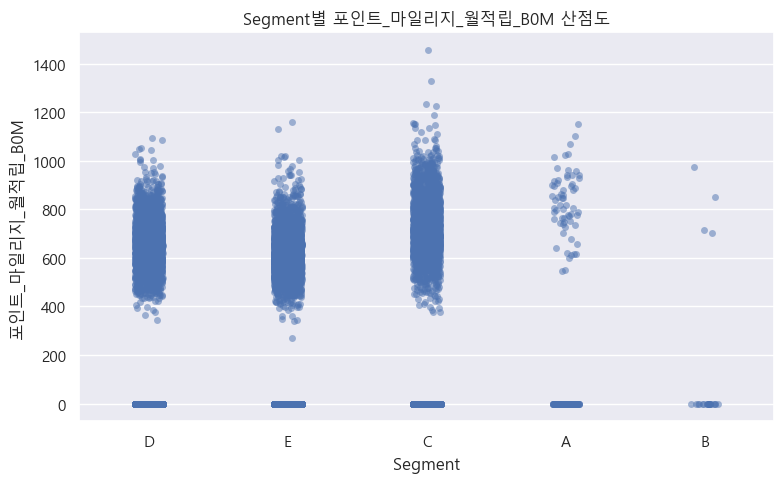

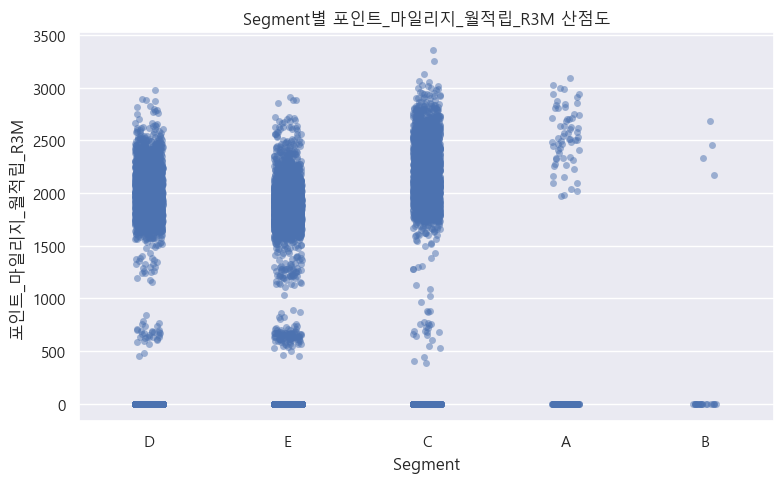

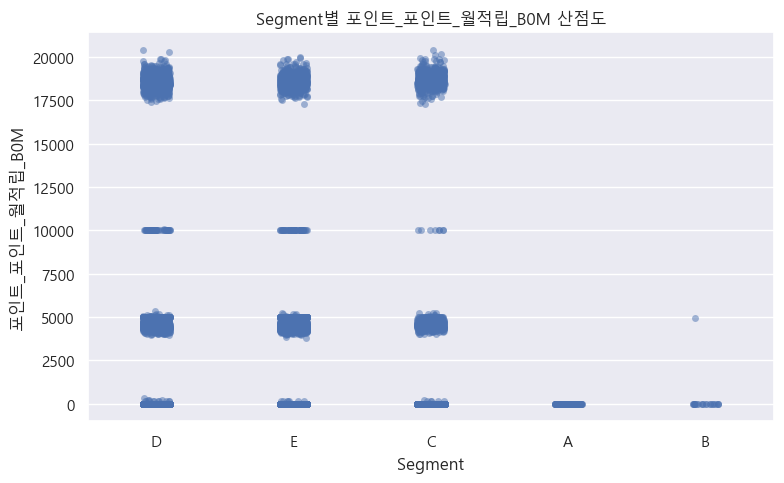

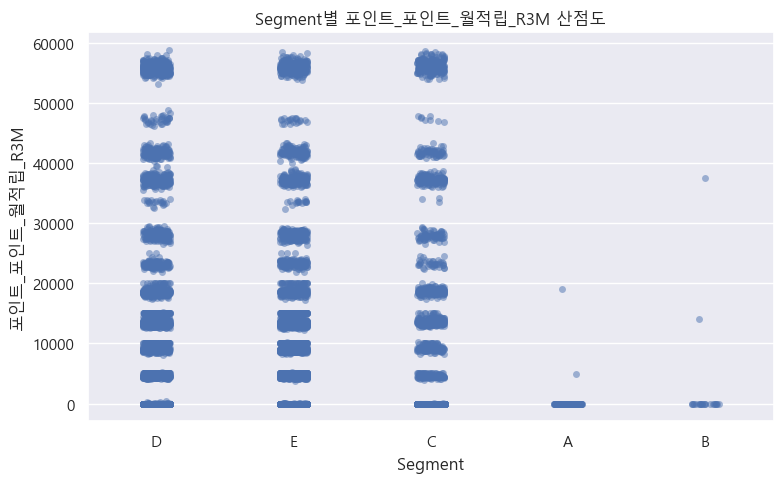

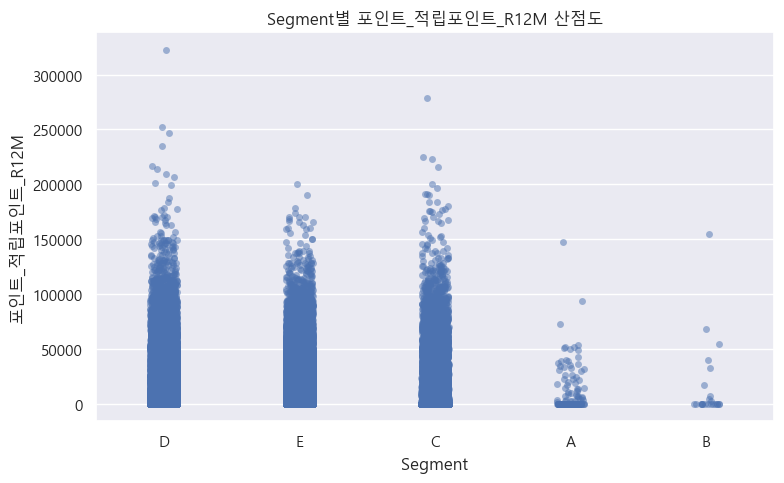

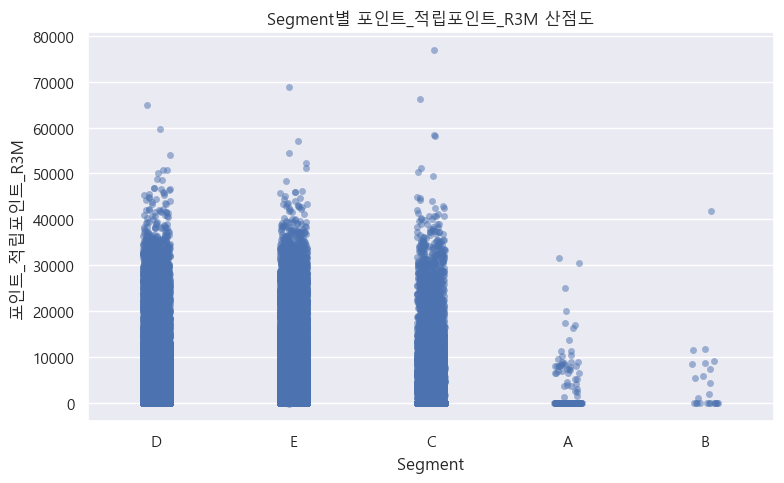

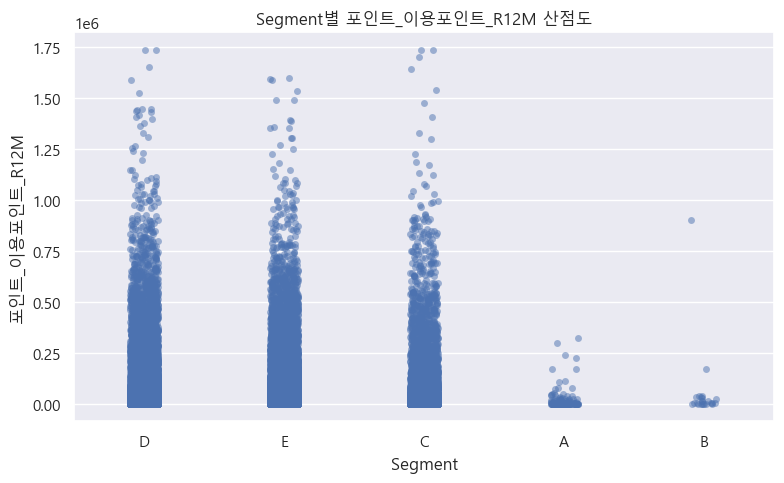

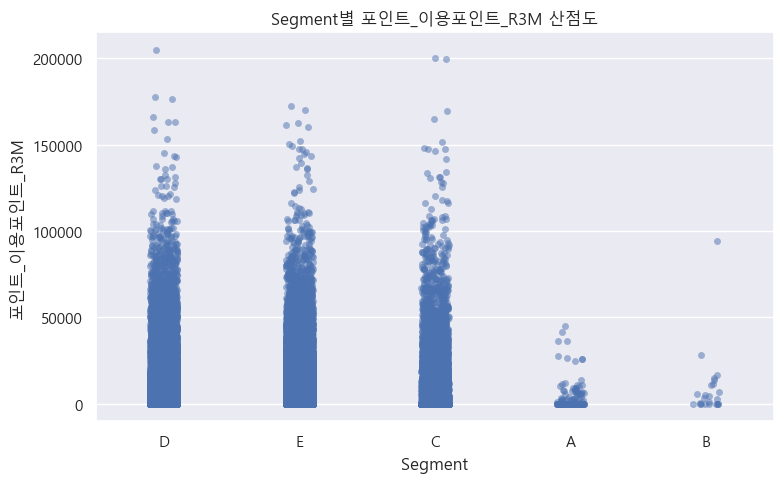

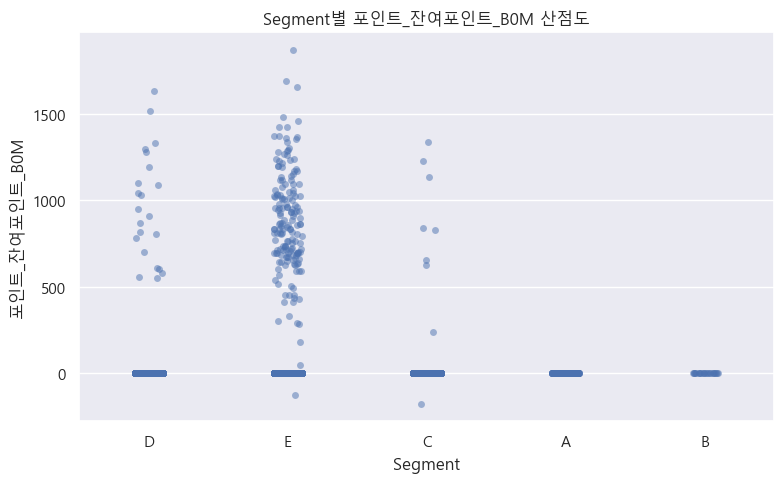

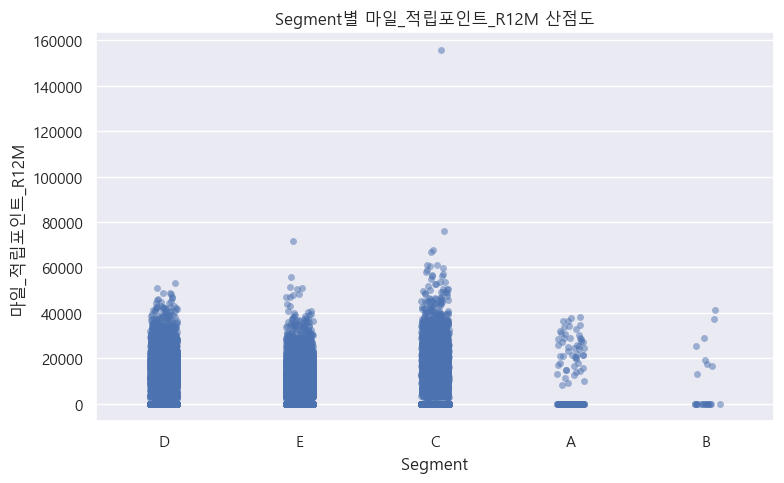

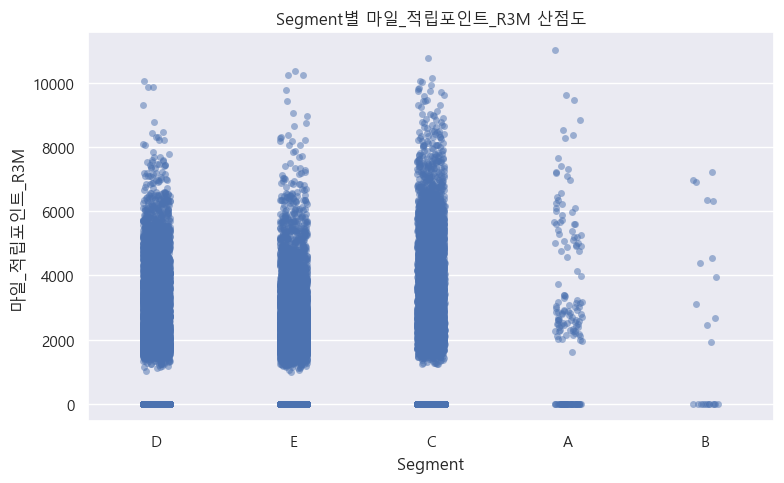

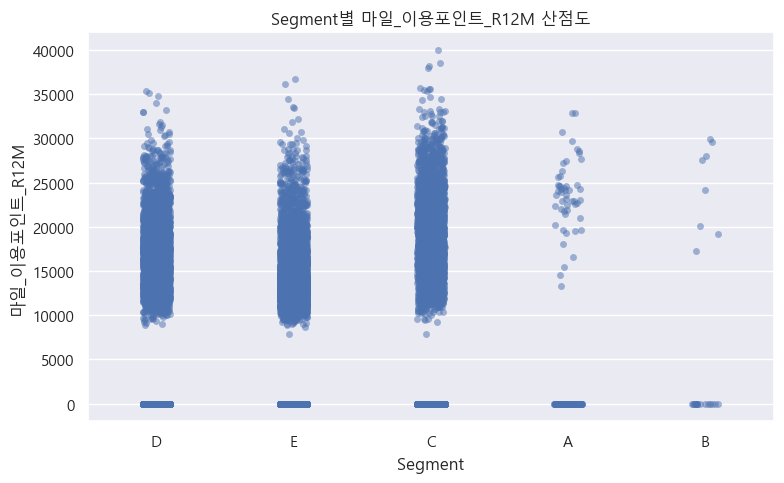

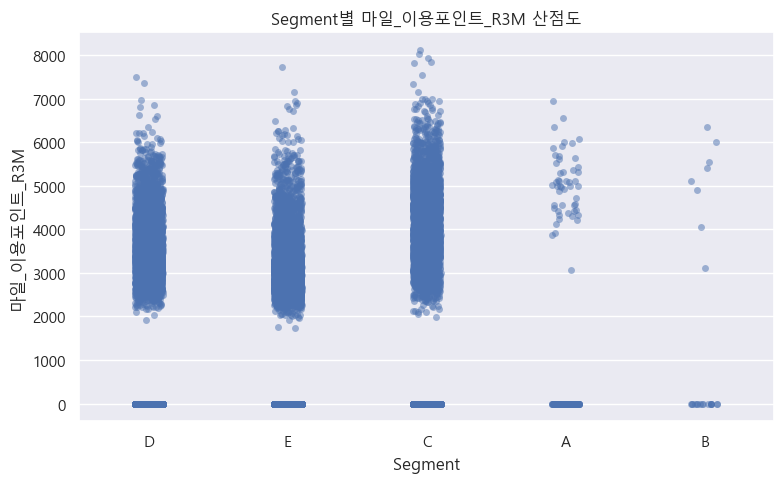

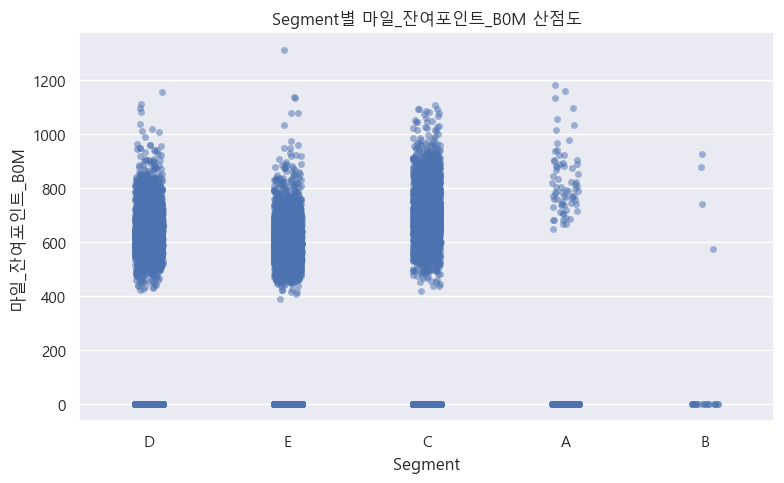

⚠️ 컬럼 '할인건수_R3M'은 수치형이 아니므로 스킵합니다.


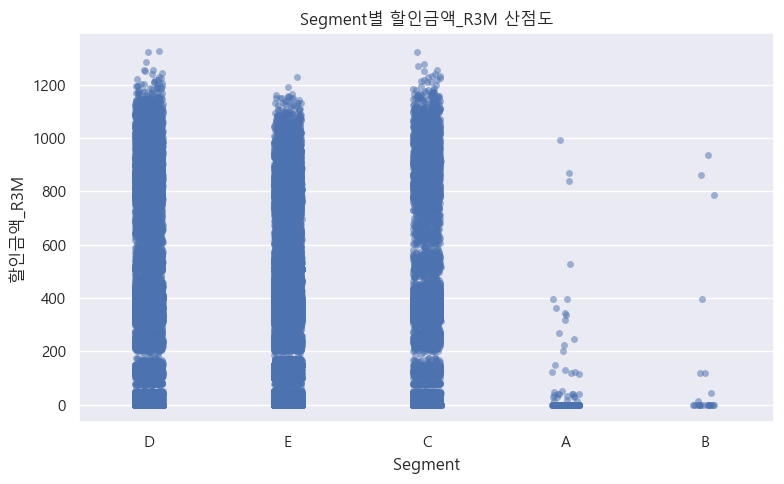

⚠️ 컬럼 '할인건수_B0M'은 수치형이 아니므로 스킵합니다.


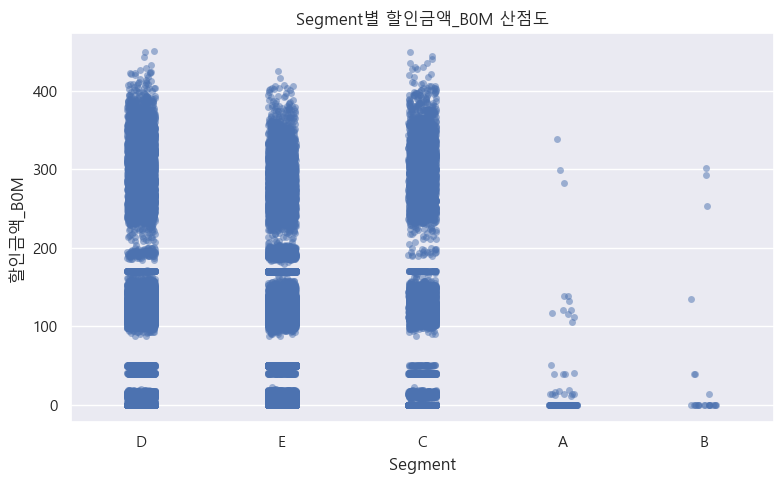

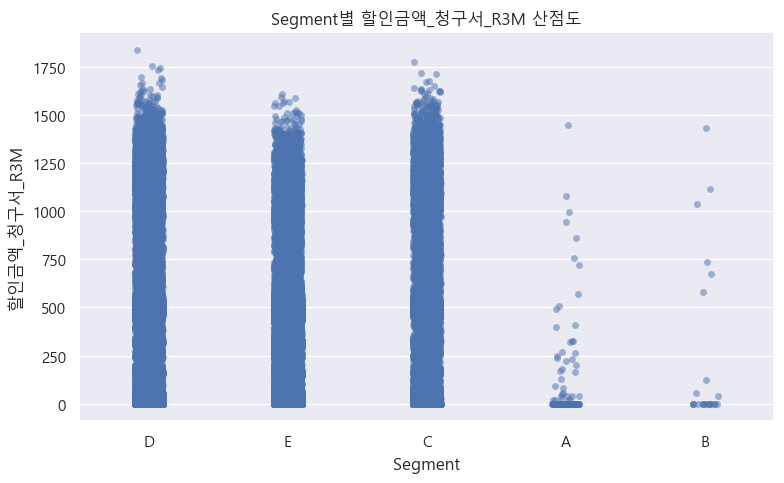

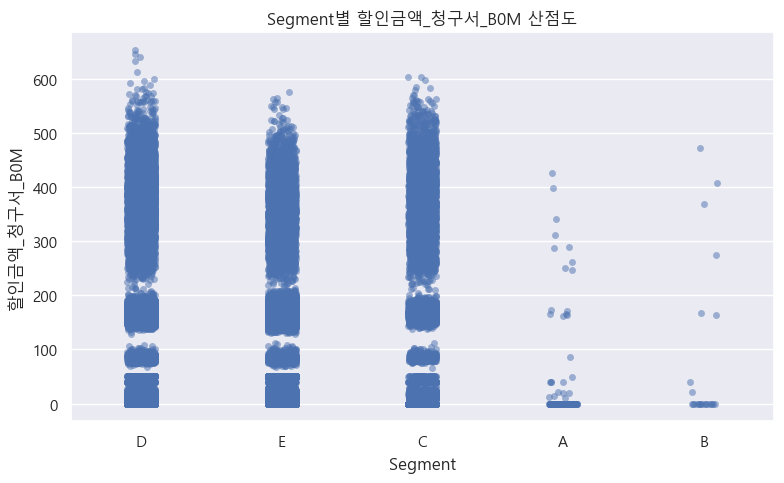

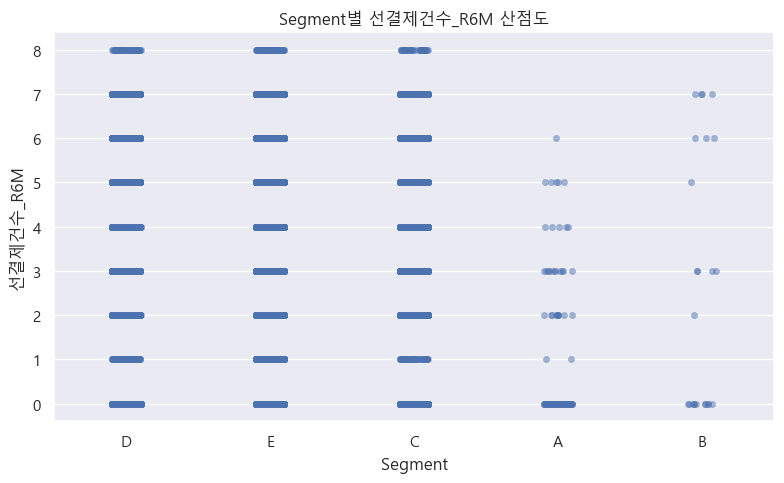

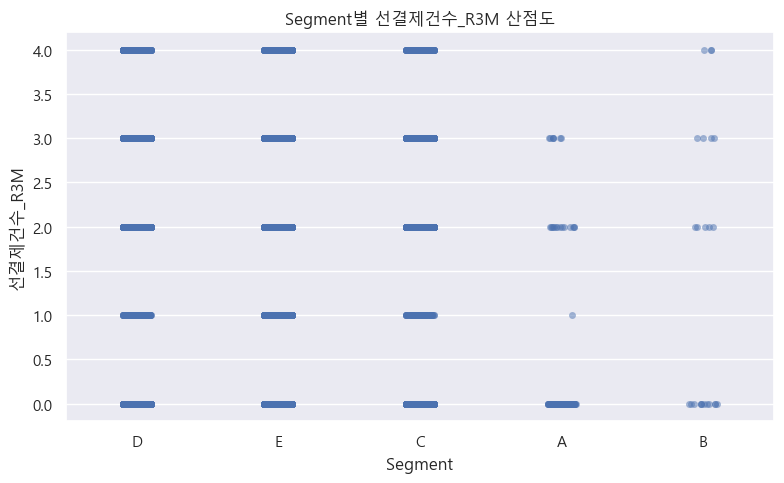

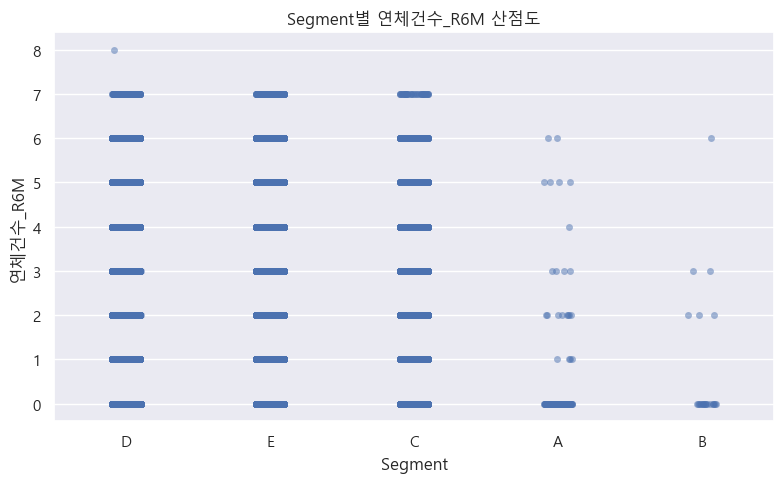

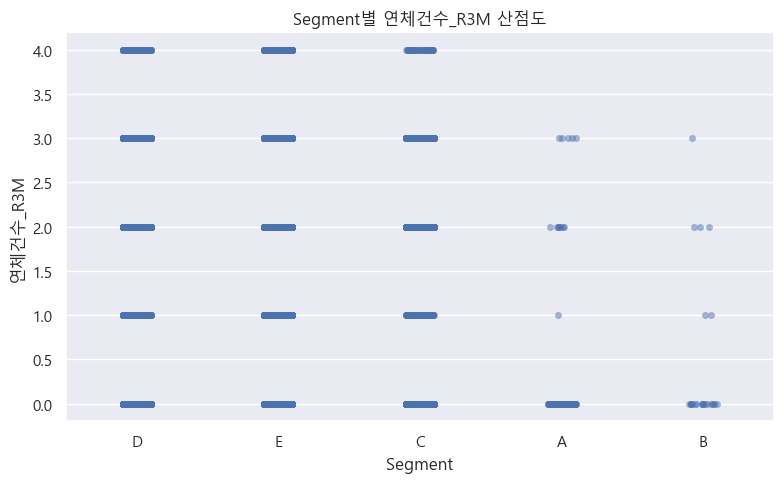

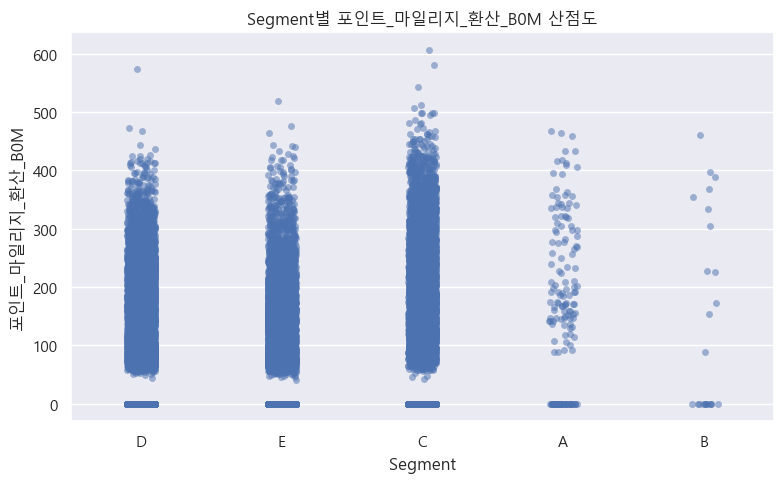

In [13]:
columns_to_plot = [
    "포인트_마일리지_건별_B0M", "포인트_마일리지_건별_R3M",
    "포인트_포인트_건별_B0M", "포인트_포인트_건별_R3M",
    "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M",
    "포인트_포인트_월적립_B0M", "포인트_포인트_월적립_R3M",
    "포인트_적립포인트_R12M", "포인트_적립포인트_R3M",
    "포인트_이용포인트_R12M", "포인트_이용포인트_R3M",
    "포인트_잔여포인트_B0M",
    "마일_적립포인트_R12M", "마일_적립포인트_R3M",
    "마일_이용포인트_R12M", "마일_이용포인트_R3M",
    "마일_잔여포인트_B0M",
    "할인건수_R3M", "할인금액_R3M", "할인건수_B0M", "할인금액_B0M",
    "할인금액_청구서_R3M", "할인금액_청구서_B0M",
    "선결제건수_R6M", "선결제건수_R3M",
    "연체건수_R6M", "연체건수_R3M",
    "포인트_마일리지_환산_B0M" 
]

for col in columns_to_plot:
    plot_segment_scatter_strip(subset, col)


In [19]:
from sklearn.preprocessing import LabelEncoder

# Segment를 숫자로 변환
subset = subset.copy()  # 원본 보호
le = LabelEncoder()
subset["Segment_encoded"] = le.fit_transform(subset["Segment"])


In [21]:
import matplotlib.pyplot as plt

def plot_encoded_segment_scatter(df, value_col):
    try:
        if not pd.api.types.is_numeric_dtype(df[value_col]):
            print(f"⚠️ {value_col}은 수치형이 아니므로 스킵합니다.")
            return

        plt.figure(figsize=(8, 5))
        plt.scatter(df["Segment_encoded"], df[value_col], alpha=0.6, s=40)
        plt.xlabel("Segment (Encoded)")
        plt.ylabel(value_col)
        plt.title(f"Encoded Segment vs {value_col}")
        plt.xticks(
            ticks=range(len(le.classes_)),
            labels=le.classes_  # 인코딩된 숫자를 다시 범주형처럼 보이게
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"❗ 산점도 오류: {e}")


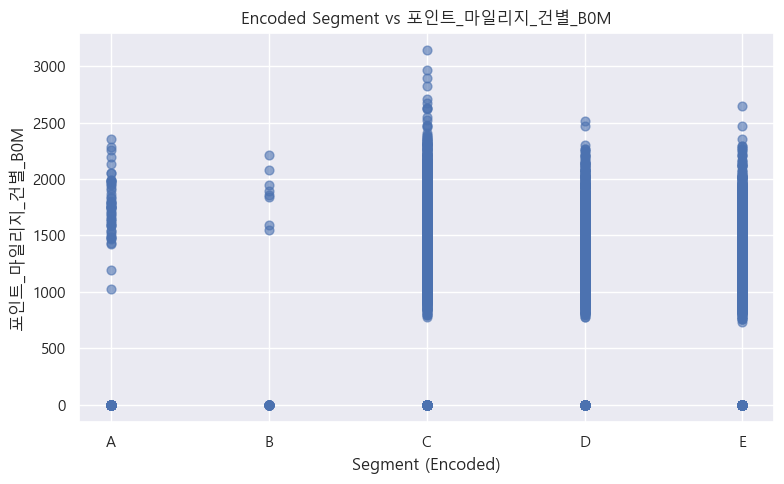

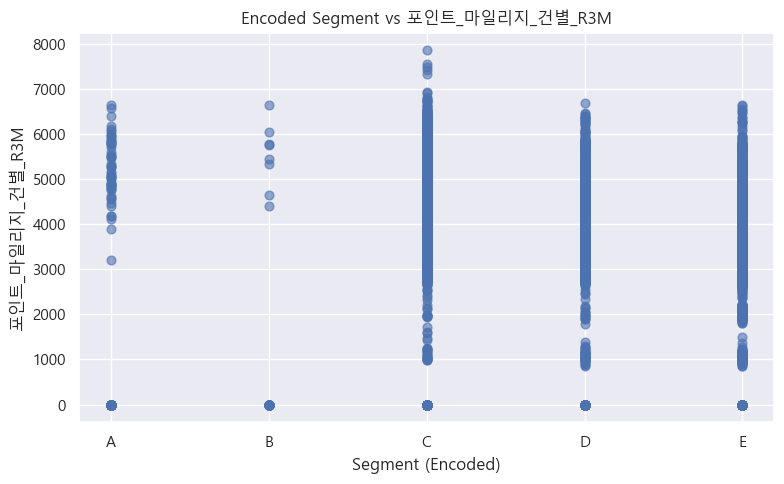

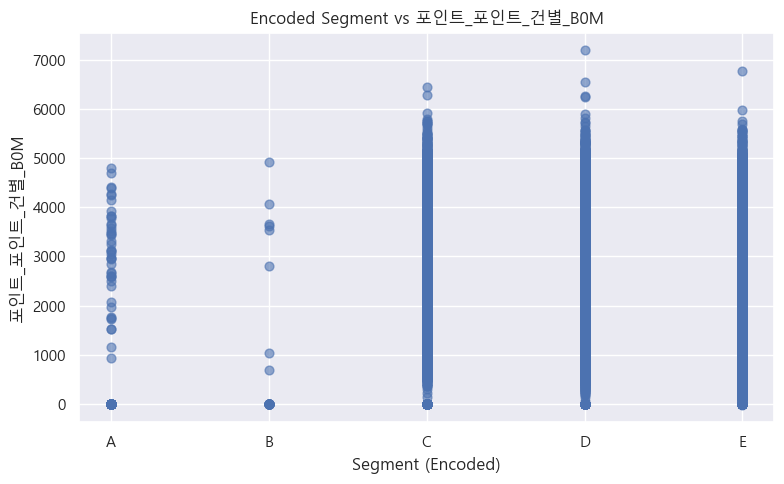

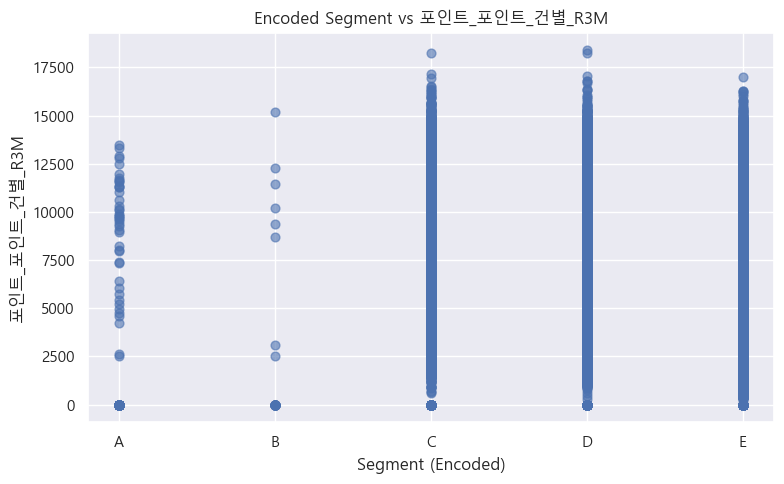

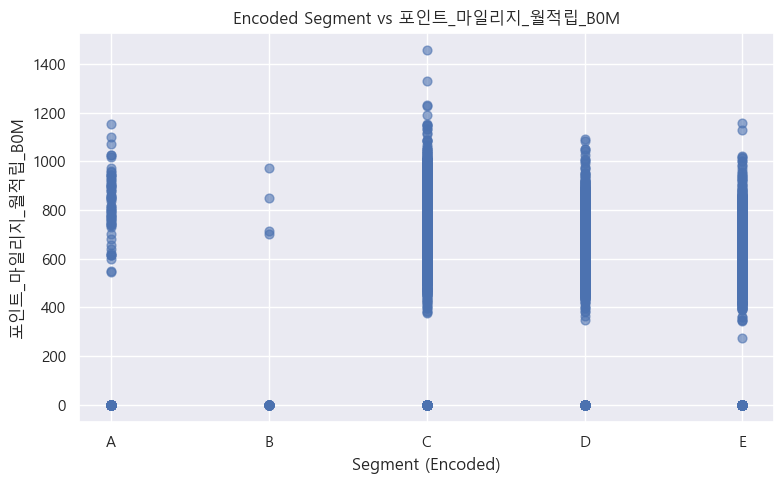

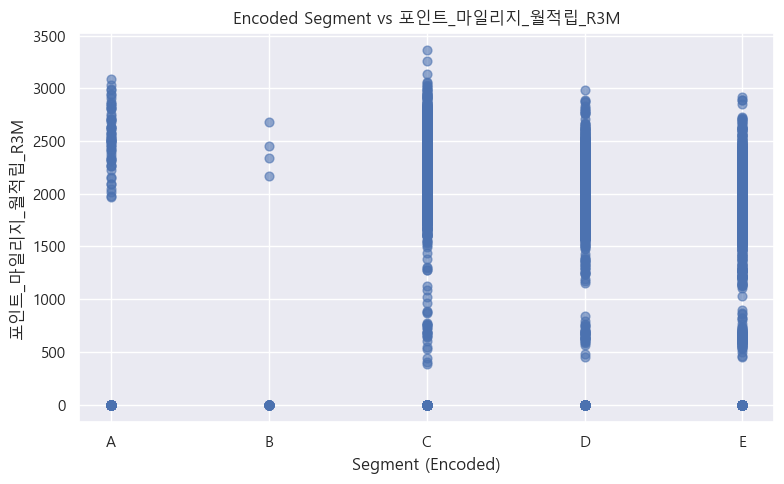

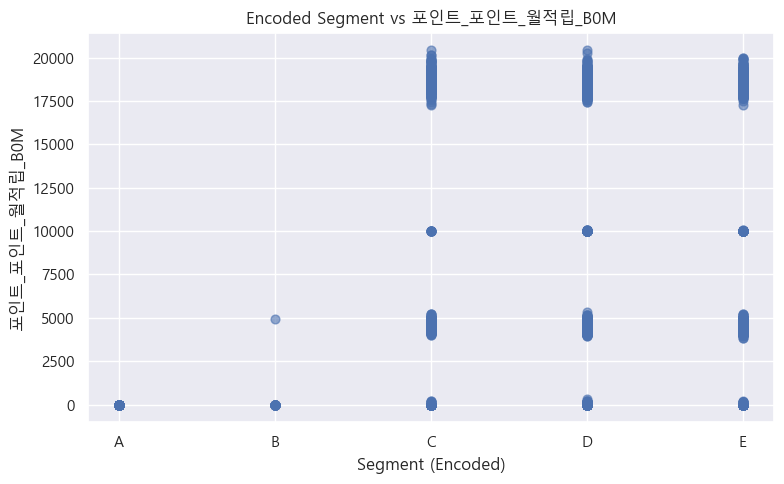

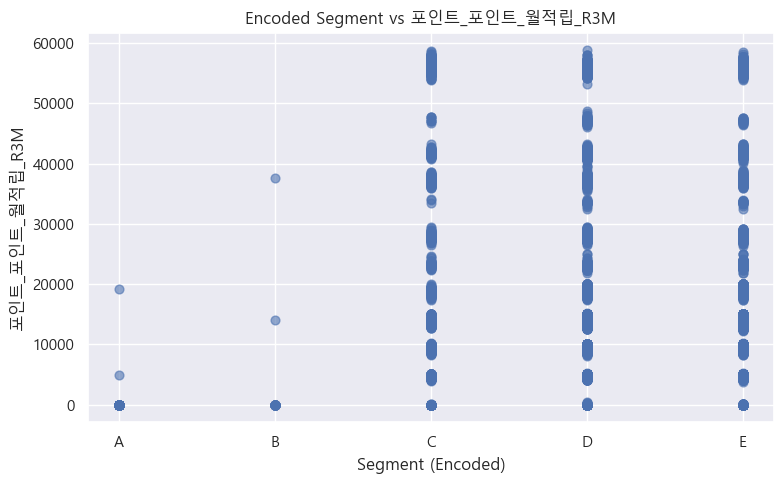

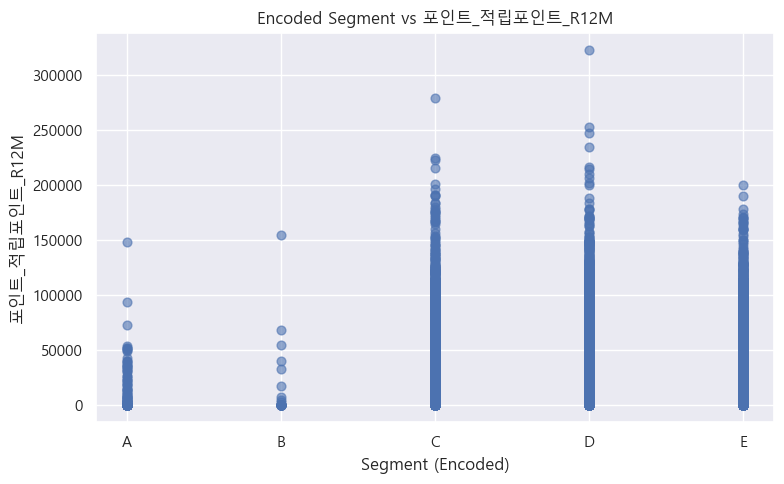

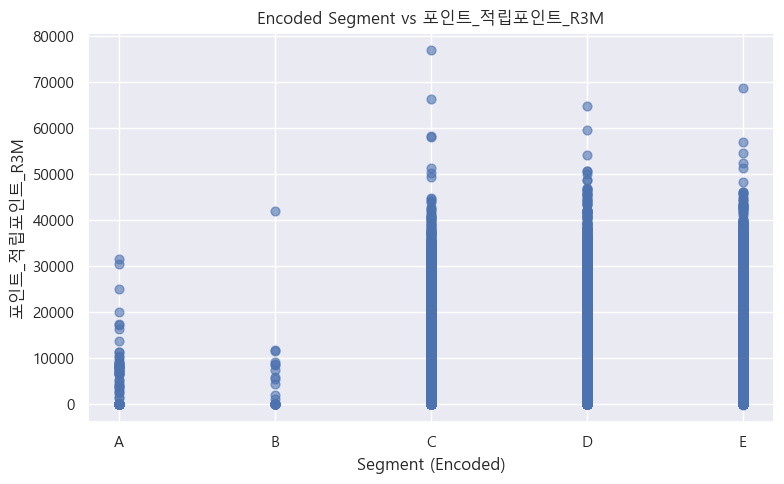

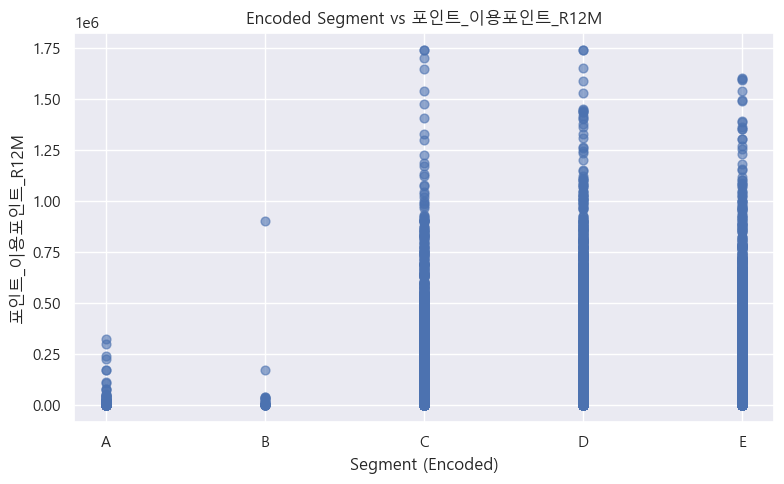

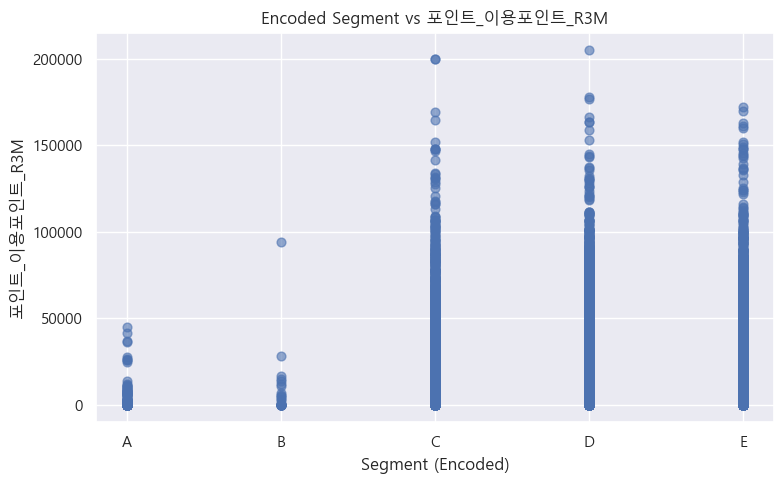

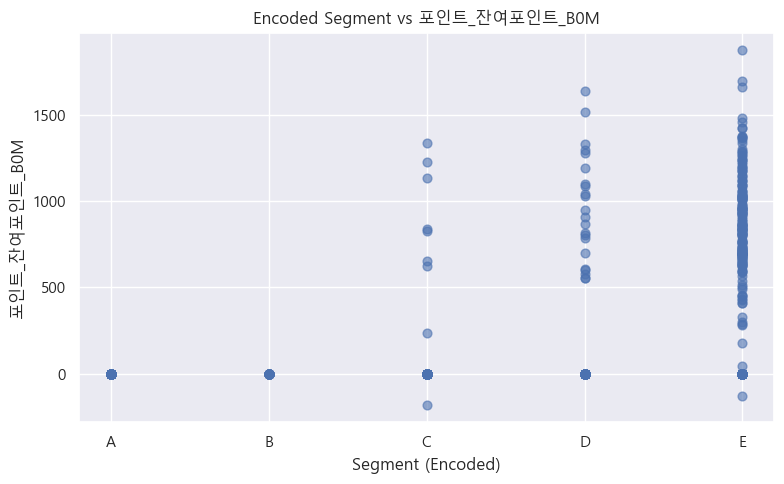

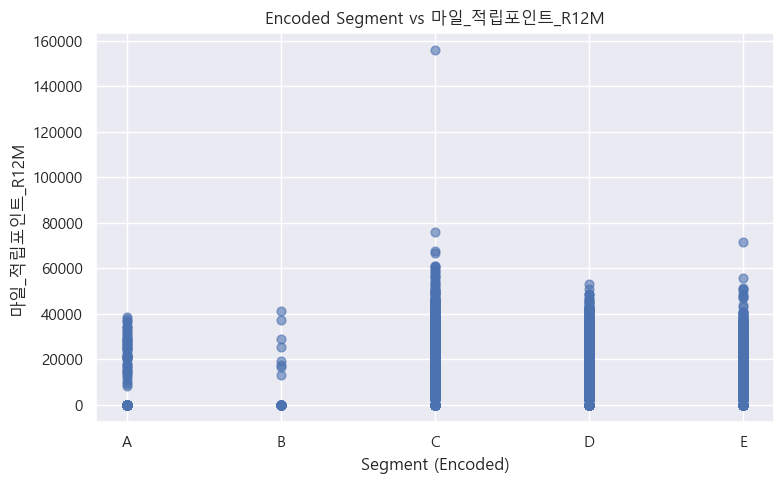

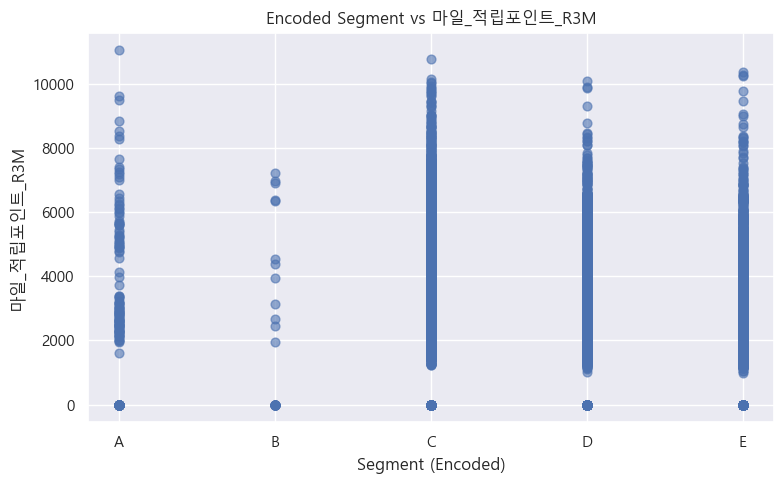

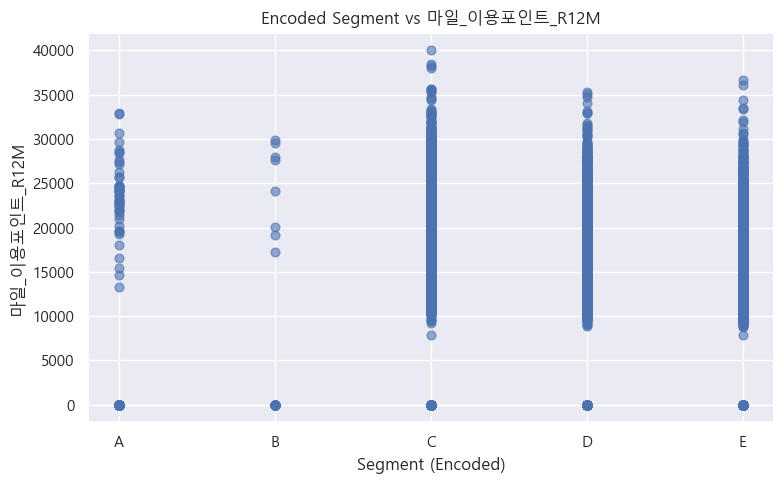

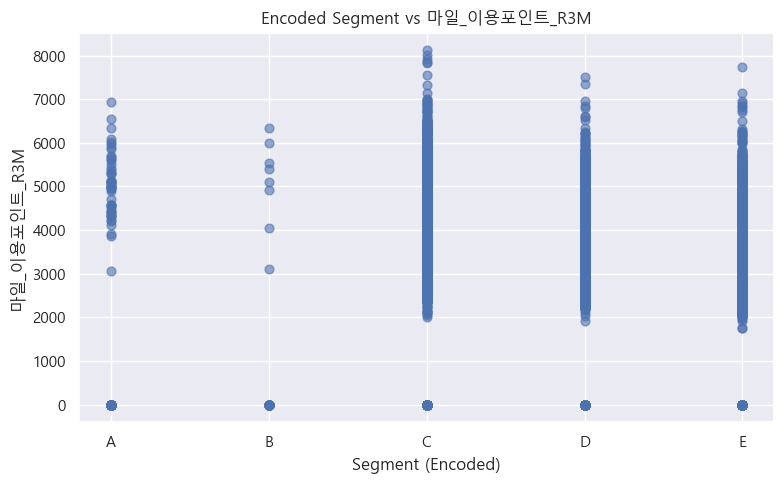

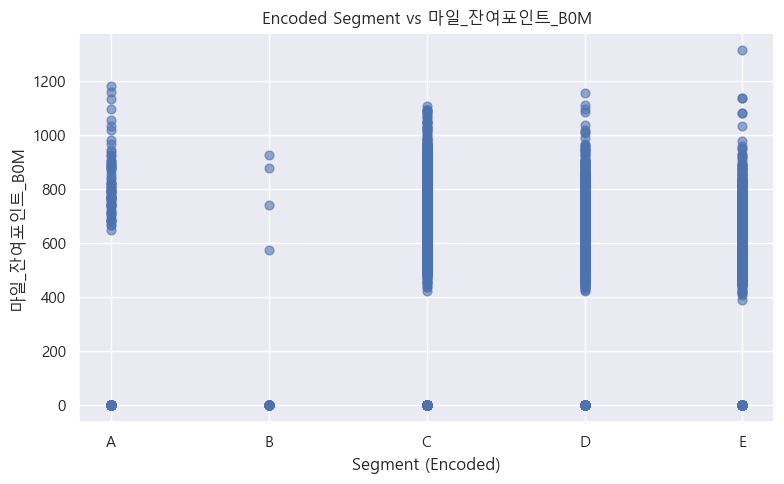

⚠️ 할인건수_R3M은 수치형이 아니므로 스킵합니다.


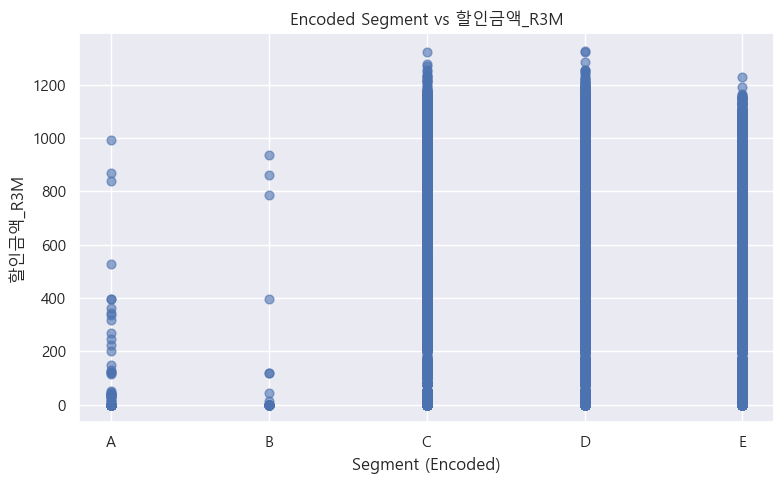

⚠️ 할인건수_B0M은 수치형이 아니므로 스킵합니다.


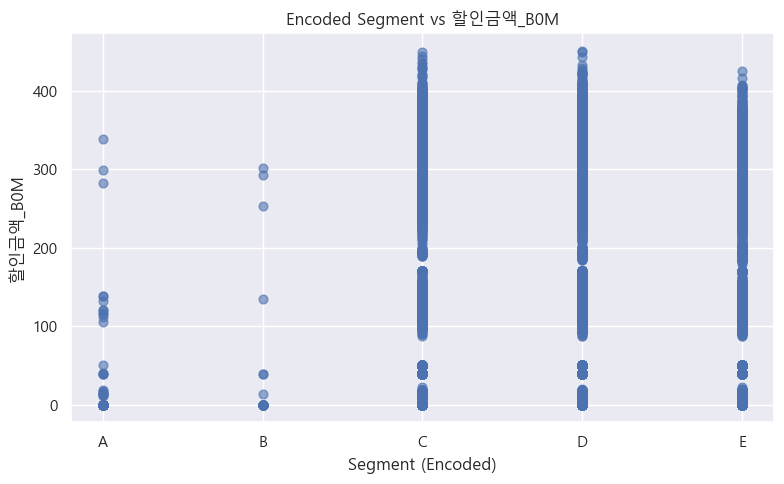

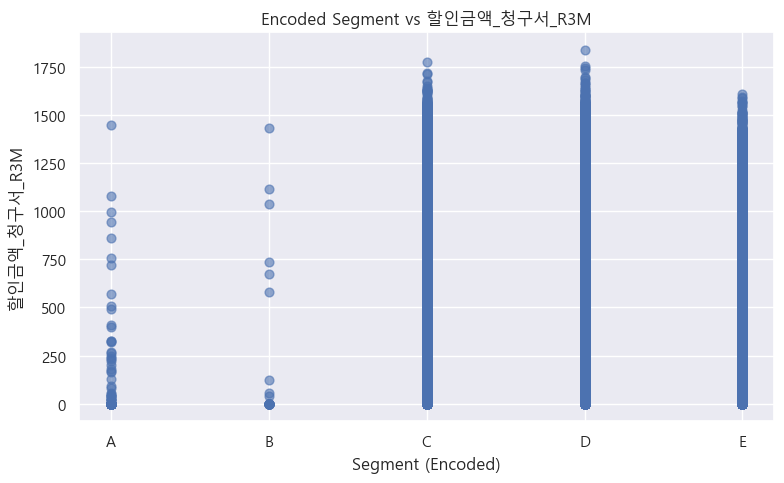

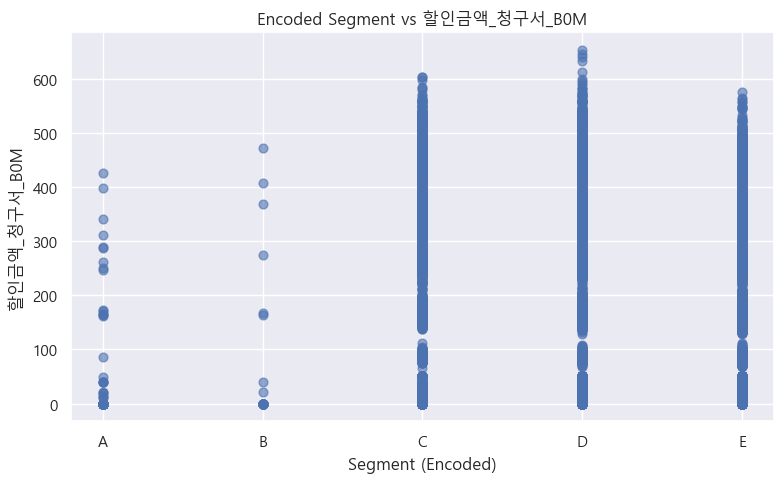

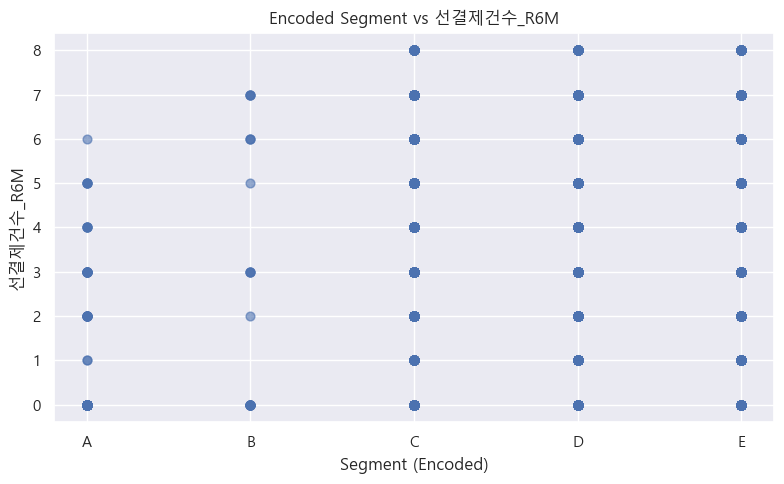

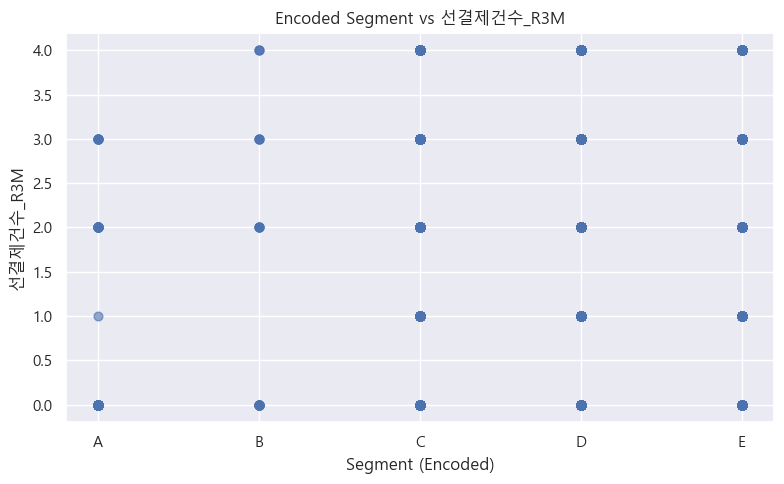

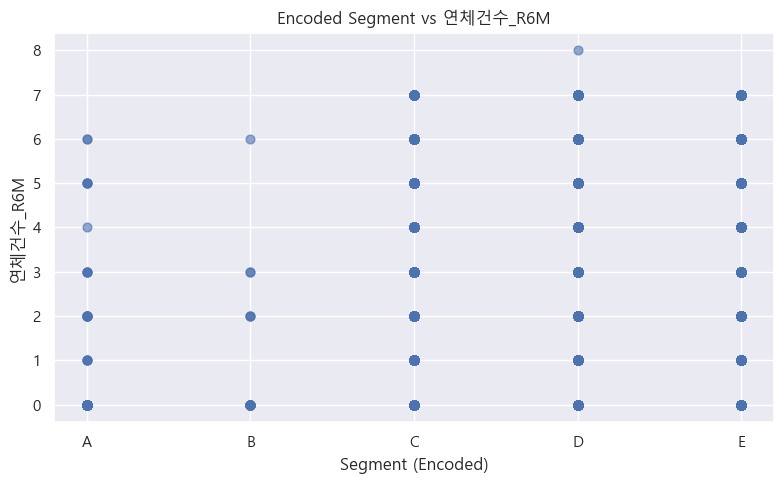

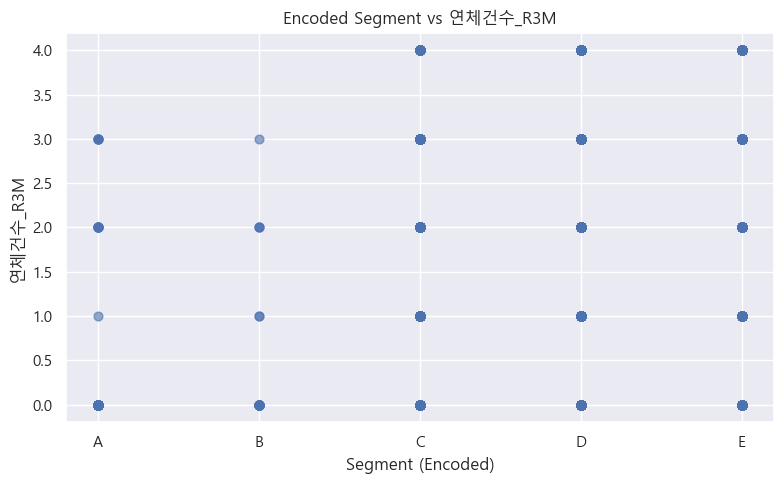

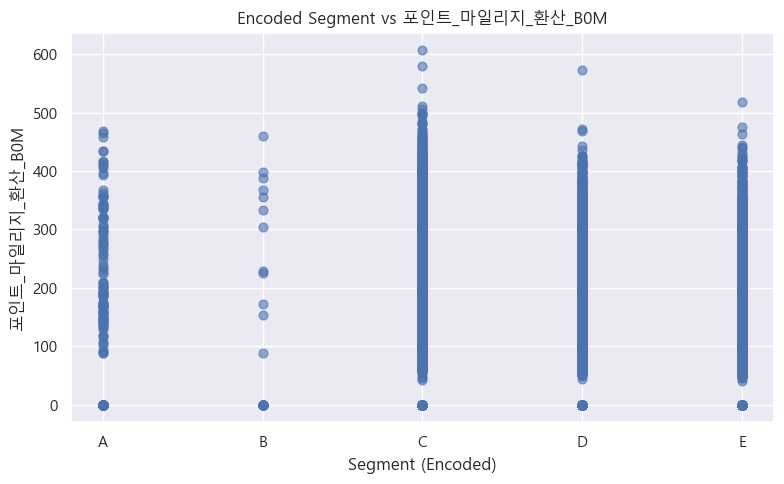

In [23]:
for col in columns_to_plot:
    plot_encoded_segment_scatter(subset, col)


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_segment_scatter_grid(df, columns, row_var="Segment", max_cols=4):
    cols_per_plot = max_cols
    num_chunks = len(columns) // cols_per_plot + int(len(columns) % cols_per_plot > 0)

    for i in range(num_chunks):
        cols_chunk = columns[i * cols_per_plot: (i + 1) * cols_per_plot]
        melted = df.melt(id_vars=row_var, value_vars=cols_chunk, var_name="Variable", value_name="Value")

        g = sns.FacetGrid(melted, col="Variable", col_wrap=cols_per_plot, sharex=False, height=4)
        g.map_dataframe(sns.stripplot, y=row_var, x="Value", alpha=0.5, jitter=True, size=3)
        g.set_titles("{col_name}")
        g.set_axis_labels("Value", row_var)
        plt.tight_layout()
        plt.show()


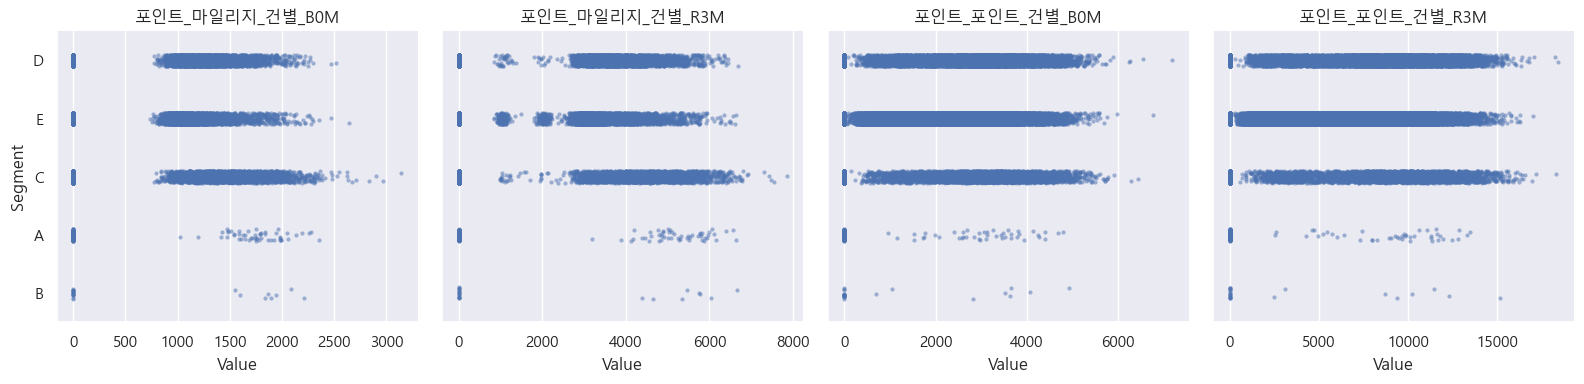

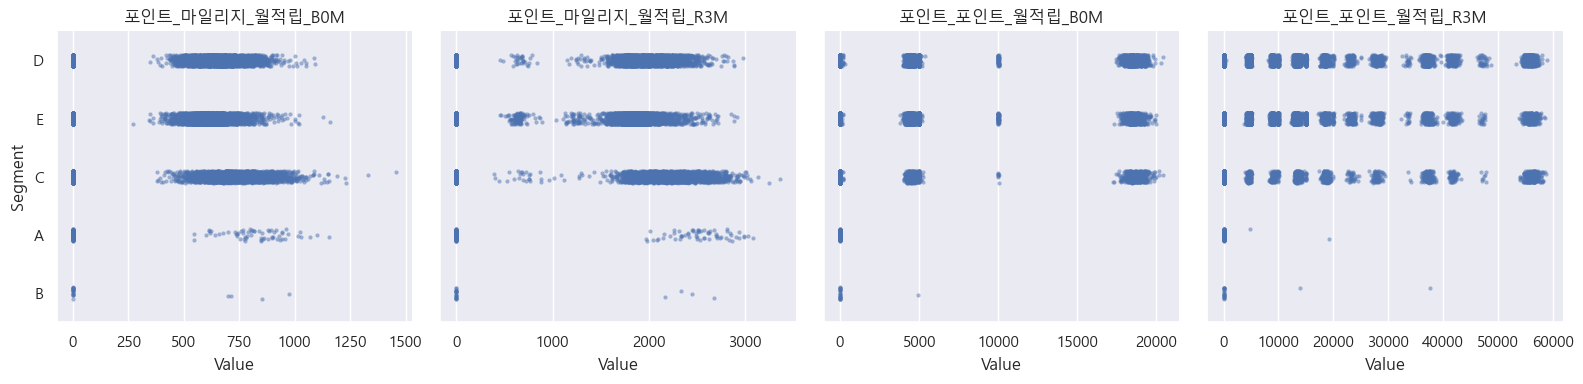

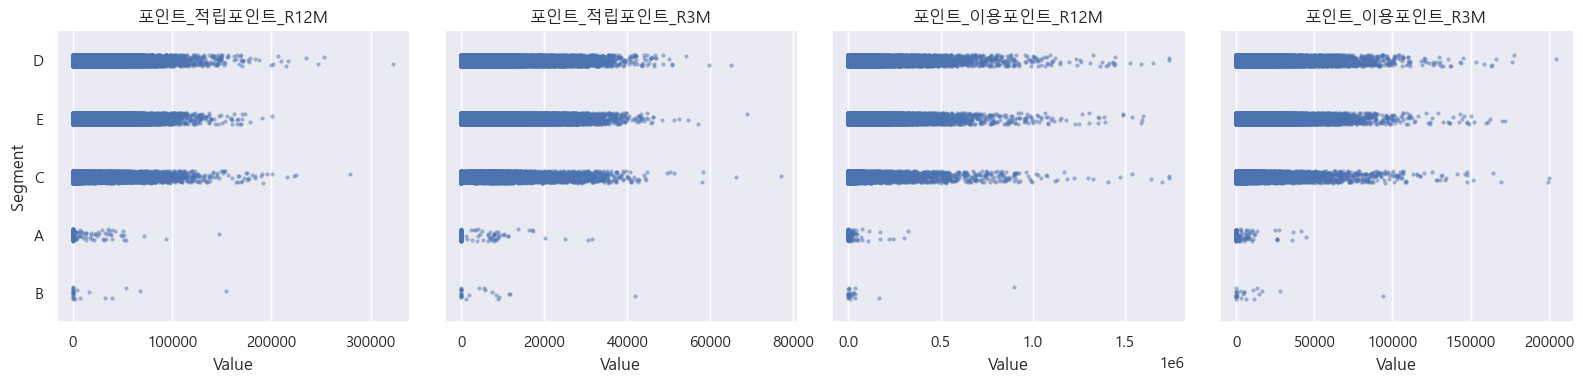

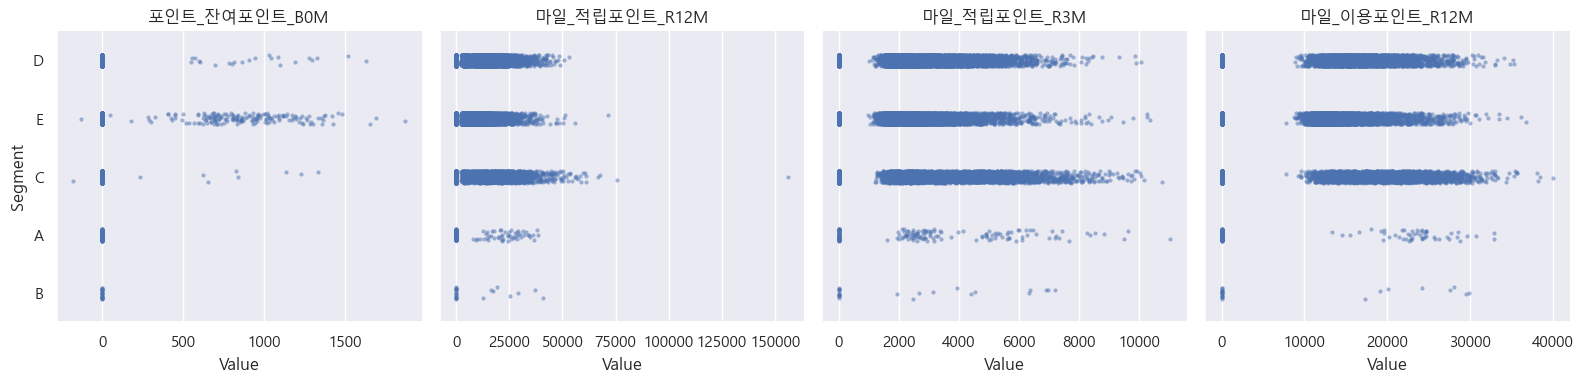

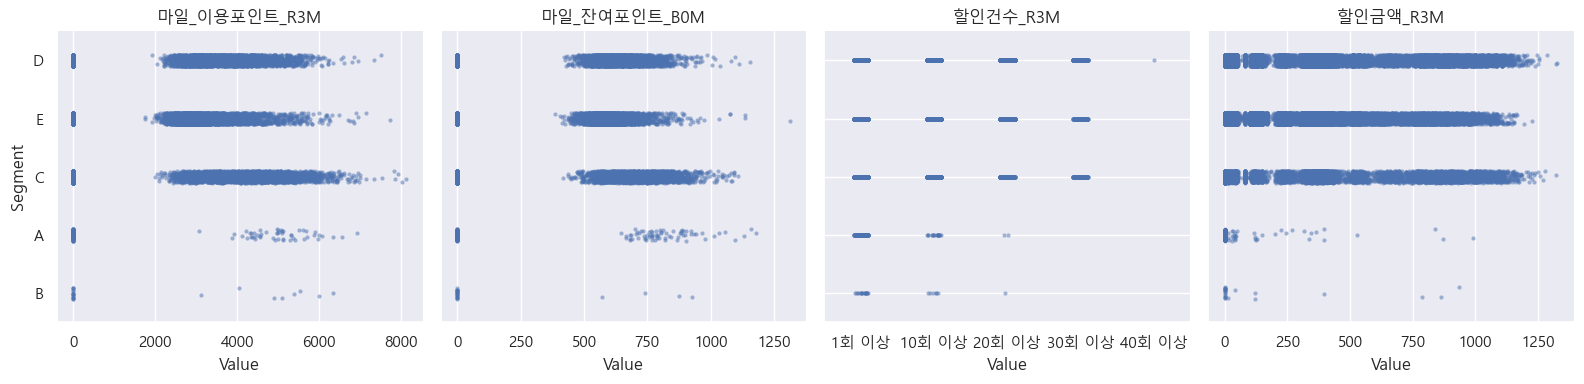

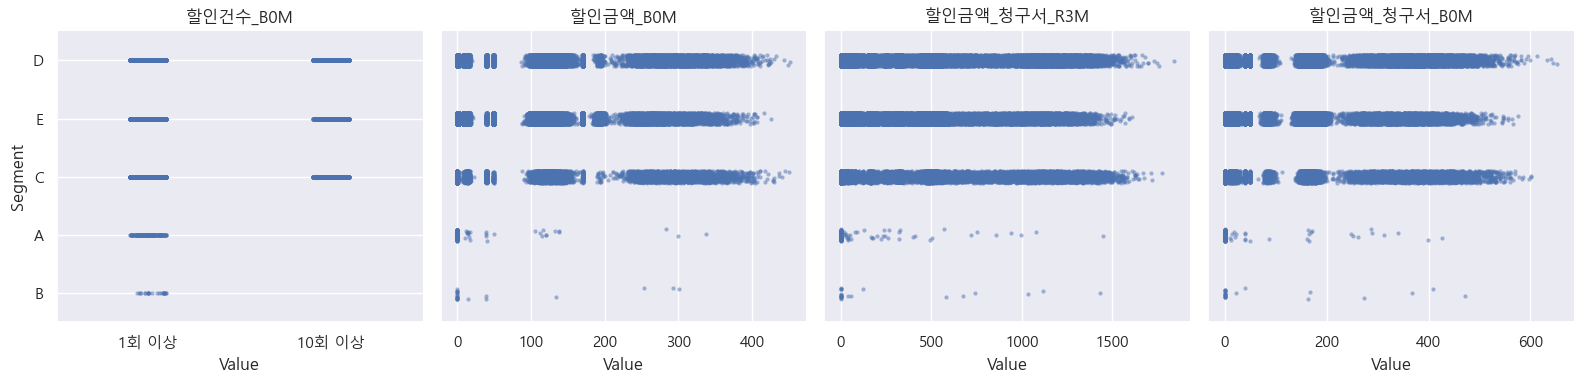

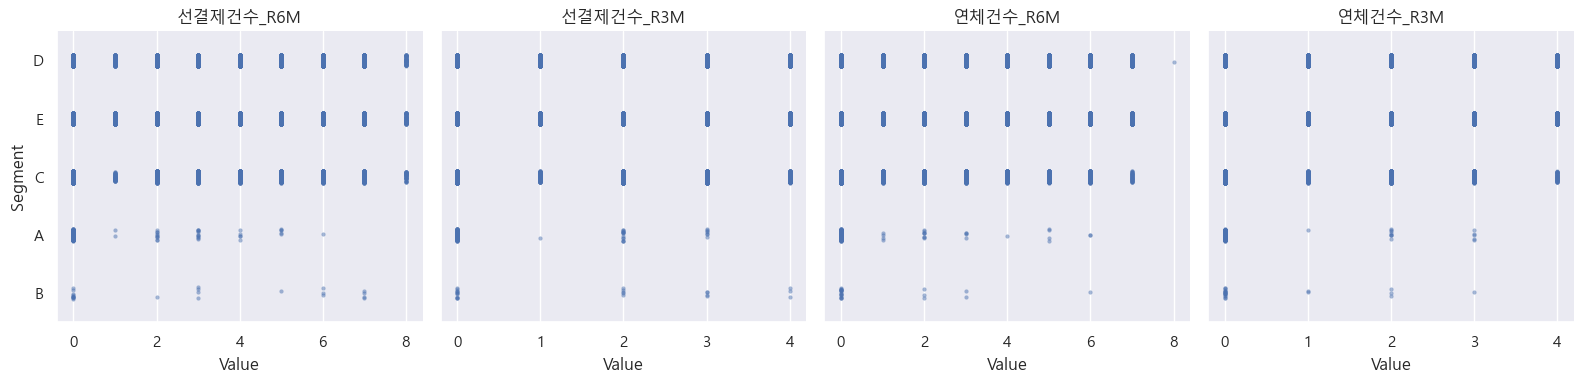

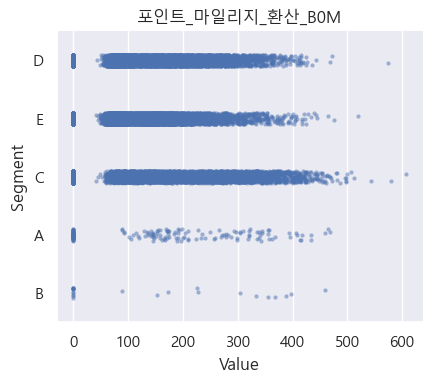

In [20]:
columns_to_plot = [
    "포인트_마일리지_건별_B0M", "포인트_마일리지_건별_R3M",
    "포인트_포인트_건별_B0M", "포인트_포인트_건별_R3M",
    "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M",
    "포인트_포인트_월적립_B0M", "포인트_포인트_월적립_R3M",
    "포인트_적립포인트_R12M", "포인트_적립포인트_R3M",
    "포인트_이용포인트_R12M", "포인트_이용포인트_R3M",
    "포인트_잔여포인트_B0M",
    "마일_적립포인트_R12M", "마일_적립포인트_R3M",
    "마일_이용포인트_R12M", "마일_이용포인트_R3M",
    "마일_잔여포인트_B0M",
    "할인건수_R3M", "할인금액_R3M", "할인건수_B0M", "할인금액_B0M",
    "할인금액_청구서_R3M", "할인금액_청구서_B0M",
    "선결제건수_R6M", "선결제건수_R3M",
    "연체건수_R6M", "연체건수_R3M",
    "포인트_마일리지_환산_B0M" 
]

plot_segment_scatter_grid(subset, columns_to_plot, max_cols=4)

In [48]:
columns_p = [
    "선결제건수_R6M", "선결제건수_R3M",
    "포인트_마일리지_환산_B0M", "마일_적립포인트_R3M", "마일_잔여포인트_B0M", "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M"
]

In [50]:
def calculate_cv(series):
    mean = series.mean()
    std = series.std()
    if mean == 0:
        return float('nan')  # 평균이 0이면 계산 불가
    return std / mean


In [52]:
def calculate_cv_by_segment(df, columns, segment_col="Segment"):
    cv_table = {}

    for col in columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            grouped = df.groupby(segment_col)[col].apply(calculate_cv)
            cv_table[col] = grouped

    return pd.DataFrame(cv_table).T  # 행: 변수, 열: 세그먼트별 CV


In [54]:
cv_df = calculate_cv_by_segment(subset, columns_p)
cv_df

Segment,A,B,C,D,E
선결제건수_R6M,2.129707,1.069463,2.189596,2.411234,4.020372
선결제건수_R3M,2.611147,1.099804,2.319579,2.546114,4.341481
포인트_마일리지_환산_B0M,0.828897,1.157948,2.026416,3.088039,6.905589
마일_적립포인트_R3M,0.885754,1.168996,2.009504,3.014654,6.563281
마일_잔여포인트_B0M,1.171320,2.326471,2.816439,4.224144,8.492535
포인트_마일리지_월적립_B0M,1.283332,2.310071,2.980246,4.512252,9.234453
포인트_마일리지_월적립_R3M,1.269520,2.292349,2.955556,4.480450,9.163128


In [56]:
def select_features_by_cv(cv_df, threshold=3.0, min_valid_segments=3):
    """
    변동계수 데이터프레임(cv_df)에서 유효한 피처만 필터링합니다.
    
    Parameters:
    - cv_df: 행=변수명, 열=Segment별 CV
    - threshold: CV 최대 허용값 (기본=3.0)
    - min_valid_segments: 허용 기준을 만족하는 Segment 수 (기본=3개 이상)
    
    Returns:
    - List of usable feature names
    """
    usable = (cv_df < threshold)  # threshold 미만인 항목은 True
    valid_feature_mask = usable.sum(axis=1) >= min_valid_segments
    return cv_df[valid_feature_mask].index.tolist()


In [58]:
selected_features = select_features_by_cv(cv_df, threshold=3.0, min_valid_segments=3)
print("선정된 피처 목록:")
for col in selected_features:
    print("-", col)


선정된 피처 목록:
- 선결제건수_R6M
- 선결제건수_R3M
- 포인트_마일리지_환산_B0M
- 마일_적립포인트_R3M
- 마일_잔여포인트_B0M
- 포인트_마일리지_월적립_B0M
- 포인트_마일리지_월적립_R3M


In [72]:
col = '포인트_마일리지_월적립_R3M'

# 'Segment'가 E인 행들 중에서, 해당 칼럼의 값만 뽑음
segment_e_values = subset[subset['Segment'] == 'E'][col].dropna()

# 평균과 표준편차 계산
mean_val = segment_e_values.mean()
std_val = segment_e_values.std()
cv = std_val / mean_val

# 결과 출력
print(f"Segment E의 '{col}' 값들")
print(f" → 평균: {mean_val:.2f}")
print(f" → 표준편차: {std_val:.2f}")
print(f" → 변동계수 (CV): {cv:.2f}")

if cv < 0.5:
    print("✅ 평균에 집중 → 피처로 사용 적합")
else:
    print("⚠️ 평균에서 많이 퍼져 있음 → 신중히 고려")

Segment E의 '포인트_마일리지_월적립_R3M' 값들
 → 평균: 22.21
 → 표준편차: 203.47
 → 변동계수 (CV): 9.16
⚠️ 평균에서 많이 퍼져 있음 → 신중히 고려


In [9]:
cols = [
    "선결제건수_R6M", "선결제건수_R3M",
    "포인트_마일리지_환산_B0M", "마일_적립포인트_R3M", "마일_잔여포인트_B0M", "포인트_마일리지_월적립_B0M", "포인트_마일리지_월적립_R3M"
]

segment_targets = ['C', 'D', 'E']

# 결과 저장
cv_results = {}

for col in cols:
    cv_results[col] = {}
    for seg in segment_targets:
        seg_data = train_df[train_df['Segment'] == seg][col].dropna()
        mean = seg_data.mean()
        std = seg_data.std()
        cv = std / mean if mean != 0 else float('inf')
        cv_results[col][seg] = round(cv, 3)

# 결과 보기
import pandas as pd
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ['CV_C', 'CV_D', 'CV_E']
cv_df['CV_Diff_D_vs_CE'] = cv_df['CV_D'] - ((cv_df['CV_C'] + cv_df['CV_E']) / 2)
cv_df

,CV_C,CV_D,CV_E,CV_Diff_D_vs_CE
선결제건수_R6M,2.173,2.394,3.991,-0.6880
선결제건수_R3M,2.339,2.562,4.348,-0.7815
포인트_마일리지_환산_B0M,2.021,3.080,6.910,-1.3855
마일_적립포인트_R3M,1.999,3.006,6.538,-1.2625
마일_잔여포인트_B0M,2.788,4.203,8.463,-1.4225
포인트_마일리지_월적립_B0M,2.970,4.504,9.230,-1.5960
포인트_마일리지_월적립_R3M,2.909,4.444,9.071,-1.5460


In [19]:
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')


# Segment C/D/E만 사용
cde_df = train_df[train_df['Segment'].isin(['C', 'D', 'E'])].copy()
# cde_df = train_df[train_df['Segment'].isin(['A','B','C', 'D', 'E'])].copy()

# 수치형 컬럼 자동 추출
numeric_cols = cde_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'ID']  # ID 등 제외

# 결과 저장
results = []

for col in numeric_cols:
    try:
        # binning (5등분, quantile 기반)
        discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
        binned = discretizer.fit_transform(cde_df[[col]])
        cde_df['binned'] = binned

        # 교차표 생성
        contingency = pd.crosstab(cde_df['binned'], cde_df['Segment'])

        # 카이제곱 검정
        chi2, p, dof, expected = chi2_contingency(contingency)

        results.append({
            'Feature': col,
            'Chi2 Stat': chi2,
            'p-value': round(p, 10),
        })
    except:
        continue  # NaN 또는 에러나는 컬럼은 건너뜀

# 상위 10개 정렬 및 출력
result_df = pd.DataFrame(results)
top10 = result_df.sort_values(by='Chi2 Stat', ascending=False).head(10)
top10[['Feature', 'Chi2 Stat', 'p-value']]

,Feature,Chi2 Stat,p-value
7,청구금액_R6M,773930.864380,0.0
6,청구금액_R3M,741672.704604,0.0
5,청구금액_B0,715790.811837,0.0
36,혜택수혜금액_R3M,207577.062466,0.0
38,혜택수혜금액,197876.439874,0.0
18,포인트_이용포인트_R12M,106197.562408,0.0
19,포인트_이용포인트_R3M,101973.174347,0.0
30,상환개월수_결제일_R6M,56903.610806,0.0
28,할인금액_청구서_R3M,55494.427239,0.0
29,할인금액_청구서_B0M,54086.328663,0.0


In [21]:
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from scipy.stats import chi2_contingency
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Segment C/D/E만 사용
cde_df = train_df[train_df['Segment'].isin(['C', 'D', 'E'])].copy()

# Segment 인코딩 (상관계수 계산용)
le = LabelEncoder()
cde_df['Segment_encoded'] = le.fit_transform(cde_df['Segment'])  # C=0, D=1, E=2 등

# 수치형 컬럼 자동 추출
numeric_cols = cde_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['ID']]  # ID 제거

# ⬇️ 상관계수 계산 후 0.3 이하 필터링
correlations = cde_df[numeric_cols].corrwith(cde_df['Segment_encoded'])
low_corr_cols = correlations[correlations.abs() <= 0.3].index.tolist()

# 결과 저장
results = []

for col in low_corr_cols:
    try:
        # binning (5등분, quantile 기반)
        discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
        binned = discretizer.fit_transform(cde_df[[col]])
        cde_df['binned'] = binned

        # 교차표 생성
        contingency = pd.crosstab(cde_df['binned'], cde_df['Segment'])

        # 카이제곱 검정
        chi2, p, dof, expected = chi2_contingency(contingency)

        results.append({
            'Feature': col,
            'Correlation': round(correlations[col], 4),
            'Chi2 Stat': chi2,
            'p-value': round(p, 10),
        })
    except:
        continue  # NaN 또는 에러나는 컬럼은 건너뜀

# 결과 정리 및 출력
result_df = pd.DataFrame(results)
top10 = result_df.sort_values(by='Chi2 Stat', ascending=False).head(10)
top10[['Feature', 'Correlation', 'Chi2 Stat', 'p-value']]


,Feature,Correlation,Chi2 Stat,p-value
15,포인트_이용포인트_R12M,-0.1441,105665.199301,0.0
16,포인트_이용포인트_R3M,-0.1711,101621.403755,0.0
27,상환개월수_결제일_R6M,-0.1493,56903.610806,0.0
25,할인금액_청구서_R3M,-0.2051,55594.308147,0.0
26,할인금액_청구서_B0M,-0.1991,54526.527718,0.0
24,할인금액_B0M,-0.1824,49859.618614,0.0
13,포인트_적립포인트_R12M,-0.1755,47641.212005,0.0
23,할인금액_R3M,-0.1879,44709.752457,0.0
28,상환개월수_결제일_R3M,-0.1336,42021.563305,0.0
1,대표결제일,0.0038,3148.705941,0.0


In [13]:
import pandas as pd
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import LabelEncoder

# X, y 설정
X = train_df[cols].copy()
y = train_df['Segment']

# 결측치 처리
X = X.fillna(0)

# 타겟 인코딩
le = LabelEncoder()
y = le.fit_transform(y)

# ANOVA (F-검정)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# 결과 정리
anova_result = pd.DataFrame({
    'Feature': cols,
    'F-Value (ANOVA)': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='F-Value (ANOVA)', ascending=False).reset_index(drop=True)

# 결과 출력
anova_result

,Feature,F-Value (ANOVA),p-value
0,포인트_마일리지_환산_B0M,55005.524708,0.0
1,마일_적립포인트_R3M,52355.707784,0.0
2,마일_잔여포인트_B0M,22650.495529,0.0
3,포인트_마일리지_월적립_R3M,22103.345899,0.0
4,포인트_마일리지_월적립_B0M,20638.746870,0.0
5,선결제건수_R6M,16680.378509,0.0
6,선결제건수_R3M,14340.168323,0.0
